# A Climate-Agriculture  Decision Support System

## Project overview

This notebook implements a national-level **Climate Decision Support System for Kenya**. It originates from the research project **“The Prediction of the Impact of Climate Change on Agricultural Productivity in Kenya Using Machine Learning,”** but it is organised as a reusable and transparent analytical platform for climate–agriculture research, model comparison, scenario analysis, forecasting, and decision support.

The experiment integrates historical climate observations, crop-yield records, pesticide-use indicators, and NDVI-related vegetation information to examine how long-term climate variability and change are associated with the productivity of five representative Kenyan crops: **sugar cane, potatoes, tomatoes, bananas, and avocados**. The system is designed for researchers, agricultural planners, policy analysts, students, and other users who need a reproducible national-level climate–agriculture workflow.

## Purpose and expected contribution

The experiment is intended to:

1. quantify long-term trends in temperature, rainfall, vegetation condition, and crop yield
2. examine crop-specific climate–yield relationships
3. compare multiple regression algorithms using time-aware validation
4. separate climate-impact interpretation from operational forecasting
5. explain model behaviour using permutation importance and SHAP where applicable
6. simulate model responses under selected temperature and rainfall scenarios
7. generate recursive future-yield forecasts with approximate uncertainty intervals
8. construct a comparative crop-vulnerability ranking and
9. communicate results through an interactive decision-support dashboard.

The platform supports evidence-informed interpretation rather than deterministic prediction. Scenario outputs are statistical responses of trained models, not physical crop-growth projections. Explainability results show predictive influence and do not establish causality.

## Scope of the analysis

- **Study area:** Kenya
- **Temporal resolution:** Annual
- **Unit of analysis:** National crop-year observations
- **Representative crops:** Sugar cane, potatoes, tomatoes, bananas, and avocados
- **Prediction target:** Crop yield in hectograms per hectare (`Yield_hg_ha`)
- **Interpretation scale:** National-level patterns; outputs are not county-level, seasonal, or farm-level predictions

## Data sources

The notebook loads working data extracts directly from the links below. The datasets originate from the World Bank and FAO/FAOSTAT data resources used in the project.

| Dataset | Primary source | Coverage used | Working dataset link |
|---|---|---:|---|
| Rainfall | World Bank climate data | 1950–2024 | [Open rainfall dataset](https://docs.google.com/spreadsheets/d/1OKdDEATyEB7fgy_FGhvCf6cqqEjZKXS6/export?format=csv) |
| Temperature | World Bank climate data | 1950–2023 | [Open temperature dataset](https://drive.google.com/uc?id=1MvoM2C2XFEwW86K-mQG1nLEHsD7bx6Cp) |
| Crop yield | FAO/FAOSTAT | 1961–2024 | [Open crop-yield dataset](https://drive.google.com/uc?id=1rRKWzLpK4wBtMUgvCU1PthKlEXu6ESom) |
| Pesticide use | FAO/FAOSTAT | 1990–2023 | [Open pesticide-use dataset](https://drive.google.com/uc?id=1ONGYMRV0lri6F2oyr6Uwl7RkS22UY1Mm) |
| NDVI-related vegetation data | FAO-derived project extract | 1984–2026 | [Open NDVI dataset](https://drive.google.com/uc?id=1KqGksmZLx7-7nrajwnb3VaRq7zoFadXh) |

Official data portals:

- World Bank Climate Change Knowledge Portal — Kenya: https://climateknowledgeportal.worldbank.org/country/kenya
- FAOSTAT: https://www.fao.org/faostat/en/#data
- FAO pesticides-use information: https://www.fao.org/statistics/highlights-archive/highlights-detail/pesticides-use-and-trade-1990-2023/en

Because the datasets have different periods of coverage, the analytical window depends on the variables used. The complete multivariable model is limited by the common overlap of all predictors, while longer climate–yield analyses are retained where the relevant variables permit.

## Experimental workflow

The notebook follows a transparent sequence:

1. environment setup and reproducibility documentation;
2. data sourcing and quality assessment;
3. representative crop selection;
4. annual data preparation and integration;
5. feature engineering;
6. climate-trend analysis;
7. crop-specific yield-trend analysis;
8. statistical validation;
9. machine-learning training, comparison, and model selection;
10. explainable model analysis;
11. climate-scenario simulation;
12. recursive forecasting;
13. composite vulnerability ranking;
14. decision-support workflow visualisation; and
15. interactive dashboard deployment.

## Models and technologies

Candidate algorithms include **Naive Mean, Linear Regression, Ridge Regression, Bayesian Ridge, Random Forest, Gradient Boosting, XGBoost, and CatBoost**. Model performance is evaluated using **R², MAE, RMSE, MAPE, and time-aware cross-validation results**. RMSE is used as the primary model-selection criterion, supported by the remaining metrics.

The experiment uses **Python, Jupyter/Google Colab, NumPy, pandas, Matplotlib, SciPy, scikit-learn, statsmodels, XGBoost, CatBoost, SHAP, Gradio, Pillow, gdown, and IPython**.

A detailed project description is also written to `README.md`, while software requirements are saved in the `requirements/` folder when the environment-setup cells are executed.


## How to use this notebook

Run the notebook from top to bottom. Each section explains its purpose before presenting the code and the relevant output. Intermediate calculations are retained for reproducibility, while visible outputs are limited to the tables and figures needed to understand the experiment. The interactive dashboard is built only after the analytical objects have been created.

For a fresh environment:

1. review the system and package requirements
2. run the package-installation cell
3. execute the remaining cells in order
4. confirm that the linked datasets are accessible and
5. launch the dashboard after the analysis has completed.


## 1. Environment Setup

This section documents the hardware and software requirements, creates reproducibility files, installs missing packages, imports the required libraries, and defines the shared project configuration. The objective is to make the experiment easier to reproduce in Google Colab, JupyterLab, or a local Python environment.


### 1.1 System, Software, and Package Requirements

The recommended environment is listed below.

| Requirement | Recommendation |
|---|---|
| Python | Version 3.10, 3.11, or 3.12 |
| Notebook interface | Google Colab, JupyterLab, or Jupyter Notebook |
| Operating system | Windows, Linux, or macOS |
| Memory | At least 8 GB RAM; 12–16 GB is preferable for SHAP and ensemble modelling |
| Storage | At least 2 GB of free space for data, figures, model files, exports, and dashboard assets |
| Internet access | Required during the first run to install packages, load linked datasets, and download dashboard assets |
| Core data packages | NumPy and pandas |
| Visualisation | Matplotlib |
| Statistical analysis | SciPy and statsmodels |
| Machine learning | scikit-learn, XGBoost, and CatBoost |
| Explainability | SHAP |
| Dashboard | Gradio |
| Image and asset handling | Pillow and gdown |
| Notebook support | IPython and JupyterLab |

The following cell creates:

- `README.md` — a full description of the project, data, methods, technologies, outputs, and limitations;
- `requirements/requirements.txt` — the installable Python package list;
- `requirements/README.md` — a human-readable environment guide; and
- `requirements/requirements_bundle.zip` — a portable archive of the requirements folder.

For an archival environment, run `pip freeze > requirements/requirements-lock.txt` after the final successful execution.


In [1]:
# ============================================================
# 1.1 REPRODUCIBILITY DOCUMENTATION
# ============================================================
from pathlib import Path
import zipfile

REQUIREMENTS_DIR = Path("requirements")
REQUIREMENTS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_README = '# Climate Decision Support System\n\n## Project purpose\n\nThe **Climate Decision Support System** is a reproducible climate–agriculture analytics platform for Kenya. It was developed from the research project **“The Prediction of the Impact of Climate Change on Agricultural Productivity in Kenya Using Machine Learning.”** The project brings together long-term climate records, crop-yield observations, pesticide-use indicators, vegetation information, statistical analysis, machine-learning models, explainable artificial intelligence, climate-scenario simulation, recursive forecasting, and crop-vulnerability ranking in one transparent workflow.\n\nThe system is intended to support researchers, agricultural planners, policy analysts, students, and other users who need a national-level view of how climate variability and long-term climate change may relate to agricultural productivity in Kenya. It is a decision-support and research platform rather than a physical crop-growth model, a causal inference system, or a farm-level advisory service.\n\n## Research scope\n\n- **Geographical scope:** Kenya.\n- **Temporal resolution:** Annual.\n- **Unit of analysis:** National crop-year observations.\n- **Representative crops:** Sugar cane, potatoes, tomatoes, bananas, and avocados.\n- **Primary outcome:** Crop yield in hectograms per hectare (`Yield_hg_ha`).\n- **Interpretation scale:** National-level patterns; results are not county-level, seasonal, or farm-level predictions.\n\nThe five crops were selected to represent different agricultural roles:\n\n| Crop | Agricultural role |\n|---|---|\n| Sugar cane | Industrial cash crop with high water demand |\n| Potatoes | Staple root and tuber crop important for food security |\n| Tomatoes | Horticultural vegetable crop |\n| Bananas | Tropical perennial food crop |\n| Avocados | High-value horticultural and export crop |\n\n## Objectives\n\nThe experiment is designed to:\n\n1. assess long-term trends in temperature, rainfall, vegetation condition, and crop yield;\n2. quantify crop-specific relationships between climate indicators and agricultural productivity;\n3. compare baseline, linear, regularised, ensemble, and boosting regression algorithms;\n4. distinguish climate-impact interpretation from operational forecasting through separate feature sets;\n5. explain model behaviour using permutation importance and SHAP where applicable;\n6. simulate crop-yield responses under selected temperature and rainfall scenarios;\n7. generate recursive future-yield forecasts with approximate uncertainty intervals;\n8. rank representative crops using a composite climate-vulnerability index; and\n9. communicate the results through an interactive decision-support dashboard.\n\n## Data sources\n\nThe notebook uses public or project-accessible extracts from recognised international data sources. The working files are loaded directly from the links below.\n\n| Dataset | Primary source | Coverage used in the project | Working dataset link |\n|---|---|---:|---|\n| Rainfall | World Bank climate data | 1950–2024 | https://docs.google.com/spreadsheets/d/1OKdDEATyEB7fgy_FGhvCf6cqqEjZKXS6/export?format=csv |\n| Temperature | World Bank climate data | 1950–2023 | https://drive.google.com/uc?id=1MvoM2C2XFEwW86K-mQG1nLEHsD7bx6Cp |\n| Crop yield | FAO/FAOSTAT | 1961–2024 | https://drive.google.com/uc?id=1rRKWzLpK4wBtMUgvCU1PthKlEXu6ESom |\n| Pesticide use | FAO/FAOSTAT | 1990–2023 | https://drive.google.com/uc?id=1ONGYMRV0lri6F2oyr6Uwl7RkS22UY1Mm |\n| NDVI-related vegetation data | FAO-derived project extract | 1984–2026 | https://drive.google.com/uc?id=1KqGksmZLx7-7nrajwnb3VaRq7zoFadXh |\n\nOfficial source portals:\n\n- World Bank Climate Change Knowledge Portal — Kenya: https://climateknowledgeportal.worldbank.org/country/kenya\n- FAOSTAT: https://www.fao.org/faostat/en/#data\n- FAO pesticides-use information: https://www.fao.org/statistics/highlights-archive/highlights-detail/pesticides-use-and-trade-1990-2023/en\n\nThe complete multivariable modelling window is constrained by the common overlap of the selected variables. Pesticide-use data begin in 1990, so the full integrated model uses the common period available after merging. Longer climate–yield analyses are retained where the relevant variables permit.\n\n## Analytical workflow\n\n1. **Environment setup and reproducibility files**  \n   Prepare the Python environment and document the required software packages.\n\n2. **Data sourcing and quality assessment**  \n   Load the source datasets, inspect coverage, verify fields, and summarise missingness.\n\n3. **Representative crop selection**  \n   Define the five crop case studies and document their analytical roles.\n\n4. **Data preparation and integration**  \n   Aggregate annual climate variables, prepare agricultural variables, calculate annual NDVI anomaly, and merge the datasets by year.\n\n5. **Feature engineering**  \n   Construct rainfall, temperature, and NDVI anomalies; drought, wet, and heat-stress indicators; and lagged-yield predictors.\n\n6. **Climate and crop-yield trend analysis**  \n   Apply linear trend estimates, Kendall-based trend tests, and Sen-slope approximations.\n\n7. **Statistical validation**  \n   Evaluate Pearson and Spearman relationships, ADF and KPSS stationarity, Variance Inflation Factors, and residual autocorrelation.\n\n8. **Machine-learning modelling**  \n   Compare Naive Mean, Linear Regression, Ridge Regression, Bayesian Ridge, Random Forest, Gradient Boosting, XGBoost, and CatBoost using time-aware validation.\n\n9. **Model evaluation and selection**  \n   Report R², MAE, RMSE, MAPE, and cross-validation statistics. RMSE is used as the primary selection criterion, supported by the other metrics.\n\n10. **Explainable modelling**  \n    Use permutation importance and SHAP, where supported, to identify variables that influence predictions. These explanations are predictive rather than causal.\n\n11. **Climate-scenario simulation**  \n    Modify temperature and rainfall inputs to assess how the selected climate-impact models respond statistically.\n\n12. **Recursive forecasting**  \n    Generate future crop-yield paths from the operational climate-plus-lag models and estimate approximate prediction intervals.\n\n13. **Composite vulnerability ranking**  \n    Combine scenario sensitivity and forecast results into a comparative crop-level vulnerability index.\n\n14. **Interactive decision-support dashboard**  \n    Present national indicators, crop analysis, climate scenarios, yield forecasts, model interpretation, and vulnerability insights.\n\n## Model design\n\nTwo modelling tracks are maintained:\n\n- **Climate-only models:** used for climate-impact interpretation, scenario simulation, and clearer examination of climate-related predictors.\n- **Climate-plus-lag models:** used for operational forecasting because previous yield values capture temporal persistence and other unobserved historical influences.\n\nNo single algorithm is assumed to be universally best. Model selection is performed separately for each crop and analytical purpose.\n\n## Technologies\n\n- Python 3.10 or later\n- Jupyter Notebook / JupyterLab / Google Colab\n- NumPy\n- pandas\n- Matplotlib\n- SciPy\n- scikit-learn\n- statsmodels\n- XGBoost\n- CatBoost\n- SHAP\n- Gradio\n- Pillow\n- gdown\n- IPython\n\n## Repository outputs\n\nWhen the notebook is executed, it creates organised directories for:\n\n- figures;\n- tables;\n- trained models;\n- exports;\n- dashboard assets; and\n- reproducibility requirements.\n\nPublication figures and result tables retain their numbered filenames so they can be mapped consistently to the accompanying research report.\n\n## Running the experiment\n\n1. Use Python 3.10 or later.\n2. Open the notebook in Google Colab, JupyterLab, or Jupyter Notebook.\n3. Run the environment-setup cells.\n4. Execute the notebook from top to bottom.\n5. Confirm that the source-data links are accessible.\n6. Review the generated tables and figures.\n7. Launch the dashboard only after the analytical sections have completed.\n\nInstall the required packages with:\n\n```bash\npip install -r requirements/requirements.txt\n```\n\n## Responsible interpretation\n\nThe outputs are national-level, annual, model-based estimates. Crop productivity is also affected by soil conditions, irrigation, fertiliser use, cultivars, pests, diseases, management practices, markets, and policy conditions that are not fully represented in the available datasets. Negative or weak out-of-sample R² values should therefore be interpreted as evidence of prediction difficulty and omitted-variable limitations rather than hidden or corrected.\n\nScenario results are statistical responses of trained machine-learning models, not deterministic biophysical projections. Feature-importance and SHAP results describe predictive influence and do not establish causality. The composite vulnerability index is a comparative screening tool and does not represent complete socioeconomic vulnerability.\n\n## Author\n\n**Samuel Kimani**\n\nCopyright © Samuel Kimani.\n'
REQUIREMENTS_TEXT = '# Core scientific computing\nnumpy>=1.24\npandas>=2.0\nmatplotlib>=3.7\nscipy>=1.10\n\n# Statistical analysis and machine learning\nscikit-learn>=1.3\nstatsmodels>=0.14\nxgboost>=2.0\ncatboost>=1.2\nshap>=0.44\n\n# Interactive dashboard and image handling\ngradio>=4.44\nPillow>=10.0\ngdown>=5.1\n\n# Notebook environment\nipython>=8.0\njupyterlab>=4.0\n'
REQUIREMENTS_GUIDE = "# Environment and Software Requirements\n\nThis folder documents the software environment required to reproduce the Climate Decision Support System experiment.\n\n## Recommended environment\n\n- **Python:** 3.10, 3.11, or 3.12\n- **Notebook interface:** Google Colab, JupyterLab, or Jupyter Notebook\n- **Operating system:** Windows, Linux, or macOS\n- **Memory:** At least 8 GB RAM is recommended; 12–16 GB is preferable when SHAP and multiple ensemble models are run together\n- **Storage:** At least 2 GB of free space for datasets, figures, model files, dashboard assets, and exports\n- **Internet access:** Required during the first run to install missing packages, load the linked datasets, and download dashboard assets\n\n## Installation\n\nFrom the project root, run:\n\n```bash\npip install -r requirements/requirements.txt\n```\n\nIn Google Colab, run the notebook's package-installation cell before executing the analysis.\n\n## Package groups\n\n- **Data handling:** NumPy and pandas\n- **Visualisation:** Matplotlib\n- **Statistical analysis:** SciPy and statsmodels\n- **Machine learning:** scikit-learn, XGBoost, and CatBoost\n- **Explainability:** SHAP\n- **Dashboard:** Gradio\n- **Image processing and asset download:** Pillow and gdown\n- **Notebook support:** IPython and JupyterLab\n\nThe version constraints in `requirements.txt` are minimum supported versions rather than a fully frozen environment. For archival reproducibility, execute `pip freeze > requirements/requirements-lock.txt` in the environment used for the final run.\n"

Path("README.md").write_text(PROJECT_README, encoding="utf-8")
(REQUIREMENTS_DIR / "requirements.txt").write_text(REQUIREMENTS_TEXT, encoding="utf-8")
(REQUIREMENTS_DIR / "README.md").write_text(REQUIREMENTS_GUIDE, encoding="utf-8")

bundle_path = REQUIREMENTS_DIR / "requirements_bundle.zip"
with zipfile.ZipFile(bundle_path, "w", compression=zipfile.ZIP_DEFLATED) as bundle:
    bundle.write(REQUIREMENTS_DIR / "requirements.txt", arcname="requirements.txt")
    bundle.write(REQUIREMENTS_DIR / "README.md", arcname="README.md")

print("Reproducibility files created:")
print("-", Path("README.md").resolve())
print("-", (REQUIREMENTS_DIR / "requirements.txt").resolve())
print("-", (REQUIREMENTS_DIR / "README.md").resolve())
print("-", bundle_path.resolve())


Reproducibility files created:
- /content/README.md
- /content/requirements/requirements.txt
- /content/requirements/README.md
- /content/requirements/requirements_bundle.zip


### 1.2 Package Installation

This subsection checks whether the specialised packages required by the experiment are available and installs only those that are missing. Run it before the imports when using a new Google Colab session or a clean local environment.


In [2]:
%%capture
# ============================================================
# 0. INSTALLS FOR GOOGLE COLAB
# ============================================================
import sys, subprocess, importlib.util, os, warnings

def install_if_missing(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("xgboost", "xgboost")
install_if_missing("catboost", "catboost")
install_if_missing("shap", "shap")
install_if_missing("gradio", "gradio")

warnings.filterwarnings("ignore")

### 1.3 Imports and Project Setup

This subsection loads the scientific-computing, statistical, machine-learning, explainability, visualisation, and dashboard libraries. It also creates the project directories and establishes the shared random seed, forecast horizon, target variable, and representative crop list used throughout the experiment.


In [3]:
# ============================================================
# 1. IMPORTS AND PROJECT SETUP
# ============================================================
import os, json, time, pickle, math, textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from scipy import stats
from scipy.stats import linregress, kendalltau

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.holtwinters import ExponentialSmoothing
try:
    from statsmodels.tsa.arima.model import ARIMA
except Exception:
    ARIMA = None

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import shap


RANDOM_STATE = 42
ENABLE_HYPERPARAMETER_TUNING = True
TUNING_ITERATIONS = 6
FORECAST_START_YEAR = 2025
FORECAST_END_YEAR = 2035
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path('/content/climate_decision_support_system') if Path('/content').exists() else Path('climate_decision_support_system')
FIG_DIR = PROJECT_DIR / 'figures'
TABLE_DIR = PROJECT_DIR / 'tables'
MODEL_DIR = PROJECT_DIR / 'models'
EXPORT_DIR = PROJECT_DIR / 'exports'
for d in [PROJECT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET = 'Yield_hg_ha'
REPRESENTATIVE_CROPS = ['Sugar cane', 'Potatoes', 'Tomatoes', 'Bananas', 'Avocados']

print('Project directory:', PROJECT_DIR)
print('Prediction target:', TARGET)

Project directory: /content/climate_decision_support_system
Prediction target: Yield_hg_ha


### 1.4 Utility Functions

This subsection defines reusable functions for evaluation metrics, trend and stationarity diagnostics, table presentation, figure export, and consistent file naming. Centralising these functions improves reproducibility and reduces repeated code.


In [4]:
# ============================================================
# 2. UTILITY FUNCTIONS
# ============================================================
def save_fig(name, dpi=300):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, 1e-10, y_true)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def mann_kendall_simple(x, y):
    # Kendall tau as a robust non-parametric trend test approximation
    tau, p = kendalltau(x, y, nan_policy="omit")
    slope, intercept, r, lp, se = linregress(x, y)
    return {"kendall_tau": tau, "mk_p_value": p, "sens_slope_approx": slope, "linear_p_value": lp, "r": r}

def adf_test(series):
    s = pd.Series(series).dropna()
    if len(s) < 8 or s.nunique() < 3:
        return {"adf_statistic": np.nan, "adf_p_value": np.nan}
    try:
        res = adfuller(s, autolag="AIC")
        return {"adf_statistic": res[0], "adf_p_value": res[1]}
    except Exception:
        return {"adf_statistic": np.nan, "adf_p_value": np.nan}

def risk_label(change_pct):
    if change_pct <= -15: return "High negative impact"
    if change_pct <= -5: return "Moderate negative impact"
    if change_pct < 5: return "Low / stable impact"
    return "Positive / opportunity"

def crop_slug(crop):
    return crop.lower().replace(" ", "_").replace("/", "_").replace(",", "")

# ------------------------------------------------------------
# Presentation helpers for publication-ready output
# ------------------------------------------------------------
def show_table(title, df, columns=None, sort_by=None, ascending=True, rows=None, round_digits=3):
    """Display a clean research table without printing unnecessary notebook text."""
    display(Markdown(f"**{title}**"))
    if df is None or len(df) == 0:
        display(pd.DataFrame({"Message": ["No data available"]}))
        return pd.DataFrame()
    out = df.copy()
    if sort_by is not None and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending=ascending)
    if columns is not None:
        out = out[[c for c in columns if c in out.columns]]
    if rows is not None:
        out = out.head(rows)
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(round_digits)
    display(out.reset_index(drop=True))
    return out


def save_current_figure(filename, dpi=350):
    path = FIG_DIR / f"{filename}.png"
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    return path


### 1.5 Publication-Figure Configuration

This subsection defines a consistent visual style and the numbered figure functions used by the experiment. The figures are exported at high resolution with restrained colours, readable legends, and publication-ready captions.


In [5]:

# ============================================================
# CLIMATE DECISION SUPPORT SYSTEM PUBLICATION-QUALITY FIGURES
# ============================================================
# Run this after the analytical sections have completed.
# It creates publication-ready figures with consistent colours, fonts,
# numbering, captions, high-resolution PNG/PDF files, and a manifest.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

FIG_DIR = Path("Climate_Decision_Support_System_publication_figures")
FIG_DIR.mkdir(exist_ok=True)
figure_manifest = []

COLORS = {
    "forest": "#2E7D32",
    "wheat": "#C49A3A",
    "sky": "#4A90E2",
    "temp": "#D97706",
    "danger": "#D9534F",
    "purple": "#6B46C1",
    "charcoal": "#2D3748",
    "muted": "#718096",
    "grid": "#CBD5E0",
    "background": "#FFFFFF"
}

CROP_COLORS = {
    "Sugar cane": "#2E7D32",
    "Potatoes": "#8B5E3C",
    "Tomatoes": "#D9534F",
    "Bananas": "#C49A3A",
    "Avocados": "#3A7D44"
}

CROP_MARKERS = {
    "Sugar cane": "o",
    "Potatoes": "s",
    "Tomatoes": "^",
    "Bananas": "D",
    "Avocados": "P"
}

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 350,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.edgecolor": COLORS["charcoal"],
    "axes.labelcolor": COLORS["charcoal"],
    "xtick.color": COLORS["charcoal"],
    "ytick.color": COLORS["charcoal"],
    "grid.color": COLORS["grid"],
    "axes.grid": True,
    "grid.alpha": 0.28
})

def _target_col():
    return globals().get("TARGET", "Yield_hg_ha")

def _crop_order():
    return globals().get(
        "REPRESENTATIVE_CROPS",
        ["Sugar cane", "Potatoes", "Tomatoes", "Bananas", "Avocados"]
    )

def save_pub_figure(fig, figure_no, short_name, caption):
    safe_name = short_name.replace(" ", "_").replace("/", "_").replace("–", "-")
    base = f"Figure_{figure_no}_{safe_name}"
    png_path = FIG_DIR / f"{base}.png"
    pdf_path = FIG_DIR / f"{base}.pdf"
    fig.tight_layout()
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    figure_manifest.append({
        "Figure_No": figure_no,
        "Short_Name": short_name,
        "Caption": caption,
        "PNG_File": str(png_path),
        "PDF_File": str(pdf_path)
    })
    return png_path

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor(COLORS["background"])
    return ax


def require(name):
    if name not in globals():
        print(f"Skipping: `{name}` is not available.")
        return False
    return True

# ------------------------------------------------------------
# Figure 4.1: Climate trends
# ------------------------------------------------------------

def fig_4_01_climate_trends():
    if not require("data_fe"):
        return
    df = (
        data_fe.groupby("Year", as_index=False)
        .agg({"Temperature_C": "mean", "Rainfall_mm": "mean", "NDVI_anomaly": "mean"})
        .sort_values("Year")
    )
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.2), sharex=True)
    axes[0].plot(df["Year"], df["Temperature_C"], color=COLORS["temp"], linewidth=2.2)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("A. Mean Annual Temperature")
    style_axis(axes[0])
    axes[1].plot(df["Year"], df["Rainfall_mm"], color=COLORS["sky"], linewidth=2.2)
    axes[1].set_ylabel("Rainfall (mm)")
    axes[1].set_title("B. Annual Rainfall")
    style_axis(axes[1])
    axes[2].plot(df["Year"], df["NDVI_anomaly"], color=COLORS["forest"], linewidth=2.2)
    axes[2].axhline(0, color=COLORS["muted"], linewidth=1, linestyle="--")
    axes[2].set_ylabel("NDVI anomaly")
    axes[2].set_xlabel("Year")
    axes[2].set_title("C. NDVI Anomaly")
    style_axis(axes[2])
    fig.suptitle("Climate Trends in Kenya During the Modelling Period", fontsize=16, fontweight="bold", y=1.02)
    save_pub_figure(fig, "4_01", "Climate_Trends_Temperature_Rainfall_NDVI", "Climate trends in Kenya showing annual temperature, rainfall and NDVI anomaly during the modelling period.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.2: Indexed crop yield trends
# ------------------------------------------------------------

def fig_4_02_indexed_yield_trends():
    if not require("data_fe"):
        return
    target = _target_col()
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    for crop in _crop_order():
        g = data_fe[data_fe["Item"] == crop].sort_values("Year").copy()
        if g.empty:
            continue
        base = g[target].iloc[0]
        g["Yield_Index"] = 100 * g[target] / base if base != 0 else np.nan
        ax.plot(g["Year"], g["Yield_Index"], label=crop, color=CROP_COLORS.get(crop), marker=CROP_MARKERS.get(crop, "o"), linewidth=2, markersize=4)
    ax.axhline(100, color=COLORS["muted"], linestyle="--", linewidth=1)
    ax.set_title("Indexed Yield Trends for Representative Crops")
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield index (first observed year = 100)")
    style_axis(ax)
    ax.legend(ncol=3, frameon=False)
    save_pub_figure(fig, "4_02", "Indexed_Yield_Trends_Representative_Crops", "Indexed yield trends for selected representative crops, normalized to the first observed year to allow cross-crop comparison.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.3: Actual crop yield trends
# ------------------------------------------------------------

def fig_4_03_actual_yield_trends():
    if not require("data_fe"):
        return
    target = _target_col()
    crops = _crop_order()
    fig, axes = plt.subplots(len(crops), 1, figsize=(12.5, 12), sharex=True)
    if len(crops) == 1:
        axes = [axes]
    for ax, crop in zip(axes, crops):
        g = data_fe[data_fe["Item"] == crop].sort_values("Year")
        if g.empty:
            ax.text(0.5, 0.5, f"No data for {crop}", ha="center")
            continue
        ax.plot(g["Year"], g[target], color=CROP_COLORS.get(crop, COLORS["forest"]), linewidth=2, marker=CROP_MARKERS.get(crop, "o"), markersize=3)
        ax.set_title(crop, loc="left", fontweight="bold")
        ax.set_ylabel("Yield\n(hg/ha)")
        ax.ticklabel_format(style="plain", axis="y")
        style_axis(ax)
    axes[-1].set_xlabel("Year")
    fig.suptitle("Actual Crop-Specific Yield Trends", fontsize=16, fontweight="bold", y=1.01)
    save_pub_figure(fig, "4_03", "Actual_Crop_Specific_Yield_Trends", "Actual annual yield trends for each representative crop.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.4: Climate-yield correlation matrix
# ------------------------------------------------------------

def fig_4_04_correlation_matrix():
    if "correlations_df" not in globals():
        print("Skipping: correlations_df is not available.")
        return
    corr = correlations_df.copy()
    features = ["Temperature_anomaly_C", "Rainfall_anomaly_pct", "NDVI_anomaly", "Pesticides_tonnes"]
    pivot = corr[corr["Feature"].isin(features)].pivot_table(index="Crop", columns="Feature", values="Pearson_r").reindex(_crop_order())
    fig, ax = plt.subplots(figsize=(9.5, 5.4))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title("Crop-Specific Climate-Yield Pearson Correlations")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Pearson correlation coefficient")
    save_pub_figure(fig, "4_04", "Climate_Yield_Correlation_Matrix", "Crop-specific Pearson correlations between yield and selected climate-agriculture predictors.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.5: VIF diagnostics
# ------------------------------------------------------------

def fig_4_05_vif_diagnostics():
    if "vif_df" not in globals():
        print("Skipping: vif_df is not available.")
        return
    df = vif_df.copy().sort_values("VIF", ascending=True)
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    colors = [COLORS["danger"] if v >= 10 else COLORS["wheat"] if v >= 5 else COLORS["forest"] for v in df["VIF"]]
    ax.barh(df["Feature"], df["VIF"], color=colors)
    ax.axvline(5, color=COLORS["wheat"], linestyle="--", linewidth=1, label="Moderate threshold (5)")
    ax.axvline(10, color=COLORS["danger"], linestyle="--", linewidth=1, label="High threshold (10)")
    ax.set_title("Multicollinearity Diagnostics for Climate-Impact Features")
    ax.set_xlabel("Variance Inflation Factor (VIF)")
    style_axis(ax)
    ax.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
    )
    save_pub_figure(fig, "4_05", "VIF_Multicollinearity_Diagnostics", "Variance Inflation Factor diagnostics for the final climate-impact feature set.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.6: Best model RMSE by crop
# ------------------------------------------------------------

def fig_4_06_best_model_rmse():
    if "best_by_crop" not in globals():
        print("Skipping: best_by_crop is not available.")
        return
    df = best_by_crop.copy()
    crops = _crop_order()
    feature_sets = list(df["Feature_Set"].dropna().unique())
    x = np.arange(len(crops))
    width = 0.35 if len(feature_sets) <= 2 else 0.25
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    for idx, fs in enumerate(feature_sets):
        sub = df[df["Feature_Set"] == fs].set_index("Crop").reindex(crops)
        offset = (idx - (len(feature_sets)-1)/2) * width
        ax.bar(x + offset, sub["RMSE"], width=width, label=fs, color=COLORS["forest"] if "Climate-only" in fs else COLORS["wheat"])
    ax.set_title("Best Model RMSE by Crop and Feature Set")
    ax.set_xlabel("Crop")
    ax.set_ylabel("RMSE (hg/ha)")
    ax.set_xticks(x)
    ax.set_xticklabels(crops, rotation=25, ha="right")
    ax.ticklabel_format(style="plain", axis="y")
    style_axis(ax)
    ax.legend(frameon=False)
    save_pub_figure(fig, "4_06", "Best_Model_RMSE_by_Crop_and_Feature_Set", "Root Mean Squared Error of the best-performing model for each crop and feature set.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.7: Best model R2
# ------------------------------------------------------------

def fig_4_07_best_model_r2():
    if "best_by_crop" not in globals():
        print("Skipping: best_by_crop is not available.")
        return
    df = best_by_crop.copy()
    crops = _crop_order()
    feature_sets = list(df["Feature_Set"].dropna().unique())
    x = np.arange(len(crops))
    width = 0.35 if len(feature_sets) <= 2 else 0.25
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    for idx, fs in enumerate(feature_sets):
        sub = df[df["Feature_Set"] == fs].set_index("Crop").reindex(crops)
        offset = (idx - (len(feature_sets)-1)/2) * width
        ax.bar(x + offset, sub["R2"], width=width, label=fs, color=COLORS["sky"] if "Climate-only" in fs else COLORS["purple"])
    ax.axhline(0, color=COLORS["charcoal"], linewidth=1)
    ax.set_title("Best Model Generalization Performance (R²)")
    ax.set_xlabel("Crop")
    ax.set_ylabel("R² on temporal test set")
    ax.set_xticks(x)
    ax.set_xticklabels(crops, rotation=25, ha="right")
    style_axis(ax)
    ax.legend(frameon=False)
    save_pub_figure(fig, "4_07", "Best_Model_R2_by_Crop_and_Feature_Set", "Temporal test-set R² of the best-performing model for each crop and feature set.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.8: Explainable AI matrix
# ------------------------------------------------------------

def fig_4_08_explainable_ai_matrix():
    if "shap_importance_df" in globals() and isinstance(shap_importance_df, pd.DataFrame) and not shap_importance_df.empty:
        df = shap_importance_df.copy()
        value_col = "Mean_abs_SHAP"
        explanation_name = "Mean absolute SHAP value"
    elif "perm_importance_df" in globals() and isinstance(perm_importance_df, pd.DataFrame) and not perm_importance_df.empty:
        df = perm_importance_df.copy()
        value_col = "Importance_mean"
        explanation_name = "Permutation importance"
    else:
        print("Skipping: no SHAP or permutation importance table available.")
        return
    features = ["Temperature_anomaly_C", "Rainfall_anomaly_pct", "NDVI_anomaly", "Pesticides_tonnes", "Drought_indicator", "Wet_indicator", "Heat_stress"]
    df = df[df["Feature"].isin(features)].copy()
    df[value_col] = df[value_col].clip(lower=0)
    pivot = df.pivot_table(index="Crop", columns="Feature", values=value_col, aggfunc="mean").reindex(_crop_order()).fillna(0)
    pivot_norm = pivot.div(pivot.max(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    im = ax.imshow(pivot_norm.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot_norm.columns)))
    ax.set_xticklabels(pivot_norm.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot_norm.index)))
    ax.set_yticklabels(pivot_norm.index)
    for i in range(pivot_norm.shape[0]):
        for j in range(pivot_norm.shape[1]):
            ax.text(j, i, f"{pivot_norm.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"Explainable AI Feature Ranking Across Crops\n({explanation_name}, normalized within crop)")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Normalized importance")
    save_pub_figure(fig, "4_08", "Explainable_AI_Feature_Ranking_Matrix", "Explainable AI feature ranking across crops, normalized within each crop to support visual comparison.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.9: Scenario heatmap
# ------------------------------------------------------------

def fig_4_09_scenario_heatmap():
    if "scenario_df" not in globals():
        print("Skipping: scenario_df is not available.")
        return
    df = scenario_df.copy()
    if "Scenario" not in df.columns:
        print("Skipping: scenario_df has no Scenario column.")
        return
    pivot = df.pivot_table(index="Scenario", columns="Crop", values="Change_pct").reindex(columns=_crop_order())
    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    vmax = np.nanmax(np.abs(pivot.values))
    vmax = max(vmax, 1)
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:+.1f}%", ha="center", va="center", fontsize=8)
    ax.set_title("Climate Scenario Impact Heatmap")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Predicted yield change (%)")
    save_pub_figure(fig, "4_09", "Climate_Scenario_Impact_Heatmap", "Predicted percentage change in crop yield under selected climate scenarios.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.10: Sensitivity curves
# ------------------------------------------------------------

def fig_4_10_sensitivity_curves():
    if "sensitivity_df" not in globals():
        print("Skipping: sensitivity_df is not available.")
        return
    df = sensitivity_df.copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharey=False)
    for crop in _crop_order():
        temp_sub = df[(df["Crop"] == crop) & (df["Sensitivity_Type"] == "Temperature")].sort_values("Sensitivity_Value")
        if not temp_sub.empty:
            axes[0].plot(temp_sub["Sensitivity_Value"], temp_sub["Change_pct"], marker=CROP_MARKERS.get(crop, "o"), color=CROP_COLORS.get(crop), linewidth=2, label=crop)
        rain_sub = df[(df["Crop"] == crop) & (df["Sensitivity_Type"] == "Rainfall")].sort_values("Sensitivity_Value")
        if not rain_sub.empty:
            axes[1].plot(rain_sub["Sensitivity_Value"], rain_sub["Change_pct"], marker=CROP_MARKERS.get(crop, "o"), color=CROP_COLORS.get(crop), linewidth=2, label=crop)
    axes[0].axhline(0, color=COLORS["charcoal"], linewidth=1)
    axes[0].set_title("A. Temperature Sensitivity")
    axes[0].set_xlabel("Temperature change (°C)")
    axes[0].set_ylabel("Predicted yield change (%)")
    style_axis(axes[0])
    axes[1].axhline(0, color=COLORS["charcoal"], linewidth=1)
    axes[1].set_title("B. Rainfall Sensitivity")
    axes[1].set_xlabel("Rainfall change (%)")
    axes[1].set_ylabel("Predicted yield change (%)")
    style_axis(axes[1])
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Crop Sensitivity to Temperature and Rainfall Scenarios", fontsize=16, fontweight="bold", y=1.02)
    save_pub_figure(fig, "4_10", "Temperature_Rainfall_Sensitivity_Curves", "Sensitivity curves showing predicted crop yield responses to incremental temperature and rainfall changes.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.11: Forecasts with uncertainty intervals
# ------------------------------------------------------------

def fig_4_11_forecast_uncertainty():
    if "future_forecast_df" not in globals():
        print("Skipping: future_forecast_df is not available.")
        return
    df = future_forecast_df.copy()
    if "Reference warming trend" in df["Forecast_Scenario"].unique():
        selected_scenario = "Reference warming trend"
    else:
        selected_scenario = df["Forecast_Scenario"].dropna().unique()[0]
    crops = _crop_order()
    fig, axes = plt.subplots(len(crops), 1, figsize=(12.5, 12), sharex=True)
    if len(crops) == 1:
        axes = [axes]
    for ax, crop in zip(axes, crops):
        sub = df[(df["Crop"] == crop) & (df["Forecast_Scenario"] == selected_scenario)].sort_values("Year")
        hist = data_fe[data_fe["Item"] == crop].sort_values("Year") if "data_fe" in globals() else pd.DataFrame()
        target = _target_col()
        if not hist.empty:
            ax.plot(hist["Year"], hist[target], color=COLORS["muted"], linewidth=1.8, alpha=0.5, label="Historical")
        if not sub.empty:
            ax.plot(sub["Year"], sub["Predicted_Yield_hg_ha"], color=CROP_COLORS.get(crop, COLORS["forest"]), marker=CROP_MARKERS.get(crop, "o"), linewidth=2, label="Forecast")
            if {"Prediction_Lower_95", "Prediction_Upper_95"}.issubset(sub.columns):
                ax.fill_between(sub["Year"], sub["Prediction_Lower_95"], sub["Prediction_Upper_95"], color=CROP_COLORS.get(crop, COLORS["forest"]), alpha=0.18, label="95% interval")
        ax.set_title(crop, loc="left", fontweight="bold")
        ax.set_ylabel("Yield\n(hg/ha)")
        ax.ticklabel_format(style="plain", axis="y")
        style_axis(ax)
    axes[-1].set_xlabel("Year")
    axes[0].legend(
        frameon=False,
        ncol=1,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
    )
    fig.suptitle(f"Recursive Yield Forecasts with 95% Prediction Intervals\nScenario: {selected_scenario}", fontsize=16, fontweight="bold", y=1.01)
    save_pub_figure(fig, "4_11", "Recursive_Forecasts_with_95pct_Intervals", "Recursive crop yield forecasts with approximate 95% prediction intervals under the reference scenario.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.12: Composite vulnerability ranking
# ------------------------------------------------------------

def fig_4_12_vulnerability_ranking():
    if "risk_df" not in globals():
        print("Skipping: risk_df is not available.")
        return
    df = risk_df.copy()
    if "Composite_Vulnerability_Index" not in df.columns:
        print("Skipping: Composite_Vulnerability_Index not found.")
        return
    df = df.sort_values("Composite_Vulnerability_Index", ascending=True)
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    colors = []
    for group in df.get("Climate_Risk_Group", pd.Series([""] * len(df))):
        if "High" in str(group):
            colors.append(COLORS["danger"])
        elif "Moderate" in str(group):
            colors.append(COLORS["wheat"])
        else:
            colors.append(COLORS["forest"])
    ax.barh(df["Crop"], df["Composite_Vulnerability_Index"], color=colors)
    ax.set_title("Composite Climate Vulnerability Ranking")
    ax.set_xlabel("Composite vulnerability index")
    style_axis(ax)
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row["Composite_Vulnerability_Index"] + 0.02, i, str(row.get("Climate_Risk_Group", "")), va="center", fontsize=9, color=COLORS["charcoal"])
    save_pub_figure(fig, "4_12", "Composite_Climate_Vulnerability_Ranking", "Composite climate vulnerability ranking for representative crops.")
    plt.show()

# ------------------------------------------------------------
# Figure 4.13: DSS workflow architecture
# ------------------------------------------------------------

def fig_4_13_dss_workflow():
    from matplotlib.patches import FancyBboxPatch

    fig, ax = plt.subplots(figsize=(14, 7.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    frame_blue = COLORS["sky"]
    text_colour = COLORS["charcoal"]
    box_width = 0.16
    box_height = 0.16

    boxes = {
        "climate": (0.015, 0.66, "Climate Data\nRainfall, temperature,\nNDVI"),
        "agriculture": (0.015, 0.18, "Agricultural Data\nCrop yield,\npesticides"),
        "preprocessing": (0.22, 0.42, "Preprocessing\nCleaning, merging,\nfeature engineering"),
        "statistics": (0.425, 0.66, "Statistical Analysis\nTrends, correlations,\nADF/KPSS, VIF"),
        "machine_learning": (0.425, 0.18, "Machine Learning\nClimate-impact and\nforecast models"),
        "explainability": (0.63, 0.66, "Explainable AI\nSHAP, permutation,\nPDP"),
        "scenario_forecast": (0.63, 0.18, "Scenario and\nForecasting\nClimate simulations,\nfuture yields"),
        "decision_support": (0.825, 0.42, "Decision Support\nDashboard and\nrisk ranking\nAdaptation priorities"),
    }

    for _, (x, y, label) in boxes.items():
        patch = FancyBboxPatch(
            (x, y),
            box_width,
            box_height,
            boxstyle="round,pad=0.012,rounding_size=0.015",
            linewidth=2.2,
            edgecolor=frame_blue,
            facecolor="white",
        )
        ax.add_patch(patch)
        ax.text(
            x + box_width / 2,
            y + box_height / 2,
            label,
            ha="center",
            va="center",
            fontsize=8.8,
            color=text_colour,
            fontweight="bold",
            linespacing=1.15,
        )

    def right_centre(name):
        x, y, _ = boxes[name]
        return x + box_width, y + box_height / 2

    def left_centre(name):
        x, y, _ = boxes[name]
        return x, y + box_height / 2

    connections = [
        ("climate", "preprocessing"),
        ("agriculture", "preprocessing"),
        ("preprocessing", "statistics"),
        ("preprocessing", "machine_learning"),
        ("statistics", "explainability"),
        ("machine_learning", "scenario_forecast"),
        ("explainability", "decision_support"),
        ("scenario_forecast", "decision_support"),
    ]

    for start_name, end_name in connections:
        ax.annotate(
            "",
            xy=left_centre(end_name),
            xytext=right_centre(start_name),
            arrowprops=dict(
                arrowstyle="-|>",
                color=frame_blue,
                lw=2.2,
                mutation_scale=14,
                shrinkA=6,
                shrinkB=8,
                connectionstyle="arc3,rad=0",
            ),
        )

    ax.set_title(
        "Climate Decision Support System Methodological Workflow",
        fontsize=16,
        fontweight="bold",
        pad=24,
        color=text_colour,
    )
    save_pub_figure(
        fig,
        "4_13",
        "Climate_Decision_Support_System_Methodological_Workflow",
        "Methodological workflow of the Climate Decision Support System framework.",
    )
    plt.show()


# Figure functions are called in the relevant experiment sections below.


## 2. Data Sourcing and Data Quality

This section loads the rainfall, temperature, crop-yield, pesticide-use, and NDVI-related datasets from the project links, verifies the expected fields, and evaluates data coverage and missingness. The aim is to establish a transparent evidence base before any transformation or modelling is performed.


### 2.1 Load Source Datasets

This subsection reads the five source datasets, stores them in a common data dictionary, and checks their temporal coverage, dimensions, and completeness. These checks help identify differences in data availability before integration.


In [6]:
# ============================================================
# 3. DATA LOADING
# ============================================================
pesticides_data = pd.read_csv("https://drive.google.com/uc?id=1ONGYMRV0lri6F2oyr6Uwl7RkS22UY1Mm")
rainfall_data = pd.read_csv("https://docs.google.com/spreadsheets/d/1OKdDEATyEB7fgy_FGhvCf6cqqEjZKXS6/export?format=csv")
temperature_data = pd.read_csv("https://drive.google.com/uc?id=1MvoM2C2XFEwW86K-mQG1nLEHsD7bx6Cp")
yield_data = pd.read_csv("https://drive.google.com/uc?id=1rRKWzLpK4wBtMUgvCU1PthKlEXu6ESom")
ndvi_data = pd.read_csv("https://drive.google.com/uc?id=1KqGksmZLx7-7nrajwnb3VaRq7zoFadXh")

datasets = {
    "rainfall": rainfall_data,
    "temperature": temperature_data,
    "yield": yield_data,
    "pesticides": pesticides_data,
    "ndvi": ndvi_data,
}

summary_rows = []
for name, df in datasets.items():
    year_min = df["Year"].min() if "Year" in df.columns else np.nan
    year_max = df["Year"].max() if "Year" in df.columns else np.nan
    summary_rows.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "year_min": year_min,
        "year_max": year_max,
        "missing_cells": int(df.isna().sum().sum())
    })

data_quality_df = pd.DataFrame(summary_rows)
save_table(data_quality_df, "Table_4_1_data_quality_summary")
display(data_quality_df)

print("Yield Element/Unit combinations:")
display(yield_data[["Element", "Unit"]].drop_duplicates().head(20))

,dataset,rows,columns,year_min,year_max,missing_cells
0,rainfall,900,5,1950,2024,0
1,temperature,888,5,1950,2023,0
2,yield,4396,7,1961,2024,0
3,pesticides,34,7,1990,2023,0
4,ndvi,12176,13,1984,2026,0


Yield Element/Unit combinations:


,Element,Unit
0,Yield,hg/ha


### 2.2 Data Quality Summary

This subsection presents a concise quality table containing the number of rows, columns, years covered, and missing cells for each source dataset. The summary provides an auditable record of the inputs used by the experiment.


In [7]:
# Table 4.1 — Data quality summary
data_quality_display = data_quality_df.rename(columns={
    "dataset": "Dataset",
    "rows": "Rows",
    "columns": "Columns",
    "year_min": "First year",
    "year_max": "Last year",
    "missing_cells": "Missing cells"
})
show_table("Table 4.1 Data Quality Summary", data_quality_display)

**Table 4.1 Data Quality Summary**

,Dataset,Rows,Columns,First year,Last year,Missing cells
0,rainfall,900,5,1950,2024,0
1,temperature,888,5,1950,2023,0
2,yield,4396,7,1961,2024,0
3,pesticides,34,7,1990,2023,0
4,ndvi,12176,13,1984,2026,0


,Dataset,Rows,Columns,First year,Last year,Missing cells
0,rainfall,900,5,1950,2024,0
1,temperature,888,5,1950,2023,0
2,yield,4396,7,1961,2024,0
3,pesticides,34,7,1990,2023,0
4,ndvi,12176,13,1984,2026,0


## 3. Representative Crop Selection

This section defines the five representative crops used in the analysis and documents why they provide a useful cross-section of Kenyan agriculture. The selected crops cover staple, horticultural, perennial, export, and industrial production systems.


### 3.1 Define Representative Crops

This subsection specifies the crop list and records the agricultural role of each crop. The selection supports crop-specific modelling rather than assuming that all crops respond to climate conditions in the same way.


In [8]:
# ============================================================
# 4. REPRESENTATIVE CROPS
# ============================================================
REPRESENTATIVE_CROPS = ["Sugar cane", "Potatoes", "Tomatoes", "Bananas", "Avocados"]
CROP_RATIONALE = {
    "Sugar cane": "Industrial cash crop with high water demand",
    "Potatoes": "Staple root/tuber crop important for food security",
    "Tomatoes": "Vegetable crop representing horticultural production",
    "Bananas": "Tropical perennial food crop",
    "Avocados": "Export fruit crop representing high-value horticulture",
}

yield_records = yield_data.copy()
if "Element" in yield_records.columns:
    yield_records = yield_records[yield_records["Element"].str.contains("Yield", case=False, na=False)]

yield_records = yield_records.rename(columns={"Value": "Yield_hg_ha"})
selected_yield = yield_records[yield_records["Item"].isin(REPRESENTATIVE_CROPS)].copy()

coverage = (selected_yield.groupby("Item")
            .agg(years_available=("Year", "nunique"),
                 first_year=("Year", "min"),
                 last_year=("Year", "max"),
                 mean_yield_hg_ha=("Yield_hg_ha", "mean"))
            .reset_index())
coverage["selection_rationale"] = coverage["Item"].map(CROP_RATIONALE)
save_table(coverage, "Table_4_2_representative_crop_selection")
display(coverage)

,Item,years_available,first_year,last_year,mean_yield_hg_ha,selection_rationale
0,Avocados,64,1961,2024,143246.109375,Export fruit crop representing high-value hort...
1,Bananas,64,1961,2024,145488.203125,Tropical perennial food crop
2,Potatoes,64,1961,2024,96317.781250,Staple root/tuber crop important for food secu...
3,Sugar cane,64,1961,2024,769656.765625,Industrial cash crop with high water demand
4,Tomatoes,64,1961,2024,166566.812500,Vegetable crop representing horticultural prod...


### 3.2 Crop Coverage Summary

This subsection reports the number of observations, available years, and yield coverage for each selected crop. The output confirms that the crop case studies have comparable historical yield records.


In [9]:
# Table 4.2 — Representative crop summary
coverage_display = coverage.rename(columns={
    "Item": "Crop",
    "years_available": "Years available",
    "first_year": "First year",
    "last_year": "Last year",
    "mean_yield_hg_ha": "Mean yield (hg/ha)",
    "selection_rationale": "Representation"
})
show_table("Table 4.2 Representative Crop Summary", coverage_display)

**Table 4.2 Representative Crop Summary**

,Crop,Years available,First year,Last year,Mean yield (hg/ha),Representation
0,Avocados,64,1961,2024,143246.109,Export fruit crop representing high-value hort...
1,Bananas,64,1961,2024,145488.203,Tropical perennial food crop
2,Potatoes,64,1961,2024,96317.781,Staple root/tuber crop important for food secu...
3,Sugar cane,64,1961,2024,769656.766,Industrial cash crop with high water demand
4,Tomatoes,64,1961,2024,166566.812,Vegetable crop representing horticultural prod...


,Crop,Years available,First year,Last year,Mean yield (hg/ha),Representation
0,Avocados,64,1961,2024,143246.109,Export fruit crop representing high-value hort...
1,Bananas,64,1961,2024,145488.203,Tropical perennial food crop
2,Potatoes,64,1961,2024,96317.781,Staple root/tuber crop important for food secu...
3,Sugar cane,64,1961,2024,769656.766,Industrial cash crop with high water demand
4,Tomatoes,64,1961,2024,166566.812,Vegetable crop representing horticultural prod...


## 4. Data Preparation and Integration

This section converts the source files into a consistent annual crop-year dataset. Climate variables are aggregated, agricultural variables are cleaned, NDVI anomaly is calculated, and the datasets are aligned by year so that each modelling record contains comparable national-level information.


### 4.1 Prepare and Integrate Annual Data

This subsection standardises field names, aggregates rainfall and temperature to annual values, prepares crop yield and pesticide-use records, calculates annual NDVI anomaly, and merges the variables using year as the common temporal key.


In [10]:
# ============================================================
# 5. DATA PREPARATION AND MERGING
# ============================================================
rainfall_df = (rainfall_data.groupby("Year", as_index=False)["Rainfall - (MM)"]
               .sum().rename(columns={"Rainfall - (MM)": "Rainfall_mm"}))

temperature_df = (temperature_data.groupby("Year", as_index=False)["Temperature"]
                  .mean().rename(columns={"Temperature": "Temperature_C"}))

pesticides_df = pesticides_data.copy()
if "Value" in pesticides_df.columns:
    pesticides_df = pesticides_df.groupby("Year", as_index=False)["Value"].mean().rename(columns={"Value": "Pesticides_tonnes"})

ndvi_df = ndvi_data.copy()
needed = ["Year", "Data", "Data_long_term_Average"]
ndvi_df = ndvi_df[needed].dropna()
ndvi_df["NDVI_anomaly"] = (ndvi_df["Data"] - ndvi_df["Data_long_term_Average"]) / ndvi_df["Data_long_term_Average"]
ndvi_yearly = ndvi_df.groupby("Year", as_index=False)["NDVI_anomaly"].mean()

data_base = (selected_yield[["Year", "Item", "Yield_hg_ha"]]
             .merge(rainfall_df, on="Year", how="inner")
             .merge(temperature_df, on="Year", how="inner")
             .merge(pesticides_df, on="Year", how="inner")
             .merge(ndvi_yearly, on="Year", how="inner"))

data_base = data_base.sort_values(["Item", "Year"]).reset_index(drop=True)
save_table(data_base, "Table_4_3_integrated_dataset")

integrated_summary = pd.DataFrame([{
    "records": len(data_base),
    "crops": data_base["Item"].nunique(),
    "first_year": int(data_base["Year"].min()),
    "last_year": int(data_base["Year"].max()),
    "variables": data_base.shape[1]
}])
display(integrated_summary)

,records,crops,first_year,last_year,variables
0,170,5,1990,2023,7


### 4.2 Integrated Dataset Summary

This subsection summarises the final integrated crop-year dataset, including its temporal coverage, number of crops, observations, and predictor availability. The result defines the evidence base used in subsequent statistical and machine-learning analyses.


In [11]:
# Table 4.3 — Integrated modelling dataset summary
show_table("Table 4.3 Integrated Modelling Dataset Summary", integrated_summary)

**Table 4.3 Integrated Modelling Dataset Summary**

,records,crops,first_year,last_year,variables
0,170,5,1990,2023,7


,records,crops,first_year,last_year,variables
0,170,5,1990,2023,7


## 5. Feature Engineering

This section transforms the integrated data into analytically meaningful predictors. Climate anomalies and stress indicators are created to represent departures from long-term conditions, while lagged-yield variables are added to support operational forecasting.


### 5.1 Construct Model Features

This subsection creates rainfall, temperature, and NDVI anomalies; drought, wet, and heat-stress indicators; and lagged-yield variables. The features are constructed consistently across crops and years.


In [12]:

# ============================================================
# 8. FEATURE ENGINEERING (FINAL)
# ============================================================
# Final version separates climate-impact interpretation from operational forecasting.
#
# Climate-impact model:
#   Uses anomaly-based climate variables to avoid perfect multicollinearity.
#
# Forecast model:
#   Uses raw climate variables plus anomalies and lagged yield.
#
# This solves the infinite VIF problem observed when raw temperature/rainfall
# were used together with their anomalies in the same interpretive model.

def engineer_features_final(df):
    out = df.sort_values(["Item", "Year"]).copy()

    # Global reference means over the modelling period
    rain_mean = out["Rainfall_mm"].mean()
    temp_mean = out["Temperature_C"].mean()

    # Anomaly variables
    out["Rainfall_anomaly_mm"] = out["Rainfall_mm"] - rain_mean
    out["Rainfall_anomaly_pct"] = 100 * out["Rainfall_anomaly_mm"] / rain_mean
    out["Temperature_anomaly_C"] = out["Temperature_C"] - temp_mean

    # Climate stress indicators
    out["Drought_indicator"] = (out["Rainfall_anomaly_pct"] <= -10).astype(int)
    out["Wet_indicator"] = (out["Rainfall_anomaly_pct"] >= 10).astype(int)
    out["Heat_stress"] = (
        out["Temperature_anomaly_C"] >= out["Temperature_anomaly_C"].quantile(0.75)
    ).astype(int)

    # Aliases retained for compatibility with older code sections
    out["Drought_year"] = out["Drought_indicator"]
    out["Wet_year"] = out["Wet_indicator"]

    # Forecast-only lag variables
    out["Yield_hg_ha_lag1"] = out.groupby("Item")["Yield_hg_ha"].shift(1)
    out["Yield_hg_ha_lag2"] = out.groupby("Item")["Yield_hg_ha"].shift(2)

    return out


data_fe = engineer_features_final(data_base).dropna().reset_index(drop=True)

# Climate-impact feature set: anomaly-focused to avoid perfect collinearity.
CLIMATE_FEATURES = [
    "Temperature_anomaly_C",
    "Rainfall_anomaly_pct",
    "NDVI_anomaly",
    "Pesticides_tonnes",
    "Drought_indicator",
    "Wet_indicator",
    "Heat_stress"
]

# Forecast feature set: includes raw values and lagged yield for operational prediction.
FORECAST_FEATURES = [
    "Temperature_C",
    "Rainfall_mm",
    "Temperature_anomaly_C",
    "Rainfall_anomaly_pct",
    "NDVI_anomaly",
    "Pesticides_tonnes",
    "Drought_indicator",
    "Wet_indicator",
    "Heat_stress",
    "Yield_hg_ha_lag1",
    "Yield_hg_ha_lag2"
]

feature_set_summary = pd.DataFrame({
    "Feature_Set": ["Climate-only", "Climate+Lag"],
    "Number_of_Features": [len(CLIMATE_FEATURES), len(FORECAST_FEATURES)],
    "Purpose": [
        "Climate impact interpretation",
        "Operational forecasting"
    ],
    "Features": [", ".join(CLIMATE_FEATURES), ", ".join(FORECAST_FEATURES)]
})
display(feature_set_summary)

,Feature_Set,Number_of_Features,Purpose,Features
0,Climate-only,7,Climate impact interpretation,"Temperature_anomaly_C, Rainfall_anomaly_pct, N..."
1,Climate+Lag,11,Operational forecasting,"Temperature_C, Rainfall_mm, Temperature_anomal..."


### 5.2 Feature-Set Summary

This subsection documents the two modelling tracks. Climate-only features support climate-impact interpretation and scenario analysis, while climate-plus-lag features support operational forecasting by incorporating temporal persistence in yield.


In [13]:
# Table 4.4 — Feature sets used in the models
show_table("Table 4.4 Feature Set Summary", feature_set_summary)

**Table 4.4 Feature Set Summary**

,Feature_Set,Number_of_Features,Purpose,Features
0,Climate-only,7,Climate impact interpretation,"Temperature_anomaly_C, Rainfall_anomaly_pct, N..."
1,Climate+Lag,11,Operational forecasting,"Temperature_C, Rainfall_mm, Temperature_anomal..."


,Feature_Set,Number_of_Features,Purpose,Features
0,Climate-only,7,Climate impact interpretation,"Temperature_anomaly_C, Rainfall_anomaly_pct, N..."
1,Climate+Lag,11,Operational forecasting,"Temperature_C, Rainfall_mm, Temperature_anomal..."


## 6. Climate Trend Results

This section evaluates long-term changes in national temperature, rainfall, and NDVI anomaly. Linear trend estimates, Kendall-based trend tests, and slope measures are used together to describe the direction, magnitude, and statistical strength of change.


### 6.1 Estimate National Climate Trends

This subsection estimates trend direction and magnitude for the three national climate and vegetation indicators. The statistical results are retained for interpretation alongside the visual time-series patterns.


In [14]:
%%capture
# ============================================================
# 6. CLIMATE TREND ANALYSIS
# ============================================================
climate_yearly = data_base.groupby("Year", as_index=False).agg({
    "Rainfall_mm": "mean",
    "Temperature_C": "mean",
    "NDVI_anomaly": "mean"
})

trend_rows = []
for var in ["Temperature_C", "Rainfall_mm", "NDVI_anomaly"]:
    tr = mann_kendall_simple(climate_yearly["Year"], climate_yearly[var])
    tr.update({"variable": var})
    trend_rows.append(tr)
climate_trends = pd.DataFrame(trend_rows)[["variable", "sens_slope_approx", "linear_p_value", "kendall_tau", "mk_p_value", "r"]]
save_table(climate_trends, "Table_4_4_climate_trend_tests")
display(climate_trends)

for var, title, ylabel in [
    ("Temperature_C", "Annual Mean Temperature Trend", "Temperature (°C)"),
    ("Rainfall_mm", "Annual Rainfall Trend", "Rainfall (mm)"),
    ("NDVI_anomaly", "Annual NDVI Anomaly Trend", "NDVI anomaly")
]:
    plt.figure(figsize=(9,5))
    plt.plot(climate_yearly["Year"], climate_yearly[var], marker="o")
    slope, intercept, *_ = linregress(climate_yearly["Year"], climate_yearly[var])
    plt.plot(climate_yearly["Year"], intercept + slope*climate_yearly["Year"], linestyle="--")
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    save_fig(f"Figure_4_climate_{var}_trend")
    plt.show()

### 6.2 Present Climate-Trend Results

This subsection presents the climate-trend summary table and the corresponding high-resolution figure. Only the outputs required to interpret long-term national patterns are displayed.


**Table 4.5 Climate Trend Test Results**

,Variable,Sen slope / year,Linear p-value,Kendall tau,Mann-Kendall p-value,Linear r
0,Temperature_C,0.032,0.000,0.667,0.000,0.860
1,Rainfall_mm,-0.827,0.740,-0.016,0.894,-0.059
2,NDVI_anomaly,0.000,0.835,-0.055,0.646,0.037


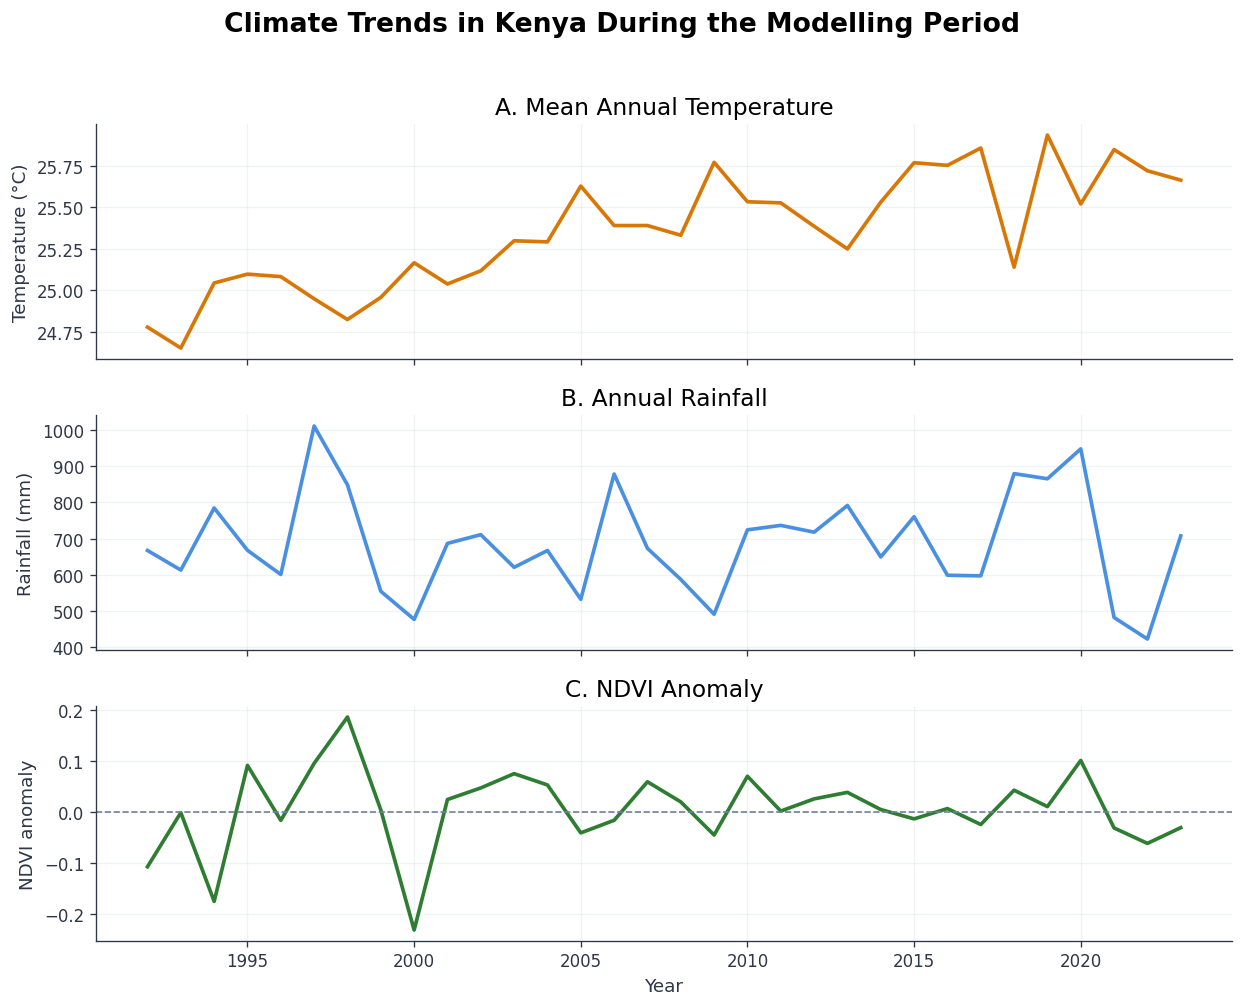

In [15]:
# Table 4.5 and Figure 4.1 — Climate trend results
climate_trends_display = climate_trends.rename(columns={
    "variable": "Variable",
    "sens_slope_approx": "Sen slope / year",
    "linear_p_value": "Linear p-value",
    "kendall_tau": "Kendall tau",
    "mk_p_value": "Mann-Kendall p-value",
    "r": "Linear r"
})
show_table("Table 4.5 Climate Trend Test Results", climate_trends_display)
fig_4_01_climate_trends()

## 7. Crop-Specific Yield Trend Results

This section examines how yield has changed over time for each representative crop. Both indexed and actual-yield figures are used because the crops have substantially different yield scales.


### 7.1 Estimate Crop-Specific Yield Trends

This subsection calculates the annual direction and magnitude of yield change for each crop and evaluates the statistical strength of those trends.


In [16]:
%%capture
# ============================================================
# 7. CROP-SPECIFIC YIELD TRENDS
# ============================================================
yield_trend_rows = []
for crop, g in data_base.groupby("Item"):
    slope, intercept, r, p, se = linregress(g["Year"], g["Yield_hg_ha"])
    yield_trend_rows.append({"Crop": crop, "yield_slope_per_year": slope, "p_value": p, "r": r})
yield_trends = pd.DataFrame(yield_trend_rows).sort_values("Crop")
save_table(yield_trends, "Table_4_5_crop_specific_yield_trends")
display(yield_trends)

plt.figure(figsize=(11,6))
for crop, g in data_base.groupby("Item"):
    plt.plot(g["Year"], g["Yield_hg_ha"], marker="o", label=crop)
plt.title("Yield Trends for Representative Crops")
plt.xlabel("Year")
plt.ylabel("Yield (hg/ha)")
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
save_fig("Figure_4_crop_yield_trends")
plt.show()

### 7.2 Present Yield-Trend Results

This subsection presents the crop-specific trend table, an indexed comparison for cross-crop interpretation, and actual-yield trajectories for scale-aware interpretation.


**Table 4.6 Crop-Specific Yield Trend Results**

,Crop,Yield slope per year,p-value,Linear r
0,Avocados,1585.072,0.000,0.567
1,Bananas,4947.747,0.000,0.878
2,Potatoes,942.131,0.287,0.188
3,Sugar cane,-4842.631,0.008,-0.448
4,Tomatoes,3152.753,0.000,0.593


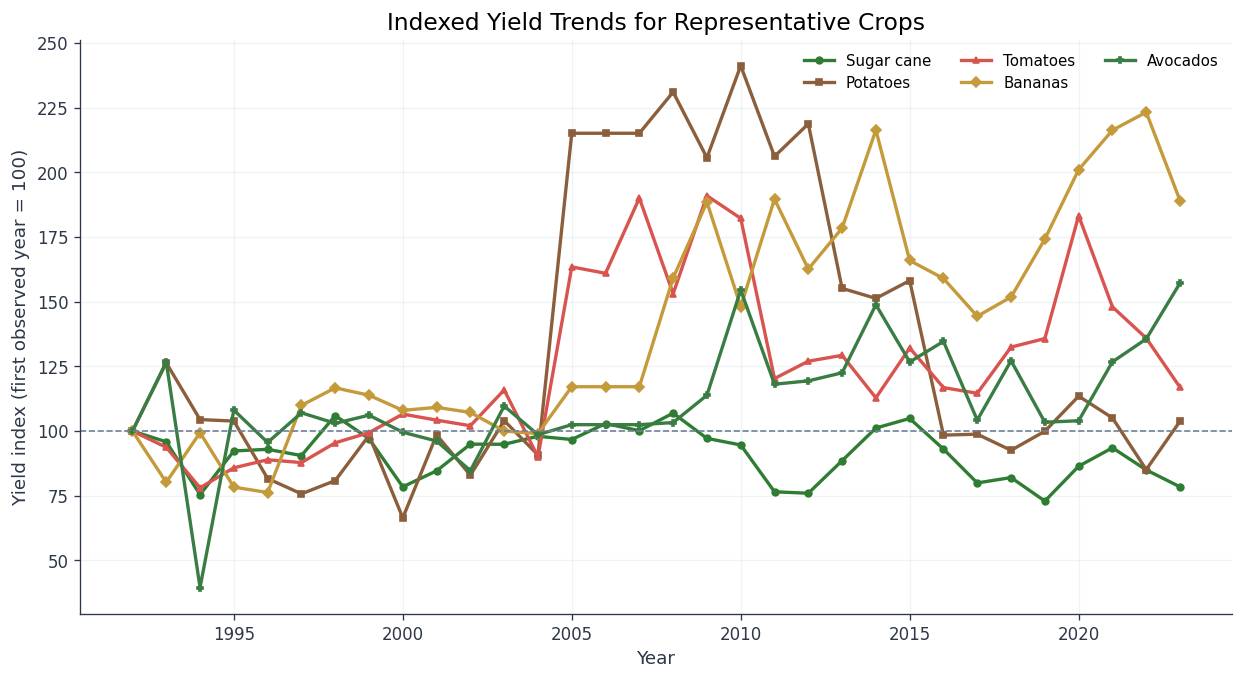

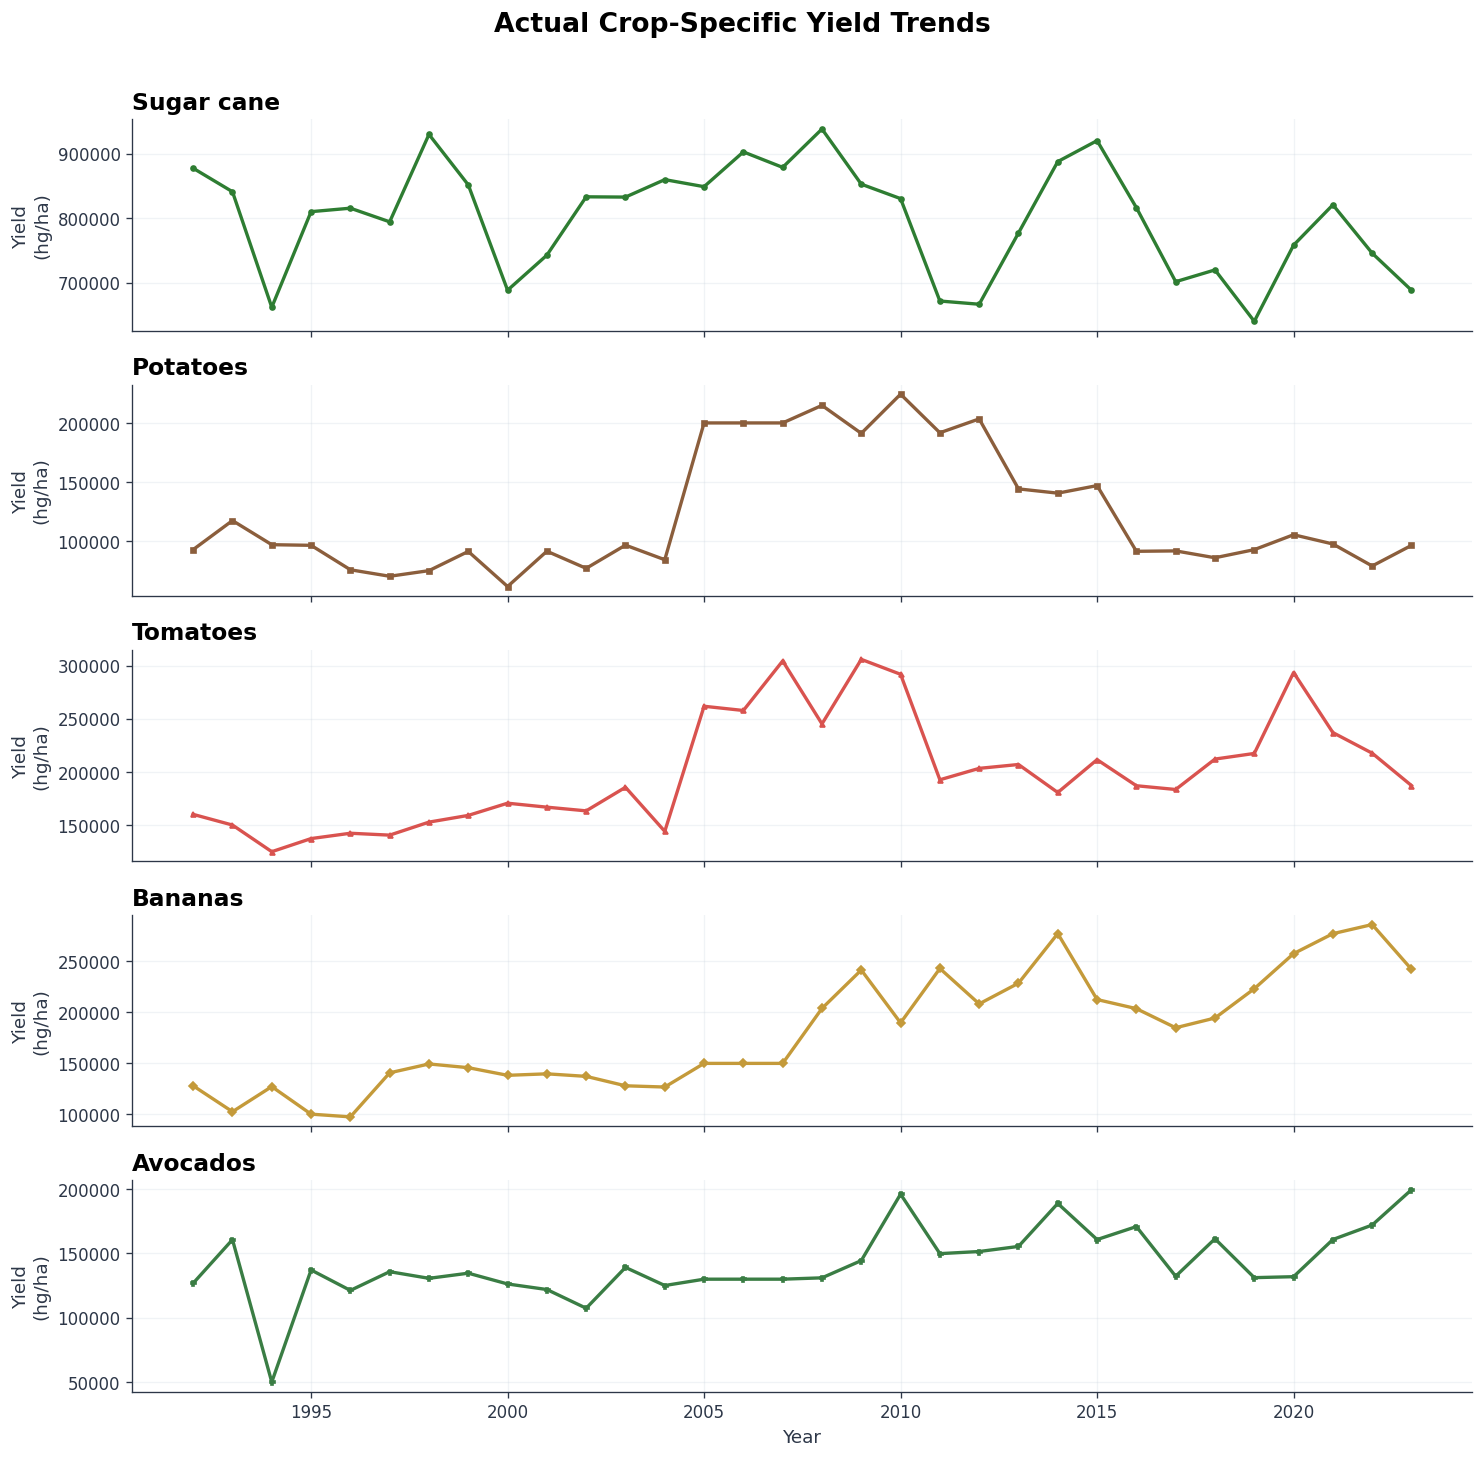

In [17]:
# Table 4.6 and Figures 4.2–4.3 — Crop yield trend results
yield_trends_display = yield_trends.rename(columns={
    "yield_slope_per_year": "Yield slope per year",
    "p_value": "p-value",
    "r": "Linear r"
})
show_table("Table 4.6 Crop-Specific Yield Trend Results", yield_trends_display)
fig_4_02_indexed_yield_trends()
fig_4_03_actual_yield_trends()

## 8. Statistical Validation

This section evaluates relationships, time-series properties, multicollinearity, and residual behaviour before the modelling results are interpreted. The diagnostics help identify statistical limitations and support transparent model evaluation.


### 8.1 Run Statistical Validation Tests

This subsection computes Pearson and Spearman correlations, ADF and KPSS stationarity tests, Variance Inflation Factors, and residual autocorrelation diagnostics. The tests are complementary and are interpreted together rather than in isolation.


In [18]:
%%capture
# ============================================================
# 9. STATISTICAL ANALYSIS AND MULTICOLLINEARITY CHECKS (final)
# ============================================================

# 9.1 Crop-specific climate-yield correlations
corr_rows = []
correlation_features = [
    "Temperature_anomaly_C",
    "Rainfall_anomaly_pct",
    "NDVI_anomaly",
    "Pesticides_tonnes"
]

for crop, g in data_fe.groupby("Item"):
    for feat in correlation_features:
        try:
            pearson_r, pearson_p = stats.pearsonr(g[feat], g[TARGET])
            spearman_r, spearman_p = stats.spearmanr(g[feat], g[TARGET])
        except Exception:
            pearson_r = pearson_p = spearman_r = spearman_p = np.nan

        corr_rows.append({
            "Crop": crop,
            "Feature": feat,
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_r": spearman_r,
            "Spearman_p": spearman_p
        })

correlations_df = pd.DataFrame(corr_rows)
save_table(correlations_df, "Table_4_7_crop_climate_yield_correlations_final")
display(correlations_df.head(20))


# 9.2 ADF and KPSS stationarity tests
def kpss_test(series):
    s = pd.Series(series).dropna()
    try:
        stat, p_value, lags, crit = kpss(s, regression="c", nlags="auto")
        return {"kpss_statistic": stat, "kpss_p_value": p_value}
    except Exception:
        return {"kpss_statistic": np.nan, "kpss_p_value": np.nan}


stationarity_rows = []
for crop, g in data_fe.groupby("Item"):
    for var in [TARGET, "Rainfall_anomaly_pct", "Temperature_anomaly_C", "NDVI_anomaly"]:
        adf_res = adf_test(g[var])
        kpss_res = kpss_test(g[var])
        row = {"Crop": crop, "Variable": var}
        row.update(adf_res)
        row.update(kpss_res)
        stationarity_rows.append(row)

stationarity_df = pd.DataFrame(stationarity_rows)
save_table(stationarity_df, "Table_4_8_adf_kpss_stationarity_tests_final")
display(stationarity_df.head(20))


# 9.3 VIF on climate-impact features only
# The final climate feature set deliberately avoids using raw variables together with their anomalies.
vif_features = [c for c in CLIMATE_FEATURES if c in data_fe.columns and data_fe[c].dtype != "object"]
X_vif = data_fe[vif_features].replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.median())
X_vif = X_vif.loc[:, X_vif.nunique() > 1]

vif_rows = []
for i, col in enumerate(X_vif.columns):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
    except Exception:
        vif_val = np.nan
    vif_rows.append({"Feature": col, "VIF": vif_val})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
save_table(vif_df, "Table_4_9_vif_multicollinearity_final")
display(vif_df)


# 9.4 Durbin-Watson residual check using simple OLS-style linear baseline per crop
dw_rows = []
for crop, g in data_fe.groupby("Item"):
    g = g.sort_values("Year")
    X = g[CLIMATE_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(g[CLIMATE_FEATURES].median())
    y = g[TARGET]
    try:
        lin = LinearRegression()
        lin.fit(X, y)
        resid = y - lin.predict(X)
        dw = durbin_watson(resid)
    except Exception:
        dw = np.nan
    dw_rows.append({"Crop": crop, "Durbin_Watson": dw})

durbin_watson_df = pd.DataFrame(dw_rows)
save_table(durbin_watson_df, "Table_4_10_durbin_watson_residuals_final")
display(durbin_watson_df)


### 8.2 Present Statistical Validation Results

This subsection presents the concise correlation, stationarity, multicollinearity, and residual-diagnostic outputs required to assess the suitability and limitations of the modelling dataset.


**Table 4.7 Climate-Yield Correlation Results**

,Crop,Predictor,Pearson r,Pearson p-value,Spearman r,Spearman p-value
0,Avocados,Temperature_anomaly_C,0.390,0.027,0.448,0.010
1,Avocados,Rainfall_anomaly_pct,-0.139,0.447,-0.033,0.858
2,Avocados,NDVI_anomaly,0.225,0.216,0.047,0.798
3,Avocados,Pesticides_tonnes,0.329,0.066,0.493,0.004
4,Bananas,Temperature_anomaly_C,0.724,0.000,0.726,0.000
5,Bananas,Rainfall_anomaly_pct,-0.065,0.722,0.024,0.895
6,Bananas,NDVI_anomaly,-0.017,0.928,-0.111,0.545
7,Bananas,Pesticides_tonnes,0.648,0.000,0.667,0.000
8,Potatoes,Temperature_anomaly_C,0.298,0.097,0.369,0.038
9,Potatoes,Rainfall_anomaly_pct,-0.028,0.879,0.063,0.733


**Table 4.8 ADF and KPSS Stationarity Results**

,Crop,Variable,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,Avocados,Yield_hg_ha,-3.902,0.002,0.668,0.016
1,Avocados,Rainfall_anomaly_pct,-4.501,0.000,0.101,0.100
2,Avocados,Temperature_anomaly_C,-0.993,0.756,0.840,0.010
3,Avocados,NDVI_anomaly,-5.836,0.000,0.093,0.100
4,Bananas,Yield_hg_ha,-1.448,0.559,0.798,0.010
5,Bananas,Rainfall_anomaly_pct,-4.501,0.000,0.101,0.100
6,Bananas,Temperature_anomaly_C,-0.993,0.756,0.840,0.010
7,Bananas,NDVI_anomaly,-5.836,0.000,0.093,0.100
8,Potatoes,Yield_hg_ha,-1.687,0.438,0.194,0.100
9,Potatoes,Rainfall_anomaly_pct,-4.501,0.000,0.101,0.100


**Table 4.9 VIF Multicollinearity Results**

,Feature,VIF
0,Rainfall_anomaly_pct,8.442
1,Wet_indicator,5.862
2,Heat_stress,4.593
3,Drought_indicator,4.419
4,Pesticides_tonnes,3.535
5,Temperature_anomaly_C,2.674
6,NDVI_anomaly,1.505


**Table 4.10 Durbin-Watson Residual Diagnostic Results**

,Crop,Durbin_Watson
0,Avocados,1.806
1,Bananas,1.217
2,Potatoes,1.156
3,Sugar cane,1.408
4,Tomatoes,1.573


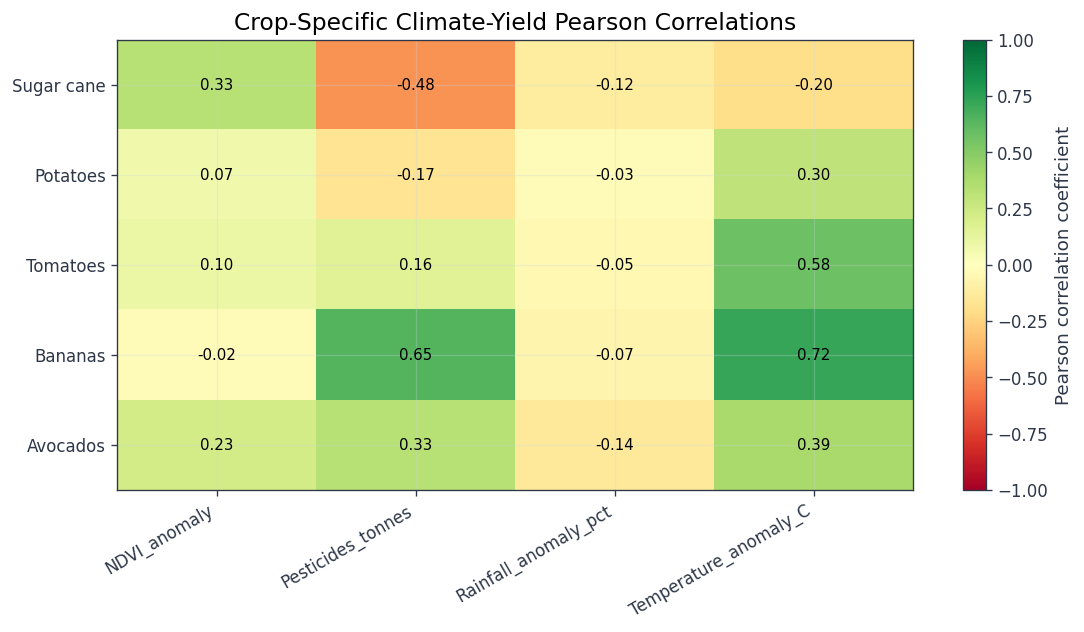

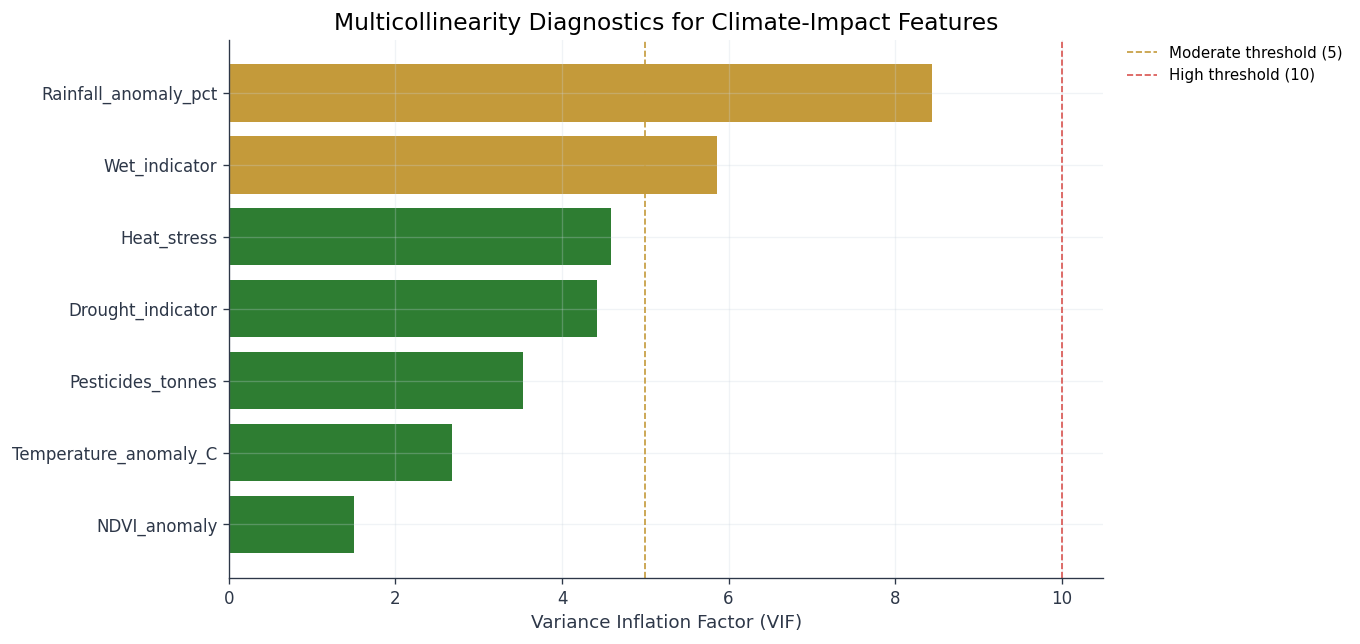

In [19]:
# Tables 4.7–4.10 and Figures 4.4–4.5 — Statistical validation
corr_display = correlations_df.rename(columns={
    "Feature": "Predictor",
    "Pearson_r": "Pearson r",
    "Pearson_p": "Pearson p-value",
    "Spearman_r": "Spearman r",
    "Spearman_p": "Spearman p-value"
})
show_table("Table 4.7 Climate-Yield Correlation Results", corr_display, rows=30)

stationarity_display = stationarity_df.rename(columns={
    "adf_statistic": "ADF statistic",
    "adf_p_value": "ADF p-value",
    "kpss_statistic": "KPSS statistic",
    "kpss_p_value": "KPSS p-value"
})
show_table("Table 4.8 ADF and KPSS Stationarity Results", stationarity_display, rows=30)

show_table("Table 4.9 VIF Multicollinearity Results", vif_df)
show_table("Table 4.10 Durbin-Watson Residual Diagnostic Results", durbin_watson_df)
fig_4_04_correlation_matrix()
fig_4_05_vif_diagnostics()

## 9. Machine-Learning Modelling and Algorithm Comparison

This section trains and compares Naive Mean, Linear Regression, Ridge Regression, Bayesian Ridge, Random Forest, Gradient Boosting, XGBoost, and CatBoost. Models are evaluated separately for each crop and feature set using time-aware validation so that future observations are not used to predict the past.


### 9.1 Train Candidate Algorithms

This subsection trains the baseline, linear, regularised, ensemble, and boosting regressors. Where enabled, limited hyperparameter tuning is applied within the time-aware training framework.


In [20]:
%%capture
# ============================================================
# 10. CROP-SPECIFIC MODEL TRAINING WITH TIME-SERIES VALIDATION (final)
# ============================================================

def make_base_model_library():
    """Baseline and candidate models."""
    return {
        "Naive Mean": DummyRegressor(strategy="mean"),
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(random_state=RANDOM_STATE),
        "Bayesian Ridge": BayesianRidge(),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            min_samples_leaf=2
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            max_depth=3
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            objective="reg:squarederror"
        ),
        "CatBoost": CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=False
        )
    }


def build_preprocessor(feature_cols):
    numeric_cols = feature_cols
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols)
    ], remainder="drop")


def time_split_crop(g, test_year_start=2017):
    train = g[g["Year"] < test_year_start].copy()
    test = g[g["Year"] >= test_year_start].copy()

    if len(test) < 3:
        yrs = sorted(g["Year"].unique())
        split = yrs[int(len(yrs) * 0.8)]
        train = g[g["Year"] < split].copy()
        test = g[g["Year"] >= split].copy()

    return train, test


def evaluate_predictions(y_true, pred):
    return {
        "R2": r2_score(y_true, pred) if len(y_true) > 1 else np.nan,
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": rmse(y_true, pred),
        "MAPE": mape_safe(y_true, pred)
    }


def time_series_cv_rmse(pipe, X, y):
    """Return mean/std RMSE from TimeSeriesSplit on training data."""
    if len(X) < 12:
        return np.nan, np.nan

    n_splits = min(5, max(2, len(X)//10))
    if n_splits < 2:
        return np.nan, np.nan

    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []

    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        try:
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_val)
            rmses.append(rmse(y_val, pred))
        except Exception:
            pass

    if len(rmses) == 0:
        return np.nan, np.nan

    return float(np.mean(rmses)), float(np.std(rmses))


def tune_model_if_needed(model_name, model, preprocessor, X_train, y_train):
    """
    Lightweight hyperparameter tuning for selected ensemble models.
    Uses TimeSeriesSplit and RandomizedSearchCV.
    """
    if not ENABLE_HYPERPARAMETER_TUNING:
        return model, None

    if len(X_train) < 20:
        return model, None

    param_distributions = None

    if model_name == "Random Forest":
        param_distributions = {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_leaf": [1, 2, 3, 4],
            "model__min_samples_split": [2, 4, 6]
        }

    elif model_name == "XGBoost":
        param_distributions = {
            "model__n_estimators": [100, 200, 300, 500],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
            "model__max_depth": [2, 3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        }

    elif model_name == "CatBoost":
        param_distributions = {
            "model__iterations": [100, 200, 300, 500],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
            "model__depth": [2, 3, 4, 5, 6],
            "model__l2_leaf_reg": [1, 3, 5, 7, 9]
        }

    if param_distributions is None:
        return model, None

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    n_splits = min(4, max(2, len(X_train)//12))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=TUNING_ITERATIONS,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        error_score=np.nan
    )

    try:
        search.fit(X_train, y_train)
        best_model = search.best_estimator_.named_steps["model"]
        return best_model, search.best_params_
    except Exception as e:
        print("Tuning skipped/failed:", model_name, e)
        return model, None


def train_crop_models(feature_set_name, feature_cols):
    all_results, all_predictions, fitted = [], [], {}
    tuning_rows = []

    for crop, g in data_fe.groupby("Item"):
        g = g.sort_values("Year")
        train, test = time_split_crop(g, test_year_start=2017)

        if len(train) < 12 or len(test) < 2:
            print("Skipping", crop, "insufficient data")
            continue

        X_train, y_train = train[feature_cols], train[TARGET]
        X_test, y_test = test[feature_cols], test[TARGET]

        pre = build_preprocessor(feature_cols)
        model_library = make_base_model_library()

        for model_name, base_model in model_library.items():
            start = time.time()

            try:
                tuned_model, best_params = tune_model_if_needed(
                    model_name,
                    base_model,
                    pre,
                    X_train,
                    y_train
                )

                pipe = Pipeline([
                    ("preprocess", pre),
                    ("model", tuned_model)
                ])

                cv_mean, cv_std = time_series_cv_rmse(pipe, X_train, y_train)

                pipe.fit(X_train, y_train)
                pred = pipe.predict(X_test)

                elapsed = time.time() - start
                met = evaluate_predictions(y_test, pred)

                met.update({
                    "Feature_Set": feature_set_name,
                    "Crop": crop,
                    "Model": model_name,
                    "Train_n": len(train),
                    "Test_n": len(test),
                    "CV_RMSE_mean": cv_mean,
                    "CV_RMSE_std": cv_std,
                    "Train_time_sec": elapsed
                })

                all_results.append(met)

                pred_df = test[["Year", "Item", TARGET]].copy()
                pred_df["Feature_Set"] = feature_set_name
                pred_df["Model"] = model_name
                pred_df["Prediction"] = pred
                pred_df["Residual"] = pred_df[TARGET] - pred_df["Prediction"]
                all_predictions.append(pred_df)

                fitted[(feature_set_name, crop, model_name)] = pipe

                if best_params is not None:
                    tuning_rows.append({
                        "Feature_Set": feature_set_name,
                        "Crop": crop,
                        "Model": model_name,
                        "Best_Params": str(best_params)
                    })

            except Exception as e:
                print("Model failed:", feature_set_name, crop, model_name, e)

    result_df = pd.DataFrame(all_results)
    pred_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    tuning_df = pd.DataFrame(tuning_rows)

    return result_df, pred_df, fitted, tuning_df


results_climate, preds_climate, fitted_climate, tuning_climate = train_crop_models("Climate-only", CLIMATE_FEATURES)
results_lag, preds_lag, fitted_lag, tuning_lag = train_crop_models("Climate+Lag", FORECAST_FEATURES)

model_results = pd.concat([results_climate, results_lag], ignore_index=True)
model_predictions = pd.concat([preds_climate, preds_lag], ignore_index=True)
tuning_results = pd.concat([tuning_climate, tuning_lag], ignore_index=True)

save_table(model_results, "Table_4_11_crop_specific_model_results_final")
save_table(model_predictions, "Table_4_12_model_predictions_final")
save_table(tuning_results, "Table_4_13_hyperparameter_tuning_results_final")

display(model_results.sort_values(["Crop", "Feature_Set", "RMSE"]).head(40))
display(tuning_results.head(20))


### 9.2 Select the Best Models

This subsection selects the strongest model for each crop and modelling purpose. RMSE is used as the primary selection criterion because it penalises large errors, while R², MAE, MAPE, and cross-validation results provide supporting evidence.


In [21]:
%%capture
# ============================================================
# 11. SELECT BEST MODEL PER CROP AND FEATURE SET (final)
# ============================================================

best_by_crop = (
    model_results
    .sort_values("RMSE")
    .groupby(["Crop", "Feature_Set"], as_index=False)
    .first()
)

save_table(best_by_crop, "Table_4_14_best_model_by_crop_and_feature_set_final")
display(best_by_crop)

# Primary operational model: best Climate+Lag model for forecasting.
# Interpretive model: best Climate-only model for climate-impact explanation and scenarios.
primary_models = {}
interpretive_models = {}

for _, row in best_by_crop.iterrows():
    key = (row["Feature_Set"], row["Crop"], row["Model"])

    if row["Feature_Set"] == "Climate+Lag":
        primary_models[row["Crop"]] = {
            "model_name": row["Model"],
            "pipe": fitted_lag.get(key),
            "features": FORECAST_FEATURES
        }

    elif row["Feature_Set"] == "Climate-only":
        interpretive_models[row["Crop"]] = {
            "model_name": row["Model"],
            "pipe": fitted_climate.get(key),
            "features": CLIMATE_FEATURES
        }


# Residual standard deviation for uncertainty intervals
residual_std_map = {}

for _, row in best_by_crop.iterrows():
    crop = row["Crop"]
    fs = row["Feature_Set"]
    model_name = row["Model"]

    p = model_predictions[
        (model_predictions["Item"] == crop) &
        (model_predictions["Feature_Set"] == fs) &
        (model_predictions["Model"] == model_name)
    ]

    if not p.empty:
        residual_std_map[(crop, fs)] = float(p["Residual"].std(ddof=1))
    else:
        residual_std_map[(crop, fs)] = np.nan


plt.figure(figsize=(11,6))
plot_df = best_by_crop.copy()

for fs in plot_df["Feature_Set"].unique():
    subset = plot_df[plot_df["Feature_Set"] == fs]
    plt.plot(subset["Crop"], subset["RMSE"], marker="o", label=fs)

plt.title("Best Model RMSE by Crop and Feature Set")
plt.xlabel("Crop")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("Figure_4_best_model_rmse_by_crop_final")
plt.show()


# Cross-crop synthesis table
synthesis_rows = []
for crop in REPRESENTATIVE_CROPS:
    climate_row = best_by_crop[
        (best_by_crop["Crop"] == crop) &
        (best_by_crop["Feature_Set"] == "Climate-only")
    ]

    forecast_row = best_by_crop[
        (best_by_crop["Crop"] == crop) &
        (best_by_crop["Feature_Set"] == "Climate+Lag")
    ]

    synthesis_rows.append({
        "Crop": crop,
        "Best_Climate_Model": climate_row.iloc[0]["Model"] if not climate_row.empty else None,
        "Climate_R2": climate_row.iloc[0]["R2"] if not climate_row.empty else np.nan,
        "Best_Forecast_Model": forecast_row.iloc[0]["Model"] if not forecast_row.empty else None,
        "Forecast_R2": forecast_row.iloc[0]["R2"] if not forecast_row.empty else np.nan
    })

cross_crop_synthesis_df = pd.DataFrame(synthesis_rows)
save_table(cross_crop_synthesis_df, "Table_4_15_cross_crop_model_synthesis_final")
display(cross_crop_synthesis_df)


### 9.3 Compare Algorithms and Metrics

This subsection reports the complete algorithm comparison and the selected crop-specific models. The metrics are retained together because each describes a different aspect of predictive performance.


In [22]:
# Tables 4.11–4.12 — Algorithm comparison and selected models
model_results_display = model_results[[
    "Feature_Set", "Crop", "Model", "R2", "MAE", "RMSE", "MAPE", "CV_RMSE_mean", "CV_RMSE_std"
]].sort_values(["Feature_Set", "Crop", "RMSE"])
show_table("Table 4.11 Model Performance Across Algorithms", model_results_display, rows=80)

best_display = best_by_crop[[
    "Feature_Set", "Crop", "Model", "R2", "MAE", "RMSE", "MAPE", "CV_RMSE_mean", "CV_RMSE_std"
]].sort_values(["Feature_Set", "Crop"])
show_table("Table 4.12 Selected Best Model by Crop and Feature Set", best_display)

**Table 4.11 Model Performance Across Algorithms**

,Feature_Set,Crop,Model,R2,MAE,RMSE,MAPE,CV_RMSE_mean,CV_RMSE_std
0,Climate+Lag,Avocados,XGBoost,-0.186,24024.359,25883.479,15.528,38508.763,23293.244
1,Climate+Lag,Avocados,CatBoost,-0.187,24363.263,25890.910,15.522,30325.046,20437.921
2,Climate+Lag,Avocados,Random Forest,-0.195,24810.166,25981.589,16.071,28006.411,18872.502
3,Climate+Lag,Avocados,Ridge Regression,-0.289,23776.064,26989.338,15.751,58596.490,41192.505
4,Climate+Lag,Avocados,Linear Regression,-0.335,24152.996,27461.478,16.051,68630.840,50107.325
...,...,...,...,...,...,...,...,...,...
75,Climate-only,Tomatoes,Random Forest,-0.396,33409.912,40327.942,15.165,65613.166,20800.027
76,Climate-only,Tomatoes,Bayesian Ridge,-0.639,32167.469,43696.485,13.093,74229.697,12469.965
77,Climate-only,Tomatoes,Naive Mean,-0.639,32167.469,43696.485,13.093,74229.697,12469.965
78,Climate-only,Tomatoes,Ridge Regression,-2.506,42539.022,63902.839,17.925,54977.864,19225.882


**Table 4.12 Selected Best Model by Crop and Feature Set**

,Feature_Set,Crop,Model,R2,MAE,RMSE,MAPE,CV_RMSE_mean,CV_RMSE_std
0,Climate+Lag,Avocados,XGBoost,-0.186,24024.359,25883.479,15.528,3.850876e+04,2.329324e+04
1,Climate+Lag,Bananas,Ridge Regression,0.258,27098.244,31138.262,10.977,3.816788e+04,1.202016e+04
2,Climate+Lag,Potatoes,Gradient Boosting,-8.823,23062.477,24651.295,25.162,6.624612e+04,1.494522e+04
3,Climate+Lag,Sugar cane,Linear Regression,-0.105,47814.639,55985.015,6.697,2.549568e+07,2.538888e+07
4,Climate+Lag,Tomatoes,XGBoost,-0.233,27500.848,37899.055,11.614,7.109748e+04,1.023735e+04
5,Climate-only,Avocados,Random Forest,-0.287,24602.458,26961.537,16.127,2.739095e+04,1.813379e+04
6,Climate-only,Bananas,Linear Regression,-0.303,37222.596,41278.731,15.289,6.566146e+04,3.712593e+04
7,Climate-only,Potatoes,Gradient Boosting,-14.279,27292.193,30744.308,29.892,6.892137e+04,1.730797e+04
8,Climate-only,Sugar cane,Linear Regression,-1.033,61756.158,75926.555,8.872,1.034157e+05,1.579527e+04
9,Climate-only,Tomatoes,Gradient Boosting,0.148,21984.632,31506.720,9.109,7.011560e+04,1.373250e+04


,Feature_Set,Crop,Model,R2,MAE,RMSE,MAPE,CV_RMSE_mean,CV_RMSE_std
0,Climate+Lag,Avocados,XGBoost,-0.186,24024.359,25883.479,15.528,3.850876e+04,2.329324e+04
2,Climate+Lag,Bananas,Ridge Regression,0.258,27098.244,31138.262,10.977,3.816788e+04,1.202016e+04
4,Climate+Lag,Potatoes,Gradient Boosting,-8.823,23062.477,24651.295,25.162,6.624612e+04,1.494522e+04
6,Climate+Lag,Sugar cane,Linear Regression,-0.105,47814.639,55985.015,6.697,2.549568e+07,2.538888e+07
8,Climate+Lag,Tomatoes,XGBoost,-0.233,27500.848,37899.055,11.614,7.109748e+04,1.023735e+04
1,Climate-only,Avocados,Random Forest,-0.287,24602.458,26961.537,16.127,2.739095e+04,1.813379e+04
3,Climate-only,Bananas,Linear Regression,-0.303,37222.596,41278.731,15.289,6.566146e+04,3.712593e+04
5,Climate-only,Potatoes,Gradient Boosting,-14.279,27292.193,30744.308,29.892,6.892137e+04,1.730797e+04
7,Climate-only,Sugar cane,Linear Regression,-1.033,61756.158,75926.555,8.872,1.034157e+05,1.579527e+04
9,Climate-only,Tomatoes,Gradient Boosting,0.148,21984.632,31506.720,9.109,7.011560e+04,1.373250e+04


### 9.4 Visualise Model Performance

This subsection creates concise comparison figures for RMSE, R², MAPE, and performance relative to the Naive Mean baseline. The graphics are designed to support clear cross-crop and cross-model interpretation.


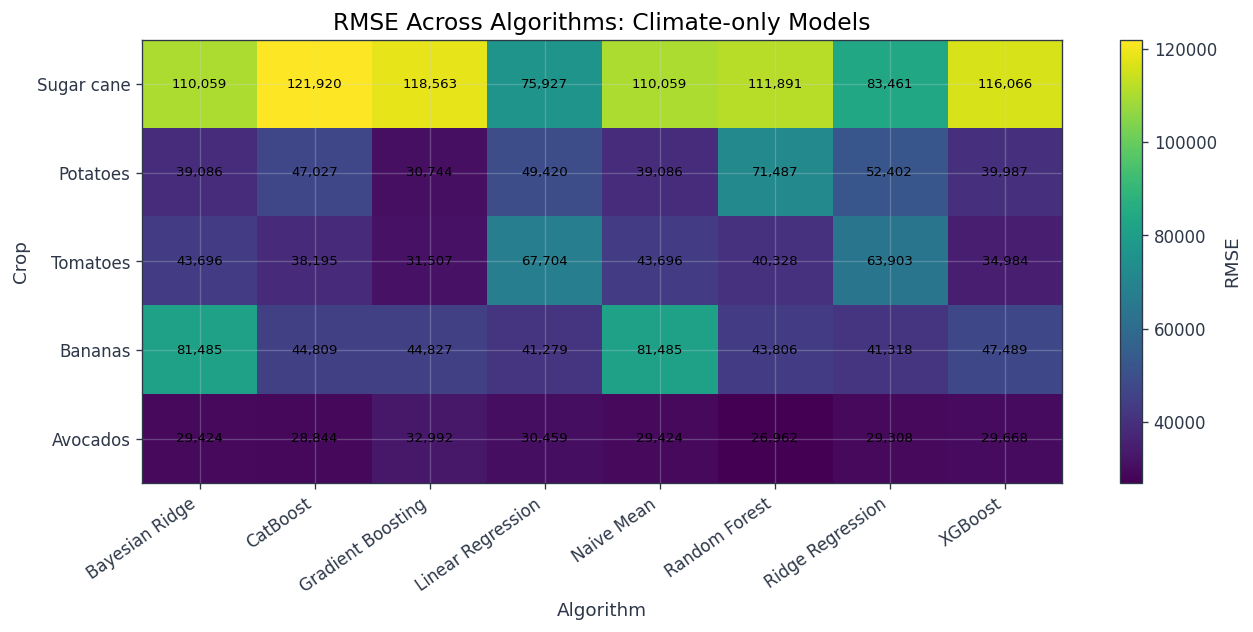

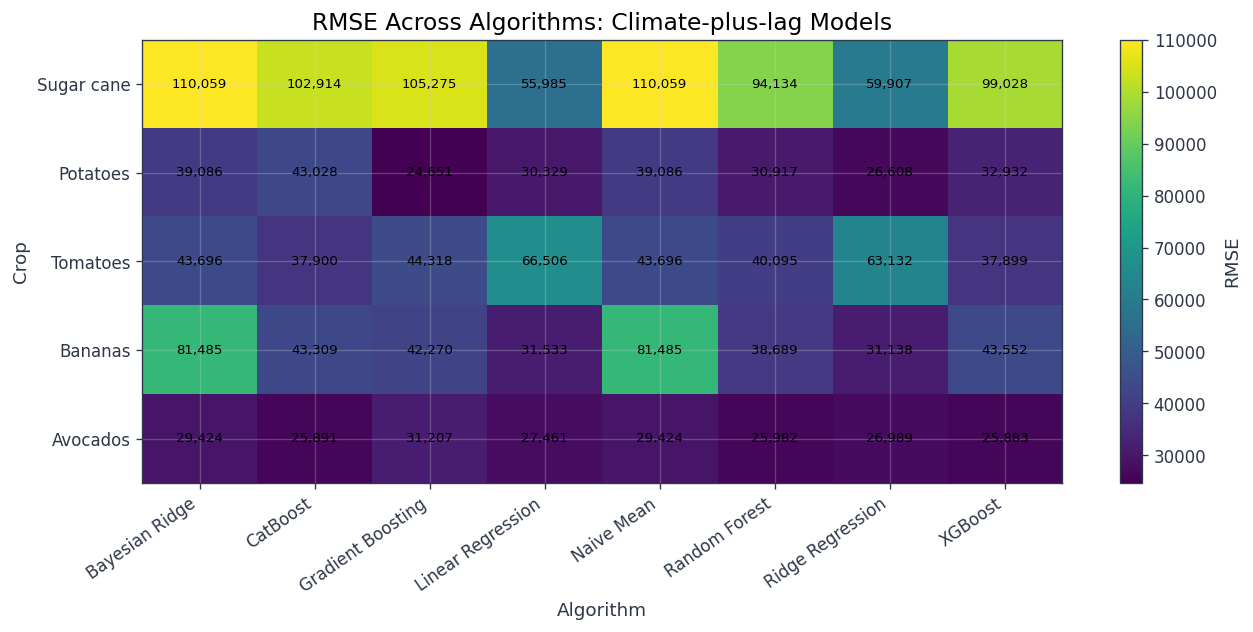

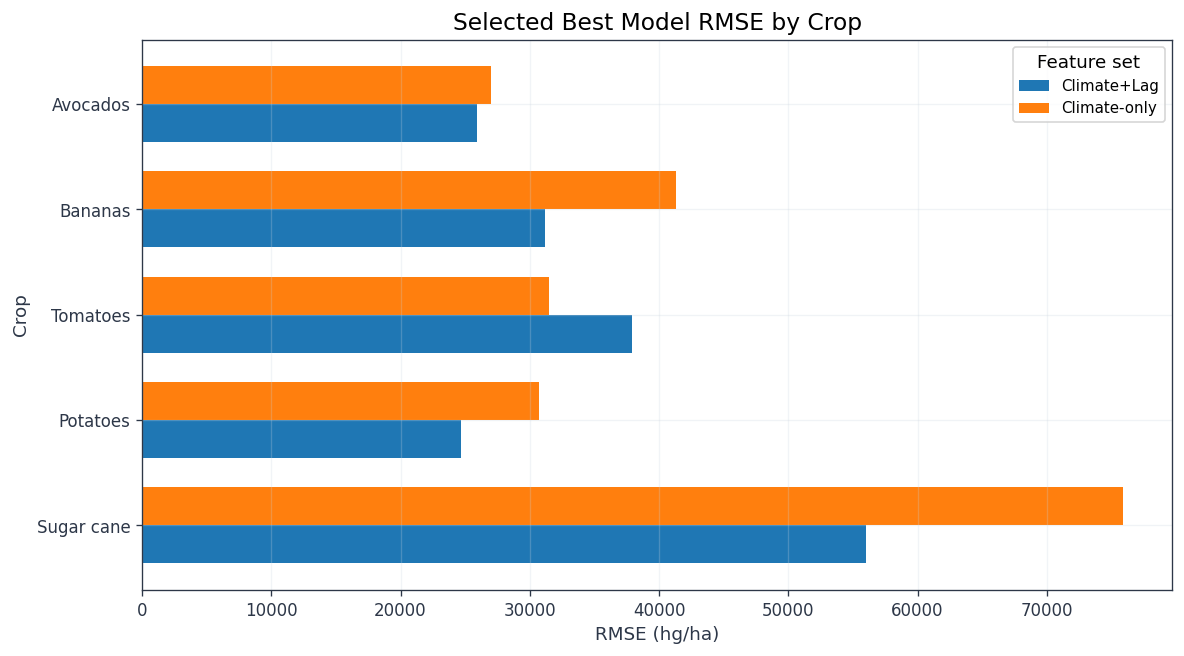

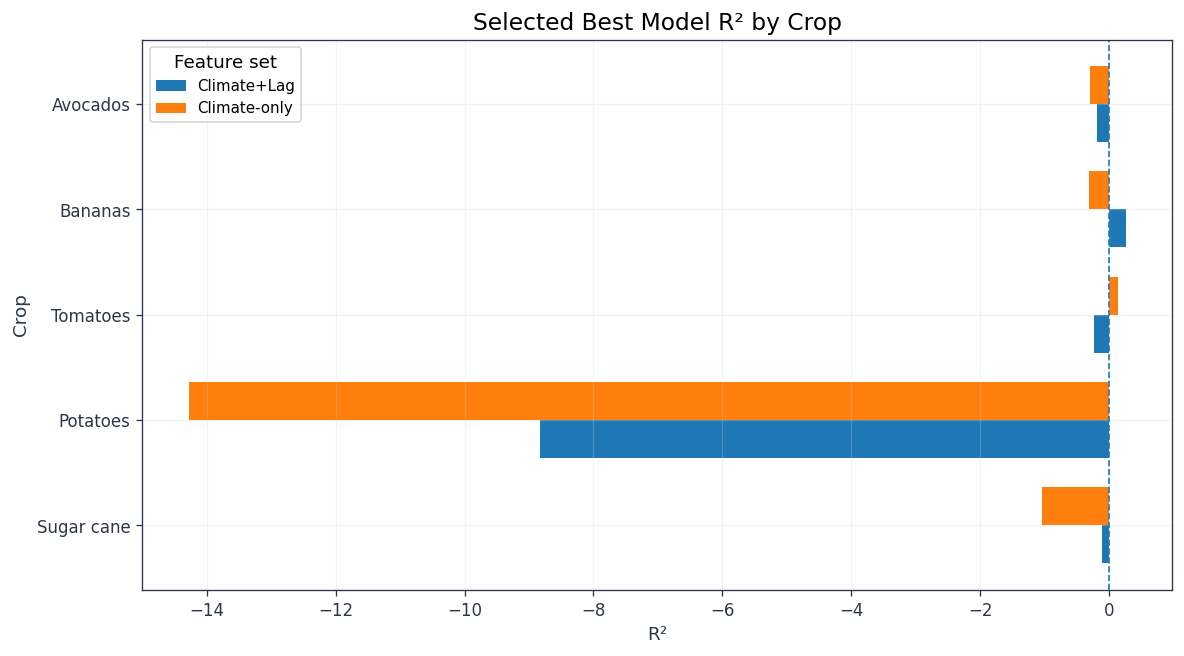

PosixPath('Climate_Decision_Support_System_publication_figures/Figure_4_09_Selected_Best_Model_R2.png')

In [23]:
# Figures 4.6–4.9 — Clean model metric visualisations
metric_df = model_results.copy()
for col in ["R2", "MAE", "RMSE", "MAPE", "CV_RMSE_mean", "CV_RMSE_std", "Train_time_sec"]:
    if col in metric_df.columns:
        metric_df[col] = pd.to_numeric(metric_df[col], errors="coerce")

metric_df = metric_df.sort_values(["Feature_Set", "Crop", "RMSE"]).reset_index(drop=True)
metric_df.to_csv(TABLE_DIR / "Table_4_11_model_performance_across_algorithms.csv", index=False)

ml_df = metric_df[metric_df["Model"] != "Naive Mean"].copy()
best_idx = ml_df.groupby(["Feature_Set", "Crop"])["RMSE"].idxmin()
best_models_df = ml_df.loc[best_idx].sort_values(["Feature_Set", "Crop"]).reset_index(drop=True)
best_models_df.to_csv(TABLE_DIR / "Table_4_12_selected_best_models.csv", index=False)

def _safe_feature_name(name):
    return str(name).replace("+", "plus").replace("-", "_").replace(" ", "_")

def plot_metric_heatmap(metric, feature_set, title, filename):
    d = metric_df[metric_df["Feature_Set"] == feature_set].copy()
    pivot = d.pivot_table(index="Crop", columns="Model", values=metric, aggfunc="mean")
    pivot = pivot.reindex([c for c in REPRESENTATIVE_CROPS if c in pivot.index])

    fig, ax = plt.subplots(figsize=(11, 5.4))
    data = pivot.values.astype(float)
    im = ax.imshow(data, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Crop")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # Keep labels short to avoid visual crowding.
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            if np.isnan(value):
                continue
            label = f"{value:.2f}" if metric == "R2" else f"{value:,.0f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)
    fig.tight_layout()
    path = FIG_DIR / f"{filename}.png"
    fig.savefig(path, dpi=350, bbox_inches="tight")
    plt.show()
    return path

def plot_best_metric_horizontal(metric, title, xlabel, filename):
    pivot = best_models_df.pivot_table(index="Crop", columns="Feature_Set", values=metric, aggfunc="mean")
    pivot = pivot.reindex([c for c in REPRESENTATIVE_CROPS if c in pivot.index])
    fig, ax = plt.subplots(figsize=(10, 5.6))
    pivot.plot(kind="barh", ax=ax, width=0.72)
    if metric == "R2":
        ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Crop")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(title="Feature set", loc="best")
    fig.tight_layout()
    path = FIG_DIR / f"{filename}.png"
    fig.savefig(path, dpi=350, bbox_inches="tight")
    plt.show()
    return path

plot_metric_heatmap(
    "RMSE",
    "Climate-only",
    "RMSE Across Algorithms: Climate-only Models",
    "Figure_4_06_RMSE_Heatmap_Climate_Only"
)
plot_metric_heatmap(
    "RMSE",
    "Climate+Lag",
    "RMSE Across Algorithms: Climate-plus-lag Models",
    "Figure_4_07_RMSE_Heatmap_Climate_plus_Lag"
)
plot_best_metric_horizontal(
    "RMSE",
    "Selected Best Model RMSE by Crop",
    "RMSE (hg/ha)",
    "Figure_4_08_Selected_Best_Model_RMSE"
)
plot_best_metric_horizontal(
    "R2",
    "Selected Best Model R² by Crop",
    "R²",
    "Figure_4_09_Selected_Best_Model_R2"
)

### 9.5 Optional Actual-versus-Predicted Diagnostics

This subsection saves additional actual-versus-predicted diagnostic plots without displaying them in the main notebook output. The files are retained for debugging, supplementary analysis, or future model investigation.


In [24]:
%%capture
# ============================================================
# 12. VISUALIZE ACTUAL VS PREDICTED FOR BEST MODELS
# ============================================================
for crop in REPRESENTATIVE_CROPS:
    for fs in ["Climate-only", "Climate+Lag"]:
        bm = best_by_crop[(best_by_crop["Crop"] == crop) & (best_by_crop["Feature_Set"] == fs)]
        if bm.empty: continue
        model_name = bm.iloc[0]["Model"]
        p = model_predictions[(model_predictions["Item"] == crop) & (model_predictions["Feature_Set"] == fs) & (model_predictions["Model"] == model_name)]
        if p.empty: continue
        plt.figure(figsize=(8,4.5))
        plt.plot(p["Year"], p[TARGET], marker="o", label="Actual")
        plt.plot(p["Year"], p["Prediction"], marker="s", label="Predicted")
        plt.title(f"{crop}: Actual vs Predicted ({fs}, {model_name})")
        plt.xlabel("Year")
        plt.ylabel("Yield (hg/ha)")
        plt.ticklabel_format(style='plain', axis='y')
        plt.legend()
        plt.grid(True, alpha=0.3)
        save_fig(f"Figure_4_actual_pred_{crop_slug(crop)}_{crop_slug(fs)}")
        plt.show()

## 10. Explainable Model Results

This section examines which input variables influence the selected climate-impact models. Permutation importance is used consistently, while SHAP and partial-dependence outputs are generated where the model structure and package support permit.


### 10.1 Compute Explainability Outputs

This subsection calculates feature-importance and model-explanation outputs for the selected crops. The results describe predictive influence and should not be interpreted as evidence of causality.


In [25]:
%%capture
# ============================================================
# 13. EXPLAINABLE AI: SHAP, PERMUTATION IMPORTANCE AND PDP (final)
# ============================================================

explainability_rows = []
shap_summary_rows = []
shap_available = {}

def get_crop_train_test(crop, feature_cols):
    g = data_fe[data_fe["Item"] == crop].sort_values("Year")
    train, test = time_split_crop(g, test_year_start=2017)
    return train, test


def get_transformed_feature_names(preprocessor, feature_cols):
    # Here all features are numeric and passed through a single transformer.
    return feature_cols


for crop, info in interpretive_models.items():

    pipe = info["pipe"]
    feats = info["features"]

    if pipe is None:
        continue

    train, test = get_crop_train_test(crop, feats)
    X_train, y_train = train[feats], train[TARGET]
    X_test, y_test = test[feats], test[TARGET]

    # 13.1 Permutation importance
    try:
        perm = permutation_importance(
            pipe,
            X_test,
            y_test,
            n_repeats=30,
            random_state=RANDOM_STATE,
            scoring="neg_root_mean_squared_error"
        )

        imp = pd.DataFrame({
            "Crop": crop,
            "Feature": feats,
            "Importance_mean": perm.importances_mean,
            "Importance_std": perm.importances_std
        })

        explainability_rows.append(imp)

        top = imp.sort_values("Importance_mean", ascending=False).head(12)

        plt.figure(figsize=(9,5))
        plt.barh(top["Feature"][::-1], top["Importance_mean"][::-1])
        plt.title(f"{crop}: Permutation Importance (Climate-impact model)")
        plt.xlabel("Decrease in negative RMSE importance")
        save_fig(f"Figure_4_perm_importance_{crop_slug(crop)}_final")
        plt.show()

    except Exception as e:
        print("Permutation importance failed", crop, e)


    # 13.2 SHAP summary and SHAP importance
    try:
        pre = pipe.named_steps["preprocess"]
        model = pipe.named_steps["model"]

        X_train_trans = pre.transform(X_train)
        X_test_trans = pre.transform(X_test)
        feature_names = get_transformed_feature_names(pre, feats)

        explainer = shap.Explainer(model, X_train_trans, feature_names=feature_names)
        shap_values = explainer(X_test_trans)

        # SHAP summary plot
        plt.figure()
        shap.summary_plot(
            shap_values,
            X_test_trans,
            feature_names=feature_names,
            show=False
        )
        save_fig(f"Figure_4_shap_summary_{crop_slug(crop)}_final")
        plt.show()

        # SHAP bar plot
        plt.figure()
        shap.plots.bar(shap_values, show=False)
        save_fig(f"Figure_4_shap_bar_{crop_slug(crop)}_final")
        plt.show()

        # Local waterfall for first test prediction
        try:
            plt.figure()
            shap.plots.waterfall(shap_values[0], show=False)
            save_fig(f"Figure_4_shap_waterfall_{crop_slug(crop)}_final")
            plt.show()
        except Exception as e:
            print("Waterfall skipped", crop, e)

        mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

        shap_imp = pd.DataFrame({
            "Crop": crop,
            "Feature": feature_names,
            "Mean_abs_SHAP": mean_abs_shap
        }).sort_values("Mean_abs_SHAP", ascending=False)

        shap_summary_rows.append(shap_imp)
        shap_available[crop] = True

    except Exception as e:
        print("SHAP skipped for", crop, "because:", e)
        shap_available[crop] = False


    # 13.3 PDP for climate variables
    for feat in ["Temperature_anomaly_C", "Rainfall_anomaly_pct", "NDVI_anomaly"]:
        if feat in feats:
            try:
                fig, ax = plt.subplots(figsize=(7,4.5))
                PartialDependenceDisplay.from_estimator(
                    pipe,
                    X_train,
                    [feat],
                    ax=ax
                )
                plt.title(f"{crop}: Partial Dependence of {feat}")
                save_fig(f"Figure_4_pdp_{crop_slug(crop)}_{feat}_final")
                plt.show()
            except Exception as e:
                print("PDP failed", crop, feat, e)


perm_importance_df = (
    pd.concat(explainability_rows, ignore_index=True)
    if explainability_rows else pd.DataFrame()
)

shap_importance_df = (
    pd.concat(shap_summary_rows, ignore_index=True)
    if shap_summary_rows else pd.DataFrame()
)

save_table(perm_importance_df, "Table_4_16_permutation_importance_interpretive_models_final")
save_table(shap_importance_df, "Table_4_17_shap_feature_importance_final")

display(perm_importance_df.head(20))
display(shap_importance_df.head(20))


### 10.2 Present Leading Explanatory Features

This subsection presents the leading explanatory variables in a concise table and summary figure so that crop-specific differences in model behaviour can be compared.


**Table 4.13 Top Predictive Features from Permutation Importance**

,Crop,Feature,Importance_mean,Importance_std
0,Avocados,Temperature_anomaly_C,354.711,3396.204
1,Avocados,Pesticides_tonnes,0.000,0.000
2,Avocados,Heat_stress,0.000,0.000
3,Bananas,Temperature_anomaly_C,12952.498,8233.604
4,Bananas,Rainfall_anomaly_pct,7639.874,4137.112
5,Bananas,Heat_stress,3079.608,4592.152
6,Potatoes,Drought_indicator,1130.730,1293.608
7,Potatoes,NDVI_anomaly,117.270,914.587
8,Potatoes,Wet_indicator,112.457,144.830
9,Sugar cane,Rainfall_anomaly_pct,81254.256,27647.821


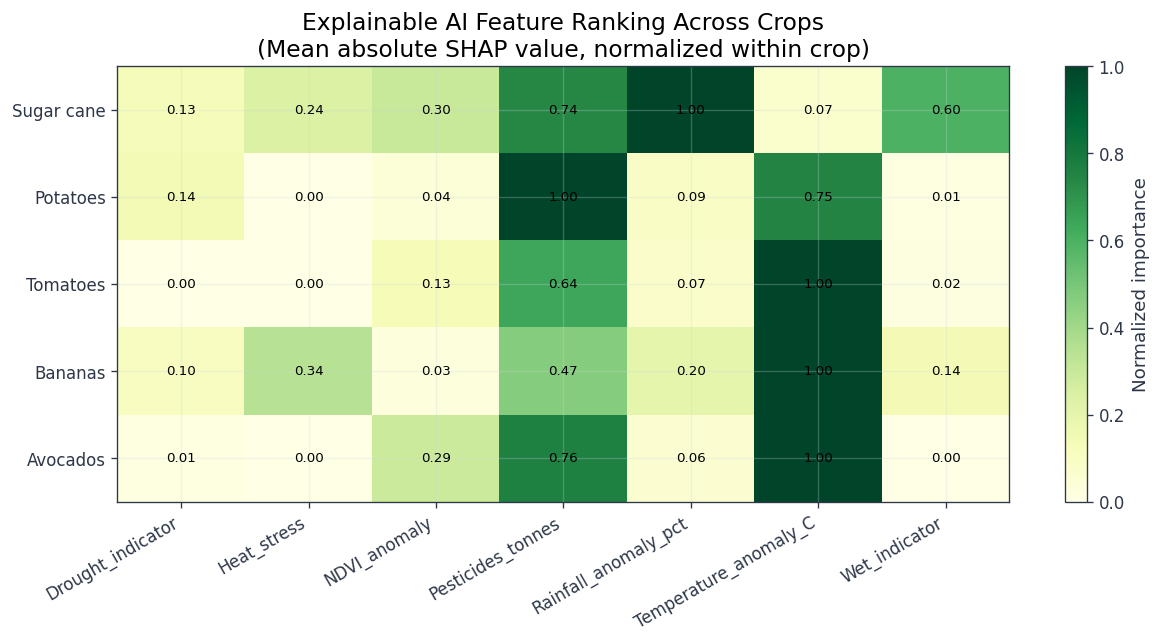

In [26]:
# Table 4.13 and Figure 4.10 — Explainable model results
if not perm_importance_df.empty:
    perm_top = (
        perm_importance_df
        .sort_values(["Crop", "Importance_mean"], ascending=[True, False])
        .groupby("Crop")
        .head(3)
        .reset_index(drop=True)
    )
    show_table("Table 4.13 Top Predictive Features from Permutation Importance", perm_top)
else:
    display(Markdown("**Table 4.13 Top Predictive Features from Permutation Importance**"))
    display(pd.DataFrame({"Message": ["Permutation importance results are not available."]}))

fig_4_08_explainable_ai_matrix()

## 11. Climate Scenario Simulation

This section evaluates how the selected climate-impact models respond when temperature and rainfall inputs are altered. The scenarios are controlled statistical experiments intended to support sensitivity analysis rather than deterministic biophysical projection.


### 11.1 Run Climate Scenario Simulations

This subsection applies defined temperature and rainfall changes to the selected climate-impact models and compares each scenario prediction with its baseline prediction.


In [27]:
%%capture
# ============================================================
# 14. CLIMATE SCENARIO SIMULATION AND SENSITIVITY ANALYSIS (final)
# ============================================================

def apply_scenario(row, temp_delta=0.0, rainfall_delta_pct=0.0):
    """Apply scenario changes and recompute climate-impact features."""
    r = row.copy()

    # Raw scenario changes
    r["Temperature_C"] = r["Temperature_C"] + temp_delta
    r["Rainfall_mm"] = r["Rainfall_mm"] * (1 + rainfall_delta_pct / 100.0)

    # Recompute anomaly variables using historical reference means
    rain_mean = data_fe["Rainfall_mm"].mean()
    temp_mean = data_fe["Temperature_C"].mean()

    r["Rainfall_anomaly_mm"] = r["Rainfall_mm"] - rain_mean
    r["Rainfall_anomaly_pct"] = 100 * r["Rainfall_anomaly_mm"] / rain_mean
    r["Temperature_anomaly_C"] = r["Temperature_C"] - temp_mean

    r["Drought_indicator"] = int(r["Rainfall_anomaly_pct"] <= -10)
    r["Wet_indicator"] = int(r["Rainfall_anomaly_pct"] >= 10)
    r["Heat_stress"] = int(
        r["Temperature_anomaly_C"] >= data_fe["Temperature_anomaly_C"].quantile(0.75)
    )

    # Backward-compatible aliases
    r["Drought_year"] = r["Drought_indicator"]
    r["Wet_year"] = r["Wet_indicator"]

    return r


SCENARIOS = {
    "Baseline": (0, 0),
    "Low warming (+1C)": (1, 0),
    "Moderate warming (+2C)": (2, 0),
    "High warming (+3C)": (3, 0),
    "Drying (-10% rainfall)": (0, -10),
    "Severe drying (-20% rainfall)": (0, -20),
    "Wetter (+15% rainfall)": (0, 15),
    "Moderate warming + drying": (2, -10),
    "High warming + severe drying": (3, -20),
}


def predict_scenario(crop, temp_delta=0, rainfall_delta_pct=0):
    info = interpretive_models.get(crop)

    if info is None or info["pipe"] is None:
        return None

    feats = info["features"]
    latest = data_fe[data_fe["Item"] == crop].sort_values("Year").iloc[-1].copy()

    baseline_pred = float(info["pipe"].predict(pd.DataFrame([latest[feats]]))[0])

    scenario_row = apply_scenario(
        latest,
        temp_delta=temp_delta,
        rainfall_delta_pct=rainfall_delta_pct
    )

    scenario_pred = float(info["pipe"].predict(pd.DataFrame([scenario_row[feats]]))[0])

    change_pct = (
        100 * (scenario_pred - baseline_pred) / baseline_pred
        if baseline_pred != 0 else np.nan
    )

    return {
        "Crop": crop,
        "Base_Year": int(latest["Year"]),
        "Scenario_Temp_Delta_C": temp_delta,
        "Scenario_Rainfall_Delta_Pct": rainfall_delta_pct,
        "Baseline_Prediction": baseline_pred,
        "Scenario_Prediction": scenario_pred,
        "Change_pct": change_pct,
        "Risk_Level": risk_label(change_pct)
    }


# 14.1 Scenario table
scenario_rows = []

for crop in REPRESENTATIVE_CROPS:
    for name, (td, rd) in SCENARIOS.items():
        res = predict_scenario(crop, td, rd)
        if res:
            res["Scenario"] = name
            scenario_rows.append(res)

scenario_df = pd.DataFrame(scenario_rows)
save_table(scenario_df, "Table_4_18_scenario_simulation_results_final")
display(scenario_df.head(30))


# 14.2 Scenario heatmap
pivot = scenario_df.pivot_table(index="Scenario", columns="Crop", values="Change_pct")

plt.figure(figsize=(12,6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Predicted yield change (%)")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Scenario Impact Heatmap by Crop")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

save_fig("Figure_4_scenario_impact_heatmap_final")
plt.show()


# 14.3 Sensitivity analysis
sensitivity_rows = []

for crop in REPRESENTATIVE_CROPS:
    # temperature sensitivity
    for td in np.arange(0, 3.5, 0.5):
        res = predict_scenario(crop, temp_delta=float(td), rainfall_delta_pct=0)
        if res:
            res["Sensitivity_Type"] = "Temperature"
            res["Sensitivity_Value"] = td
            sensitivity_rows.append(res)

    # rainfall sensitivity
    for rd in np.arange(-30, 31, 10):
        res = predict_scenario(crop, temp_delta=0, rainfall_delta_pct=float(rd))
        if res:
            res["Sensitivity_Type"] = "Rainfall"
            res["Sensitivity_Value"] = rd
            sensitivity_rows.append(res)

sensitivity_df = pd.DataFrame(sensitivity_rows)
save_table(sensitivity_df, "Table_4_19_sensitivity_analysis_final")

for crop in REPRESENTATIVE_CROPS:
    sub = sensitivity_df[
        (sensitivity_df["Crop"] == crop) &
        (sensitivity_df["Sensitivity_Type"] == "Temperature")
    ]

    if not sub.empty:
        plt.figure(figsize=(7,4))
        plt.plot(sub["Sensitivity_Value"], sub["Change_pct"], marker="o")
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.title(f"{crop}: Temperature Sensitivity")
        plt.xlabel("Temperature increase (°C)")
        plt.ylabel("Predicted yield change (%)")
        plt.grid(True, alpha=0.3)
        save_fig(f"Figure_4_temperature_sensitivity_{crop_slug(crop)}_final")
        plt.show()

    sub = sensitivity_df[
        (sensitivity_df["Crop"] == crop) &
        (sensitivity_df["Sensitivity_Type"] == "Rainfall")
    ]

    if not sub.empty:
        plt.figure(figsize=(7,4))
        plt.plot(sub["Sensitivity_Value"], sub["Change_pct"], marker="o")
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.title(f"{crop}: Rainfall Sensitivity")
        plt.xlabel("Rainfall change (%)")
        plt.ylabel("Predicted yield change (%)")
        plt.grid(True, alpha=0.3)
        save_fig(f"Figure_4_rainfall_sensitivity_{crop_slug(crop)}_final")
        plt.show()


### 11.2 Present Scenario Results

This subsection presents the crop-level scenario table, impact heatmap, and sensitivity curves. The outputs show how modelled responses vary across crops and climate assumptions.


**Table 4.14 Scenario Simulation Results**

,Crop,Scenario,Scenario_Temp_Delta_C,Scenario_Rainfall_Delta_Pct,Baseline_Prediction,Scenario_Prediction,Change_pct,Risk_Level
0,Avocados,Baseline,0,0,156414.236,156414.236,0.000,Low / stable impact
1,Avocados,Drying (-10% rainfall),0,-10,156414.236,156200.868,-0.136,Low / stable impact
2,Avocados,High warming (+3C),3,0,156414.236,156414.236,0.000,Low / stable impact
3,Avocados,High warming + severe drying,3,-20,156414.236,156126.076,-0.184,Low / stable impact
4,Avocados,Low warming (+1C),1,0,156414.236,156414.236,0.000,Low / stable impact
5,Avocados,Moderate warming (+2C),2,0,156414.236,156414.236,0.000,Low / stable impact
6,Avocados,Moderate warming + drying,2,-10,156414.236,156200.868,-0.136,Low / stable impact
7,Avocados,Severe drying (-20% rainfall),0,-20,156414.236,156126.076,-0.184,Low / stable impact
8,Avocados,Wetter (+15% rainfall),0,15,156414.236,156505.668,0.058,Low / stable impact
9,Bananas,Baseline,0,0,205845.886,228162.425,10.841,Positive / opportunity


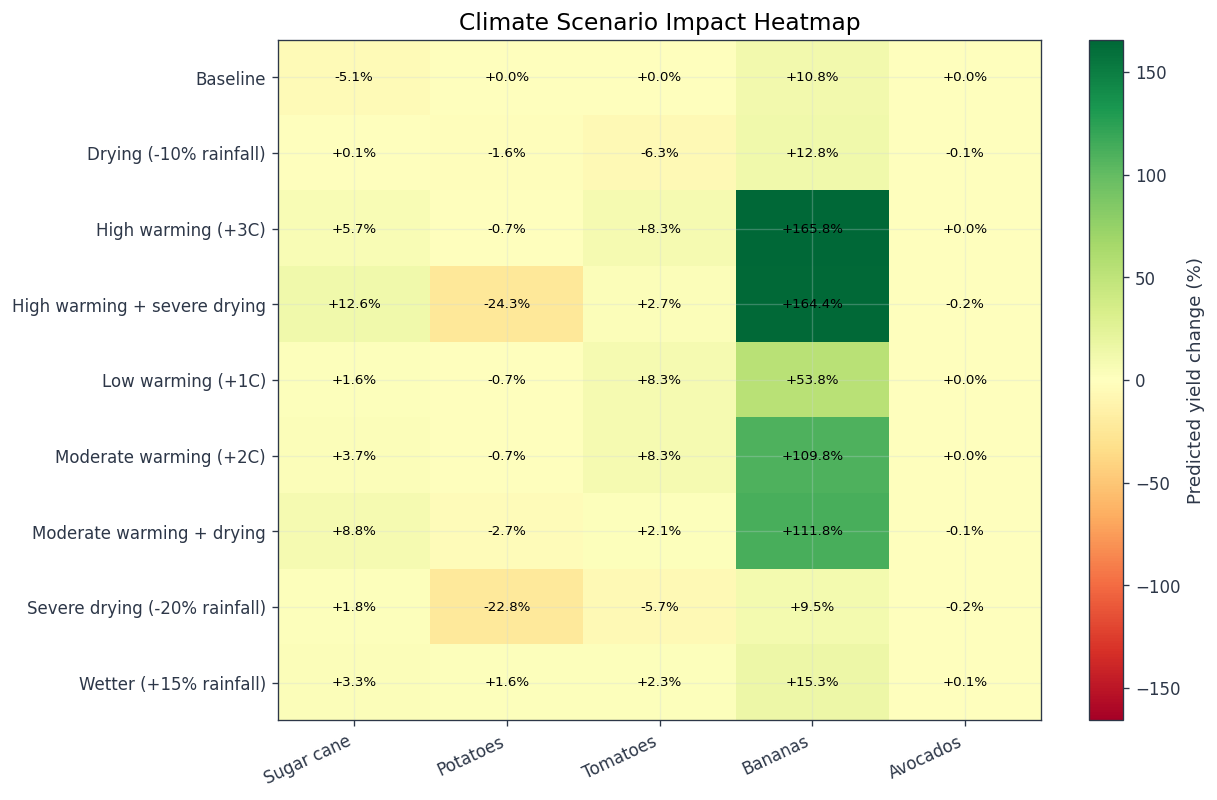

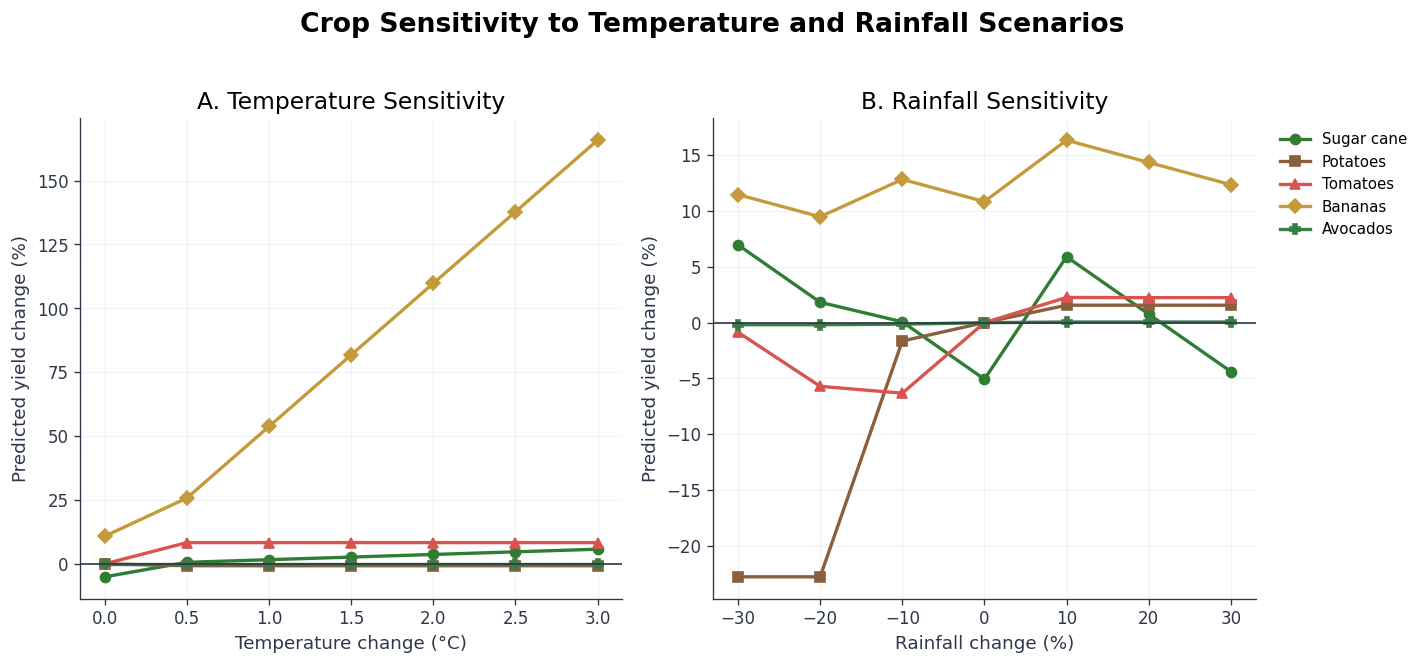

In [28]:
# Table 4.14 and Figures 4.11–4.12 — Climate scenario simulation
scenario_display = scenario_df[[
    "Crop", "Scenario", "Scenario_Temp_Delta_C", "Scenario_Rainfall_Delta_Pct",
    "Baseline_Prediction", "Scenario_Prediction", "Change_pct", "Risk_Level"
]].sort_values(["Crop", "Scenario"])
show_table("Table 4.14 Scenario Simulation Results", scenario_display, rows=40)
fig_4_09_scenario_heatmap()
fig_4_10_sensitivity_curves()

## 12. Recursive Forecasting

This section uses the selected climate-plus-lag models to generate annual future-yield trajectories. Previous predictions are fed recursively into later forecast steps, and residual-based intervals are included to communicate uncertainty.


### 12.1 Generate Recursive Forecasts

This subsection produces future yield paths for the selected forecast scenarios and records the corresponding approximate lower and upper prediction bounds.


In [29]:
%%capture
# ============================================================
# 15. FUTURE FORECASTING WITH UNCERTAINTY INTERVALS (final)
# ============================================================

def recursive_forecast(
    crop,
    years=range(FORECAST_START_YEAR, FORECAST_END_YEAR + 1),
    temp_delta_per_year=0.03,
    rainfall_delta_pct_per_year=0.0
):
    info = primary_models.get(crop)

    if info is None or info["pipe"] is None:
        return pd.DataFrame()

    feats = info["features"]
    hist = data_fe[data_fe["Item"] == crop].sort_values("Year").copy()

    current = hist.iloc[-1].copy()
    preds = []

    # latest lag values
    y_lag1 = float(current["Yield_hg_ha"])
    y_lag2 = float(hist.iloc[-2]["Yield_hg_ha"]) if len(hist) > 1 else y_lag1

    base_temp = float(current["Temperature_C"])
    base_rain = float(current["Rainfall_mm"])

    residual_std = residual_std_map.get((crop, "Climate+Lag"), np.nan)
    if np.isnan(residual_std):
        residual_std = 0.0

    for idx, yr in enumerate(years, start=1):
        row = current.copy()
        row["Year"] = yr

        # Climate assumptions
        row["Temperature_C"] = base_temp + temp_delta_per_year * idx
        row["Rainfall_mm"] = base_rain * (1 + rainfall_delta_pct_per_year / 100.0 * idx)

        # Recompute climate features
        row = apply_scenario(row, temp_delta=0, rainfall_delta_pct=0)

        # Recursive lag update
        row["Yield_hg_ha_lag1"] = y_lag1
        row["Yield_hg_ha_lag2"] = y_lag2

        pred = float(info["pipe"].predict(pd.DataFrame([row[feats]]))[0])

        lower_95 = pred - 1.96 * residual_std
        upper_95 = pred + 1.96 * residual_std

        preds.append({
            "Year": yr,
            "Crop": crop,
            "Predicted_Yield_hg_ha": pred,
            "Prediction_Lower_95": lower_95,
            "Prediction_Upper_95": upper_95,
            "Temp_Delta_Cumulative": row["Temperature_C"] - base_temp,
            "Rainfall_Change_Cumulative_pct": 100 * (row["Rainfall_mm"] - base_rain) / base_rain
        })

        y_lag2, y_lag1 = y_lag1, pred
        current = row

    return pd.DataFrame(preds)


forecast_rows = []

FORECAST_SCENARIOS = {
    "Reference warming trend": (0.03, 0),
    "Moderate warming + drying": (0.10, -1.0),
    "Severe warming + drying": (0.20, -2.0),
    "Warming + wetter rainfall": (0.10, 1.0),
}

for crop in REPRESENTATIVE_CROPS:
    ref = recursive_forecast(
        crop,
        temp_delta_per_year=0.03,
        rainfall_delta_pct_per_year=0
    )

    if ref.empty:
        continue

    ref = ref.rename(columns={"Predicted_Yield_hg_ha": "Reference_Prediction"})[
        ["Year", "Crop", "Reference_Prediction"]
    ]

    for scen, (td_year, rd_year) in FORECAST_SCENARIOS.items():
        f = recursive_forecast(
            crop,
            temp_delta_per_year=td_year,
            rainfall_delta_pct_per_year=rd_year
        )

        if f.empty:
            continue

        f["Forecast_Scenario"] = scen
        f = f.merge(ref, on=["Year", "Crop"], how="left")
        f["Change_vs_reference_pct"] = (
            100 * (f["Predicted_Yield_hg_ha"] - f["Reference_Prediction"]) /
            f["Reference_Prediction"]
        )

        forecast_rows.append(f)

future_forecast_df = (
    pd.concat(forecast_rows, ignore_index=True)
    if forecast_rows else pd.DataFrame()
)

save_table(future_forecast_df, "Table_4_20_recursive_future_forecasts_final")
display(future_forecast_df.head(40))


for crop in REPRESENTATIVE_CROPS:
    sub = future_forecast_df[future_forecast_df["Crop"] == crop]

    if sub.empty:
        continue

    plt.figure(figsize=(9,5))

    for scen, g in sub.groupby("Forecast_Scenario"):
        plt.plot(g["Year"], g["Predicted_Yield_hg_ha"], marker="o", label=scen)

        if scen == "Reference warming trend":
            plt.fill_between(
                g["Year"],
                g["Prediction_Lower_95"],
                g["Prediction_Upper_95"],
                alpha=0.2,
                label="95% interval"
            )

    plt.title(f"{crop}: Recursive Future Forecasts with Uncertainty")
    plt.xlabel("Year")
    plt.ylabel("Predicted Yield (hg/ha)")
    plt.ticklabel_format(style='plain', axis='y')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    save_fig(f"Figure_4_forecast_{crop_slug(crop)}_final")
    plt.show()


### 12.2 Present Forecast Results

This subsection presents selected forecast years and the multi-crop forecast figure. Historical observations, recursive forecasts, and uncertainty intervals are shown together to support cautious interpretation.


**Table 4.15 Forecasted Yield Values and Uncertainty Intervals**

,Year,Crop,Predicted_Yield_hg_ha,Prediction_Lower_95,Prediction_Upper_95,Temp_Delta_Cumulative,Rainfall_Change_Cumulative_pct,Forecast_Scenario,Reference_Prediction,Change_vs_reference_pct
0,2025,Sugar cane,667844.357,561022.597,774666.117,0.03,0.0,Reference warming trend,667844.357,0.000
1,2030,Sugar cane,646700.423,539878.663,753522.183,0.18,0.0,Reference warming trend,646700.423,0.000
2,2035,Sugar cane,639543.325,532721.565,746365.086,0.33,0.0,Reference warming trend,639543.325,0.000
3,2025,Sugar cane,670889.033,564067.273,777710.793,0.10,-1.0,Moderate warming + drying,667844.357,0.456
4,2030,Sugar cane,680465.373,573643.612,787287.133,0.60,-6.0,Moderate warming + drying,646700.423,5.221
5,2035,Sugar cane,707455.994,600634.234,814277.754,1.10,-11.0,Moderate warming + drying,639543.325,10.619
6,2025,Sugar cane,673325.334,566503.574,780147.094,0.20,-2.0,Severe warming + drying,667844.357,0.821
7,2030,Sugar cane,707483.543,600661.783,814305.303,1.20,-12.0,Severe warming + drying,646700.423,9.399
8,2035,Sugar cane,614118.050,507296.290,720939.810,2.20,-22.0,Severe warming + drying,639543.325,-3.976
9,2025,Sugar cane,661960.597,555138.837,768782.358,0.10,1.0,Warming + wetter rainfall,667844.357,-0.881


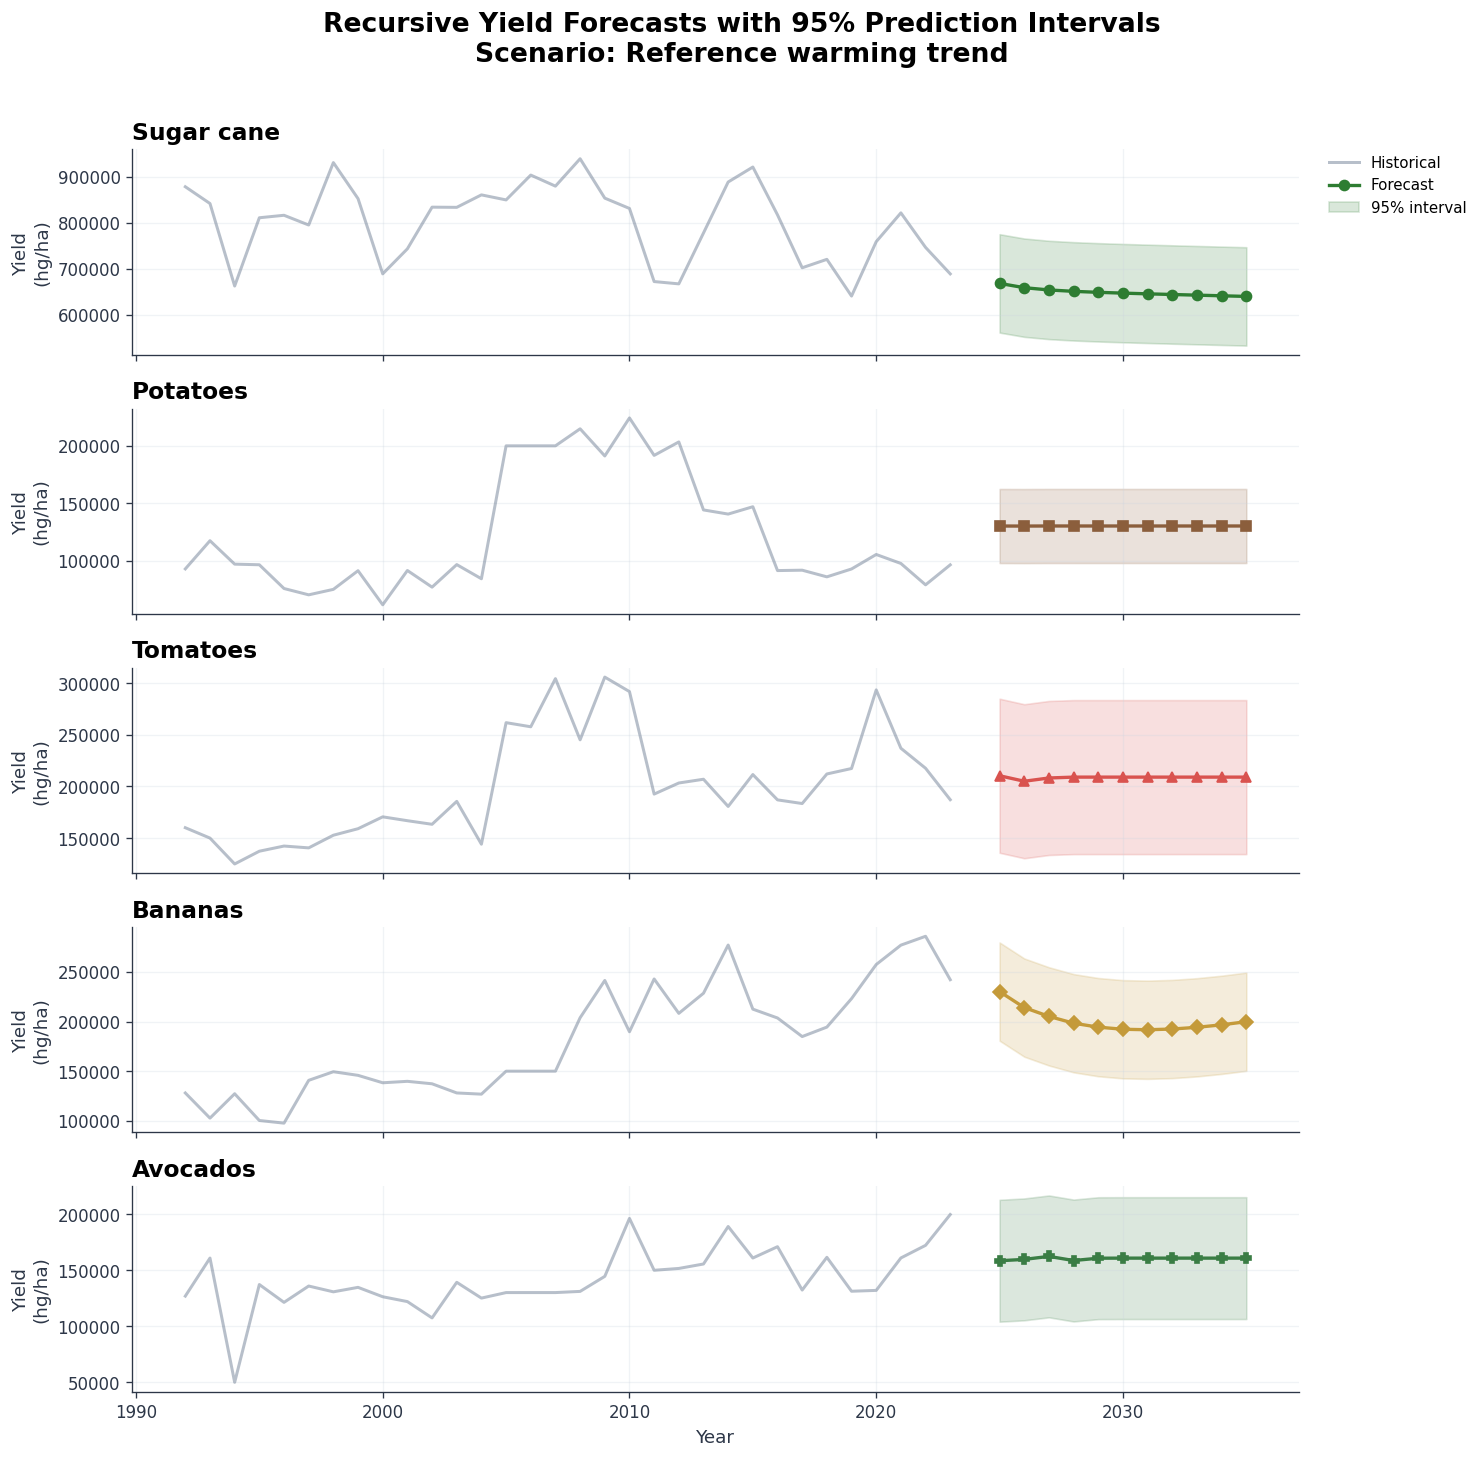

In [30]:
# Table 4.15 and Figure 4.13 — Recursive forecasting results
forecast_display = future_forecast_df.copy()
forecast_display = forecast_display[forecast_display["Year"].isin([2025, 2030, 2035])] if "Year" in forecast_display.columns else forecast_display
show_table("Table 4.15 Forecasted Yield Values and Uncertainty Intervals", forecast_display, rows=50)
fig_4_11_forecast_uncertainty()

## 13. Composite Vulnerability Ranking

This section combines scenario sensitivity and future forecast change into a comparative crop-level vulnerability index. The index is intended as a screening and prioritisation tool rather than a complete measure of socioeconomic vulnerability.


### 13.1 Calculate the Composite Vulnerability Index

This subsection standardises and combines the selected scenario and forecast indicators, assigns comparative risk groups, and produces a transparent ranking across the five crops.


In [31]:
%%capture
# ============================================================
# 16. COMPOSITE CLIMATE VULNERABILITY INDEX AND RISK RANKING (final)
# ============================================================
from sklearn.cluster import KMeans

risk_features = []

for crop in REPRESENTATIVE_CROPS:
    s = scenario_df[
        (scenario_df["Crop"] == crop) &
        (scenario_df["Scenario"].isin([
            "High warming (+3C)",
            "High warming + severe drying",
            "Severe drying (-20% rainfall)"
        ]))
    ]

    f = future_forecast_df[
        (future_forecast_df["Crop"] == crop) &
        (future_forecast_df["Forecast_Scenario"] == "Severe warming + drying")
    ]

    risk_features.append({
        "Crop": crop,
        "mean_scenario_change_pct": s["Change_pct"].mean() if not s.empty else np.nan,
        "worst_scenario_change_pct": s["Change_pct"].min() if not s.empty else np.nan,
        "forecast_2030_change_pct": f[f["Year"] == 2030]["Change_vs_reference_pct"].mean() if not f.empty else np.nan,
    })

risk_df = pd.DataFrame(risk_features).fillna(0)

# Vulnerability components:
# 1. Larger negative worst scenario = higher vulnerability
# 2. Larger negative mean scenario = higher vulnerability
# 3. Larger negative 2030 forecast change = higher vulnerability
risk_components = risk_df[
    [
        "mean_scenario_change_pct",
        "worst_scenario_change_pct",
        "forecast_2030_change_pct"
    ]
].copy()

# Convert to loss orientation: positive values mean vulnerability.
loss_oriented = -risk_components

scaler = MinMaxScaler()
scaled = scaler.fit_transform(loss_oriented)

risk_df["Composite_Vulnerability_Index"] = scaled.mean(axis=1)

# Cluster by vulnerability index and supporting variables
Xrisk = risk_df[
    [
        "Composite_Vulnerability_Index",
        "mean_scenario_change_pct",
        "worst_scenario_change_pct",
        "forecast_2030_change_pct"
    ]
]

if len(risk_df) >= 3:
    km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
    risk_df["Risk_Cluster"] = km.fit_predict(Xrisk)
else:
    risk_df["Risk_Cluster"] = 0

# Convert clusters into ordered labels by vulnerability index
cluster_order = (
    risk_df.groupby("Risk_Cluster")["Composite_Vulnerability_Index"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

label_map = {}
if len(cluster_order) > 0:
    label_map[cluster_order[0]] = "High sensitivity"
if len(cluster_order) > 1:
    label_map[cluster_order[1]] = "Moderate sensitivity"
if len(cluster_order) > 2:
    label_map[cluster_order[2]] = "Lower sensitivity"

risk_df["Climate_Risk_Group"] = risk_df["Risk_Cluster"].map(label_map)

risk_df = risk_df.sort_values("Composite_Vulnerability_Index", ascending=False)

save_table(risk_df, "Table_4_21_climate_risk_ranking_final")
display(risk_df)

plt.figure(figsize=(8,4.5))
plt.bar(risk_df["Crop"], risk_df["Composite_Vulnerability_Index"])
plt.title("Composite Climate Vulnerability Index")
plt.xlabel("Crop")
plt.ylabel("Vulnerability index")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
save_fig("Figure_4_composite_vulnerability_index_final")
plt.show()


### 13.2 Present the Vulnerability Ranking

This subsection presents the final ranking table and horizontal comparison figure. The results support identification of crops that warrant closer climate-risk assessment and adaptation planning.


**Table 4.16 Composite Crop Vulnerability Ranking**

,Crop,mean_scenario_change_pct,worst_scenario_change_pct,forecast_2030_change_pct,Composite_Vulnerability_Index,Risk_Cluster,Climate_Risk_Group
0,Potatoes,-15.913,-24.258,-12.904,1.000,0,High sensitivity
1,Tomatoes,1.773,-5.700,-3.247,0.724,2,Moderate sensitivity
2,Avocados,-0.123,-0.184,-0.220,0.659,2,Moderate sensitivity
3,Sugar cane,6.735,1.826,9.399,0.575,2,Moderate sensitivity
4,Bananas,113.230,9.482,55.366,0.000,1,Lower sensitivity


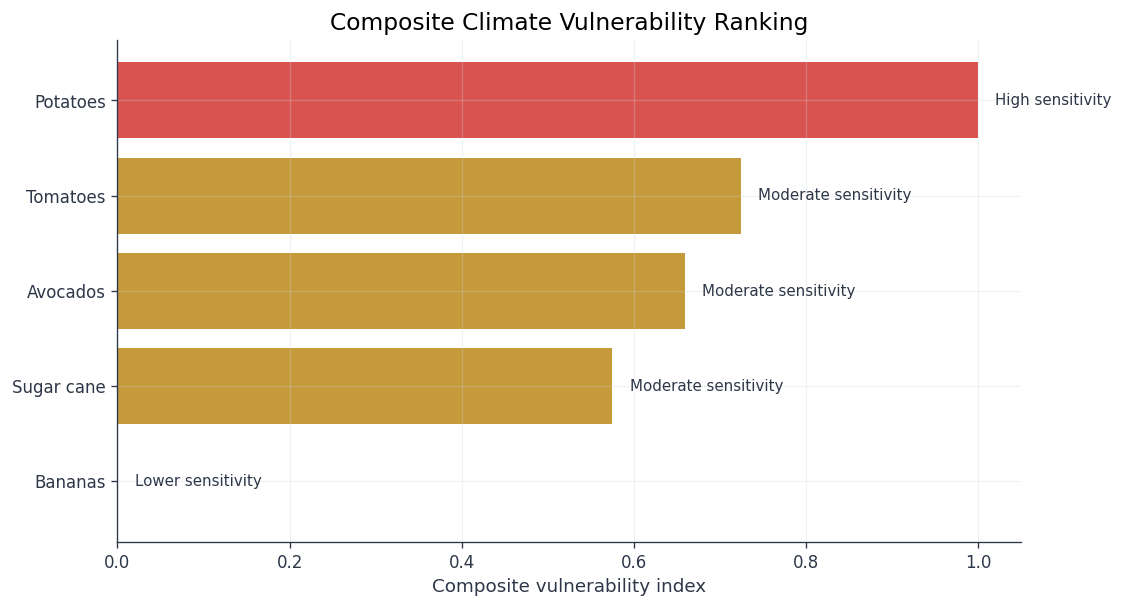

In [32]:
# Table 4.16 and Figure 4.14 — Composite vulnerability ranking
risk_display = risk_df.sort_values("Composite_Vulnerability_Index", ascending=False)
show_table("Table 4.16 Composite Crop Vulnerability Ranking", risk_display)
fig_4_12_vulnerability_ranking()

## 14. Decision-Support Workflow

This section summarises how the experiment moves from climate and agricultural data to preprocessing, statistical analysis, machine learning, explainability, scenario analysis, forecasting, vulnerability ranking, and dashboard-based decision support.


### 14.1 Create the Decision-Support Workflow

This subsection produces a clean methodological workflow with consistent white boxes, blue borders, and non-overlapping blue arrows. The figure provides a concise visual map of the complete analytical architecture.


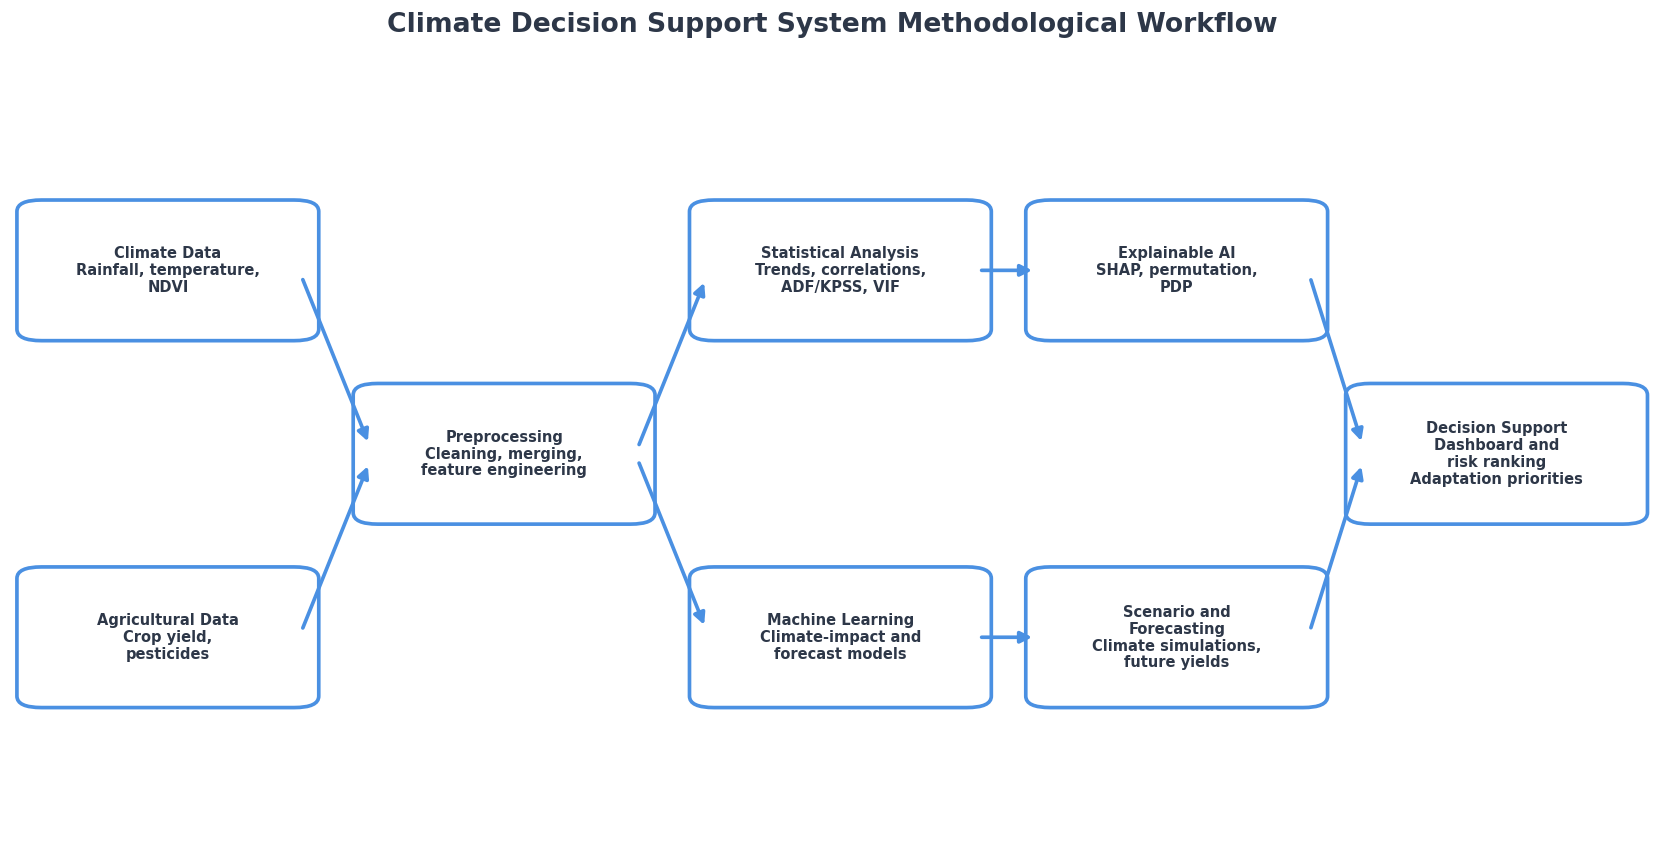

In [33]:
# Figure 4.15 — Decision-support workflow
fig_4_13_dss_workflow()

## 15. Interactive Decision-Support Dashboard

This final section converts the analytical outputs into an interactive decision-support interface. It is placed after the statistical, modelling, explainability, scenario, forecasting, and vulnerability sections so that all required objects are available when the application is built. The dashboard presents national indicators, crop-specific analysis, climate scenarios, yield forecasts, model interpretation, and vulnerability insights without changing the underlying analytical results.


### 15.1 Dashboard Configuration

This subsection defines the dashboard title, colour palette, crop descriptions, image assets, and shared visual settings. It also downloads, standardises, and caches the icons and crop photographs used by the interface.


In [34]:
from pathlib import Path
import base64
import io
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr

from PIL import Image, ImageOps

# ------------------------------------------------------------
# 0. DASHBOARD CONFIGURATION
# ------------------------------------------------------------

DASHBOARD_TITLE = "Climate-Agriculture Decision Support System"
DASHBOARD_SUBTITLE = "National climate–agriculture evidence for Kenya"
THESIS_TITLE = "The Prediction of the Impact of Climate Change on Agricultural Productivity in Kenya Using Machine Learning"

AUTHOR_NAME = "Samuel Kimani"
SUPERVISOR_NAME = "Supervisor"
UNIVERSITY_NAME = "Institut Teknologi Sepuluh Nopember (ITS)"
DEPARTMENT_NAME = "Department / Faculty"
SELECT_CROP_OPTION = "Select crop..."

PALETTE = {
    "navy": "#102A43",
    "forest_dark": "#163F32",
    "forest": "#2F6B4F",
    "leaf": "#4E8B64",
    "sky": "#4F86B6",
    "wheat": "#C69A3B",
    "danger": "#B55252",
    "charcoal": "#243B53",
    "muted": "#6B7C8F",
    "background": "#F4F7F5",
    "card": "#FFFFFF",
    "border": "#DCE5E0",
    "soft_green": "#ECF4EF",
    "soft_blue": "#EDF4FA",
    "soft_amber": "#FBF5E8",
    "soft_red": "#F9ECEC",
}

CROP_SHORT_DESCRIPTION = {
    "Sugar cane": "Industrial cash crop with high water demand.",
    "Potatoes": "Staple root and tuber crop important for food security.",
    "Tomatoes": "Vegetable crop representing horticultural production.",
    "Bananas": "Tropical perennial food crop.",
    "Avocados": "High-value horticultural crop with export importance.",
}

# Google Drive file IDs supplied for the dashboard assets.
# The first ID is used as the farmland photograph. The dedicated
# Kenya map ID is used for the system mark and navigation icon.
ASSET_IDS = {
    "farmland": "1v4wKAfL0tPzBSdKE0_7XXVU8eJSofMiZ",
    "leaf": "11-PgK7G69ClkY-EOZmYlVnAqw141SDIn",
    "thermometer": "1hvi1XaMsSqL920AdR1FtwSjru6UyIU6T",
    "trend": "1FI-tRPAcOJaMO6ZO7vIChmSsk1TclOA2",
    "model": "12I1TMrXB09wcEw2d_D6QniIk1j60tZhi",
    "policy": "1154qXrTMCuBpK6ASXPzPbFUgKrhbMf6s",
    "info": "1-3cg32zP-TX3bdwLpDDaQlXZhtr7z4Vw",
    "tea_maize": "1-tEcQH0Uw_ws1fW8TxqUCYW3cot4Iwz4",
    "avocado": "1RLbxO_5NhLRQvc9sjnQqVmf9HE24ISd5",
    "banana": "1BvCprAOSFu6TsENbgZ5r85SFtanrWd3P",
    "potato": "1Fr0Rnsnj2deoeYiRnlhArVj2V-ircDkL",
    "tomato": "1XogCM5wdtqH2KEyDCP5NH921m9NnPMC8",
    "sugarcane": "1uY8MadvYayxh8ItsxUKy0y6VkMzPk6TH",
    "landscape": "1Fv-d5hYW8KSLiJ-4hHDDDkny57RFwcTq",
    "satellite": "1IRwpj9AO3MmGVvhIxby62jh_81XAq5Xz",
    "kenya_map": "1U_UDZfvlyuNRo7JeMs9DVGgoA-yAcXw7",
}

ASSET_DIR = Path("climate_dss_assets")
RAW_ASSET_DIR = ASSET_DIR / "raw"
PROCESSED_ASSET_DIR = ASSET_DIR / "processed"
RAW_ASSET_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_ASSET_DIR.mkdir(parents=True, exist_ok=True)

ICON_KEYS = ["leaf", "thermometer", "trend", "model", "policy", "info", "kenya_map"]
PHOTO_KEYS = ["farmland", "tea_maize", "avocado", "banana", "potato", "tomato", "sugarcane", "landscape", "satellite"]


def _ensure_gdown():
    """Install gdown only when it is not already available."""
    try:
        import gdown  # noqa: F401
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "gdown"]
        )


def _download_drive_asset(file_id, output_path):
    """Download one public Google Drive file and cache it locally."""
    output_path = Path(output_path)
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    _ensure_gdown()
    import gdown

    downloaded = gdown.download(
        id=file_id,
        output=str(output_path),
        quiet=True,
        fuzzy=True,
    )

    if downloaded is None or not output_path.exists():
        raise RuntimeError(
            f"Could not download asset {file_id}. "
            "Confirm that the Google Drive file is shared as 'Anyone with the link'."
        )
    return output_path


def _remove_near_white_background(image, threshold=246):
    """Convert a light JPG/PNG icon background to transparency."""
    rgba = image.convert("RGBA")
    arr = np.array(rgba)
    rgb = arr[:, :, :3]
    near_white = np.all(rgb >= threshold, axis=2)
    arr[near_white, 3] = 0
    return Image.fromarray(arr)


def _normalise_icon(source_path, output_path, canvas_size=96, content_size=60):
    """Place every icon on the same transparent square canvas."""
    image = Image.open(source_path)
    image = _remove_near_white_background(image)

    alpha = image.getchannel("A")
    bbox = alpha.getbbox()
    if bbox:
        image = image.crop(bbox)

    image.thumbnail((content_size, content_size), Image.Resampling.LANCZOS)
    canvas = Image.new("RGBA", (canvas_size, canvas_size), (255, 255, 255, 0))
    x = (canvas_size - image.width) // 2
    y = (canvas_size - image.height) // 2
    canvas.alpha_composite(image, (x, y))
    canvas.save(output_path, "PNG")
    return Path(output_path)


def _prepare_photo(source_path, output_path, size):
    """Crop photographs to a consistent dashboard aspect ratio."""
    image = Image.open(source_path).convert("RGB")
    image = ImageOps.fit(
        image,
        size,
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    image.save(output_path, "JPEG", quality=88, optimize=True)
    return Path(output_path)


def _file_to_data_uri(path):
    """Embed a local image directly in Gradio HTML and CSS."""
    path = Path(path)
    suffix = path.suffix.lower()
    mime = "image/png" if suffix == ".png" else "image/jpeg"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime};base64,{encoded}"


def prepare_dashboard_assets():
    """Download, standardise, and return all dashboard assets as data URIs."""
    processed = {}
    missing = []

    for key, file_id in ASSET_IDS.items():
        raw_path = RAW_ASSET_DIR / f"{key}.asset"
        try:
            _download_drive_asset(file_id, raw_path)

            if key in ICON_KEYS:
                out_path = PROCESSED_ASSET_DIR / f"{key}.png"
                _normalise_icon(raw_path, out_path)
            elif key == "landscape":
                out_path = PROCESSED_ASSET_DIR / f"{key}.jpg"
                _prepare_photo(raw_path, out_path, (1600, 520))
            elif key == "satellite":
                out_path = PROCESSED_ASSET_DIR / f"{key}.jpg"
                _prepare_photo(raw_path, out_path, (900, 520))
            else:
                out_path = PROCESSED_ASSET_DIR / f"{key}.jpg"
                _prepare_photo(raw_path, out_path, (900, 520))

            processed[key] = _file_to_data_uri(out_path)

        except Exception as exc:
            processed[key] = ""
            missing.append((key, str(exc)))

    if missing:
        print("Some visual assets could not be loaded:")
        for key, message in missing:
            print(f"- {key}: {message}")
        print("The dashboard will still run using clean visual fallbacks.")
    else:
        print("Dashboard visual assets loaded successfully.")

    return processed


ASSET_URI = prepare_dashboard_assets()

# Crop-specific photographs. General landscape imagery is used when a
# crop-specific photograph was not supplied.
CROP_IMAGE_KEY = {
    "Sugar cane": "sugarcane",
    "Avocados": "avocado",
    "Potatoes": "potato",
    "Tomatoes": "tomato",
    "Bananas": "banana",
}


Dashboard visual assets loaded successfully.


### 15.2 Visual Style

This subsection defines the responsive layout, sidebar, masthead, cards, figure panels, tables, footer, and typography. The design uses a restrained climate–agriculture palette and separates figure headers from plotting areas to preserve readability.


In [35]:
# ------------------------------------------------------------
# 1. VISUAL STYLE
# ------------------------------------------------------------


def _css_url(asset_key):
    uri = ASSET_URI.get(asset_key, "")
    return f"url('{uri}')" if uri else "none"


CSS = f"""
:root {{
    --navy: {PALETTE['navy']};
    --forest-dark: {PALETTE['forest_dark']};
    --forest: {PALETTE['forest']};
    --leaf: {PALETTE['leaf']};
    --sky: {PALETTE['sky']};
    --wheat: {PALETTE['wheat']};
    --danger: {PALETTE['danger']};
    --ink: {PALETTE['charcoal']};
    --muted: {PALETTE['muted']};
    --paper: {PALETTE['background']};
    --card: {PALETTE['card']};
    --border: {PALETTE['border']};
}}

.gradio-container {{
    max-width: 1600px !important;
    margin: 0 auto !important;
    padding: 0 !important;
    background: var(--paper) !important;
    font-family: Inter, Arial, sans-serif !important;
    color: var(--ink) !important;
}}

body {{
    background: var(--paper) !important;
}}

#app-shell {{
    gap: 0 !important;
    min-height: 100vh;
    align-items: stretch !important;
}}

#sidebar {{
    min-width: 250px !important;
    max-width: 275px !important;
    background: linear-gradient(180deg, #143C30 0%, #0F3027 100%) !important;
    padding: 24px 18px !important;
    border-right: 1px solid rgba(255,255,255,0.06) !important;
    min-height: 100vh !important;
    position: sticky !important;
    top: 0 !important;
    align-self: flex-start !important;
}}

#workspace {{
    padding: 0 28px 40px 28px !important;
    min-width: 0 !important;
}}

.brand-block {{
    display: flex;
    align-items: center;
    gap: 12px;
    padding: 2px 2px 22px 2px;
    border-bottom: 1px solid rgba(255,255,255,0.13);
    margin-bottom: 18px;
}}

.brand-mark {{
    width: 46px;
    height: 46px;
    object-fit: contain;
    background: rgba(255,255,255,0.08);
    border-radius: 10px;
    padding: 6px;
}}

.brand-title {{
    color: #FFFFFF;
    font-weight: 760;
    font-size: 16px;
    line-height: 1.2;
}}

.brand-subtitle {{
    color: rgba(255,255,255,0.66);
    font-size: 11px;
    margin-top: 4px;
}}

.sidebar-label {{
    color: rgba(255,255,255,0.65);
    font-size: 11px;
    font-weight: 700;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    margin: 14px 0 8px 2px;
}}

#global-crop label span {{
    color: rgba(255,255,255,0.75) !important;
    font-size: 12px !important;
}}

#global-crop {{
    background: #FFFFFF !important;
    border-radius: 8px !important;
    padding: 4px !important;
}}

#global-crop > div,
#global-crop .wrap,
#global-crop input,
#global-crop textarea,
#global-crop button {{
    background: #FFFFFF !important;
    color: var(--navy) !important;
    border-color: #D5E0DA !important;
}}

#global-crop input::placeholder {{
    color: #6B7C8F !important;
    opacity: 1 !important;
}}

#global-crop svg {{
    color: var(--navy) !important;
    fill: var(--navy) !important;
}}

.nav-button button {{
    width: 100% !important;
    justify-content: flex-start !important;
    text-align: left !important;
    border: 0 !important;
    border-radius: 8px !important;
    background-color: transparent !important;
    color: rgba(255,255,255,0.78) !important;
    font-weight: 600 !important;
    padding: 11px 12px 11px 46px !important;
    min-height: 44px !important;
    box-shadow: none !important;
    transition: background-color .18s ease, color .18s ease !important;
}}

.nav-button button:hover {{
    background-color: rgba(255,255,255,0.09) !important;
    color: #FFFFFF !important;
}}

#nav-home button {{ background-image: {_css_url('kenya_map')} !important; }}
#nav-crop button {{ background-image: {_css_url('leaf')} !important; }}
#nav-scenario button {{ background-image: {_css_url('thermometer')} !important; }}
#nav-forecast button {{ background-image: {_css_url('trend')} !important; }}
#nav-explain button {{ background-image: {_css_url('model')} !important; }}
#nav-policy button {{ background-image: {_css_url('policy')} !important; }}
#nav-about button {{ background-image: {_css_url('info')} !important; }}

#nav-home button,
#nav-crop button,
#nav-scenario button,
#nav-forecast button,
#nav-explain button,
#nav-policy button,
#nav-about button {{
    background-repeat: no-repeat !important;
    background-position: 15px center !important;
    background-size: 21px 21px !important;
}}

.sidebar-note {{
    margin-top: 24px;
    padding: 14px 12px;
    border-top: 1px solid rgba(255,255,255,0.13);
    color: rgba(255,255,255,0.58);
    font-size: 11px;
    line-height: 1.55;
}}

#masthead {{
    min-height: 210px;
    border-radius: 14px;
    padding: 32px 36px;
    color: white;
    margin-top: 0 !important;
    margin-bottom: 24px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
    overflow: hidden;
    position: relative;
    background:
        linear-gradient(90deg, rgba(8,35,50,0.88) 0%, rgba(13,56,49,0.66) 50%, rgba(13,56,49,0.34) 100%),
        {_css_url('landscape')};
    background-size: cover;
    background-position: center;
    box-shadow: 0 12px 28px rgba(16,42,67,0.15);
}}

.masthead-content {{
    width: 100%;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
}}

.masthead-title {{
    color: #FFFFFF !important;
    font-size: 40px !important;
    font-weight: 750 !important;
    line-height: 1.15 !important;
    margin: 0 !important;
    padding: 0 !important;
    text-align: center !important;
    letter-spacing: -0.02em !important;
    text-shadow: 0 2px 8px rgba(0, 0, 0, 0.55);
}}

#masthead h1,
#masthead .masthead-title {{
    color: #FFFFFF !important;
}}

.page-header {{
    margin: 2px 0 16px 0;
}}

.page-eyebrow {{
    color: var(--forest);
    font-size: 12px;
    font-weight: 750;
    text-transform: uppercase;
    letter-spacing: 0.1em;
}}

.page-title {{
    color: var(--navy);
    font-size: 25px;
    font-weight: 780;
    margin: 4px 0 4px 0;
}}

.page-description {{
    color: var(--muted);
    font-size: 14px;
    max-width: 900px;
    line-height: 1.55;
}}

.insight-panel,
.dashboard-card {{
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 20px 22px;
    margin: 8px 0 16px 0;
    box-shadow: 0 5px 18px rgba(36,59,83,0.055);
}}

.metric-grid {{
    display: grid;
    grid-template-columns: repeat(4, minmax(150px, 1fr));
    gap: 12px;
    margin: 16px 0 4px 0;
}}

.metric-card {{
    background: #FFFFFF;
    border: 1px solid var(--border);
    border-top: 3px solid var(--forest);
    border-radius: 10px;
    padding: 15px 16px;
    min-height: 126px;
}}

.metric-head {{
    display: flex;
    align-items: center;
    gap: 8px;
    color: var(--muted);
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: .07em;
    font-weight: 750;
}}

.metric-icon {{
    width: 23px;
    height: 23px;
    object-fit: contain;
}}

.metric-value {{
    color: var(--navy);
    font-size: 25px;
    font-weight: 780;
    margin-top: 10px;
    line-height: 1.1;
}}

.metric-note {{
    color: var(--muted);
    font-size: 11px;
    margin-top: 7px;
    line-height: 1.4;
}}

.finding-strip {{
    border-left: 4px solid var(--forest);
    background: var(--soft-green);
    padding: 13px 15px;
    border-radius: 6px;
    margin-top: 14px;
    color: var(--charcoal);
    font-size: 13px;
    line-height: 1.55;
}}

.crop-banner {{
    min-height: 175px;
    border-radius: 12px;
    padding: 24px 28px;
    color: white;
    margin: 8px 0 16px 0;
    display: flex;
    align-items: end;
    background-size: cover !important;
    background-position: center !important;
    box-shadow: 0 8px 22px rgba(16,42,67,0.12);
}}

.crop-banner h2 {{
    color: #FFFFFF !important;
    font-size: 31px !important;
    font-weight: 780 !important;
    margin: 0 !important;
    text-shadow: 0 2px 8px rgba(0,0,0,0.68);
}}

.crop-banner h2 * {{
    color: #FFFFFF !important;
}}

.risk-band {{
    padding: 14px 16px;
    border-radius: 8px;
    margin: 12px 0 4px 0;
    font-size: 13px;
}}

.risk-low {{
    background: var(--soft-green);
    color: #214F3A;
    border-left: 4px solid var(--forest);
}}

.risk-moderate {{
    background: var(--soft-amber);
    color: #6C511C;
    border-left: 4px solid var(--wheat);
}}

.risk-high {{
    background: var(--soft-red);
    color: #713737;
    border-left: 4px solid var(--danger);
}}

.section-note {{
    color: var(--muted);
    font-size: 12px;
    line-height: 1.55;
    margin-top: 10px;
}}


/* Figure cards use a separate header row above the plotting area. */
.figure-panel {{
    gap: 0 !important;
    padding: 0 !important;
    overflow: hidden !important;
    background: #FFFFFF !important;
    border: 1px solid var(--border) !important;
    border-radius: 10px !important;
}}

.figure-title-block {{
    margin: 0 !important;
    padding: 0 !important;
    border: 0 !important;
    background: transparent !important;
    box-shadow: none !important;
}}

.figure-header {{
    min-height: 42px;
    display: flex;
    align-items: center;
    box-sizing: border-box;
    padding: 10px 14px;
    color: var(--forest);
    background: #F2F8F4;
    border-bottom: 1px solid var(--border);
    font-size: 14px;
    font-weight: 750;
    line-height: 1.25;
}}

.chart-plot {{
    margin: 0 !important;
    padding: 0 !important;
    border: 0 !important;
    border-radius: 0 !important;
    box-shadow: none !important;
}}

.chart-plot .block-label {{
    display: none !important;
}}

.figure-label {{
    color: var(--navy);
    font-weight: 700;
    font-size: 13px;
}}

.primary-action button {{
    background: var(--forest) !important;
    color: white !important;
    border: 0 !important;
    border-radius: 8px !important;
    font-weight: 700 !important;
    min-height: 44px !important;
    box-shadow: 0 4px 12px rgba(47,107,79,0.18) !important;
}}

.primary-action button:hover {{
    background: #285C44 !important;
}}

.gradio-dataframe {{
    border-radius: 10px !important;
    overflow: hidden !important;
    border: 1px solid var(--border) !important;
}}

.footer {{
    width: 100%;
    box-sizing: border-box;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center !important;
    color: var(--muted);
    font-size: 11px;
    padding: 18px 2px 2px 2px;
    border-top: 1px solid var(--border);
    margin-top: 24px;
}}

@media (max-width: 1050px) {{
    #sidebar {{
        min-width: 220px !important;
        max-width: 230px !important;
    }}
    .metric-grid {{
        grid-template-columns: repeat(2, minmax(150px, 1fr));
    }}
}}

@media (max-width: 780px) {{
    #app-shell {{
        display: block !important;
    }}
    #sidebar {{
        position: relative !important;
        max-width: none !important;
        min-width: 0 !important;
        min-height: auto !important;
    }}
    #workspace {{
        padding: 18px !important;
    }}
    #masthead {{
        min-height: 250px;
        padding: 24px;
    }}
    .masthead-title {{
        color: #FFFFFF !important;
        font-size: 27px !important;
        text-align: center !important;
    }}
    .metric-grid {{
        grid-template-columns: 1fr;
    }}
}}
"""

### 15.3 Dashboard Helper Functions

This subsection defines reusable functions for crop selection, formatting, risk classification, KPI cards, model summaries, policy tables, asset handling, and crop-specific recommendations.


In [36]:
# ------------------------------------------------------------
# 2. HELPER FUNCTIONS
# ------------------------------------------------------------


def _target():
    return globals().get("TARGET", "Yield_hg_ha")


def fmt_num(x, digits=0):
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x):,.{digits}f}"
    except Exception:
        return "N/A"


def crop_label(crop):
    return str(crop)


def crop_is_selected(crop):
    """Return True only when the user has selected a valid representative crop."""
    return crop in globals().get("REPRESENTATIVE_CROPS", [])


def crop_selection_message(section_name="this analysis"):
    """Provide a clear prompt when no crop has been selected."""
    return f"""
    <div class='dashboard-card'>
        <h3 style='margin-top:0;color:{PALETTE['navy']};'>Select a crop</h3>
        <p>Choose one of the five representative crops from the sidebar to view {section_name}.</p>
    </div>
    """


def get_crop_data(crop):
    if "data_fe" not in globals():
        return pd.DataFrame()
    return data_fe[data_fe["Item"] == crop].sort_values("Year").copy()


def classify_change(change_pct):
    try:
        change_pct = float(change_pct)
    except Exception:
        return "Not classified", "risk-moderate"

    if change_pct <= -10:
        return "High risk", "risk-high"
    if change_pct <= -3:
        return "Moderate risk", "risk-moderate"
    return "Lower risk", "risk-low"


def icon_html(icon_key, css_class="metric-icon"):
    uri = ASSET_URI.get(icon_key, "")
    if not uri:
        return ""
    return f'<img class="{css_class}" src="{uri}" alt="">'


def html_kpi_cards(cards):
    """
    cards: list of dictionaries with keys:
    label, value, note, color, icon
    """
    inner = ""
    for card in cards:
        inner += f"""
        <div class="metric-card" style="border-top-color:{card['color']};">
            <div class="metric-head">
                {icon_html(card.get('icon', 'info'))}
                <span>{card['label']}</span>
            </div>
            <div class="metric-value">{card['value']}</div>
            <div class="metric-note">{card['note']}</div>
        </div>
        """
    return f'<div class="metric-grid">{inner}</div>'


def get_best_model_summary(crop):
    if "best_by_crop" not in globals():
        return pd.DataFrame()

    df = best_by_crop[best_by_crop["Crop"] == crop].copy()
    if df.empty:
        return pd.DataFrame()

    cols = [c for c in ["Feature_Set", "Model", "R2", "MAE", "RMSE", "MAPE"] if c in df.columns]
    df = df[cols].sort_values("Feature_Set")

    rename_map = {
        "Feature_Set": "Model purpose",
        "Model": "Selected algorithm",
        "R2": "R²",
        "MAE": "MAE",
        "RMSE": "RMSE",
        "MAPE": "MAPE (%)",
    }
    df = df.rename(columns=rename_map)

    for col in ["R²", "MAE", "RMSE", "MAPE (%)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").round(3 if col == "R²" else 2)

    return df


def make_policy_table():
    if "risk_df" not in globals():
        return pd.DataFrame()

    df = risk_df.copy()
    sort_col = (
        "Composite_Vulnerability_Index"
        if "Composite_Vulnerability_Index" in df.columns
        else "worst_scenario_change_pct"
    )
    ascending = False if sort_col == "Composite_Vulnerability_Index" else True
    df = df.sort_values(sort_col, ascending=ascending)

    keep = [
        "Crop",
        "Climate_Risk_Group",
        "Composite_Vulnerability_Index",
        "mean_scenario_change_pct",
        "worst_scenario_change_pct",
        "forecast_2030_change_pct",
    ]
    keep = [c for c in keep if c in df.columns]
    df = df[keep]

    rename_map = {
        "Crop": "Crop",
        "Climate_Risk_Group": "Risk group",
        "Composite_Vulnerability_Index": "Vulnerability index",
        "mean_scenario_change_pct": "Mean scenario change (%)",
        "worst_scenario_change_pct": "Worst scenario change (%)",
        "forecast_2030_change_pct": "2030 forecast change (%)",
    }
    return df.rename(columns=rename_map).round(3)


def get_crop_risk_row(crop):
    if "risk_df" not in globals():
        return None
    row = risk_df[risk_df["Crop"] == crop]
    if row.empty:
        return None
    return row.iloc[0]


def crop_recommendations(crop, risk_level, temp_delta=None, rainfall_delta=None):
    recommendations = []

    if "High" in str(risk_level):
        recommendations += [
            "Prioritise drought- and heat-adaptation planning.",
            "Improve water-use efficiency and irrigation scheduling.",
            "Strengthen crop-condition monitoring using vegetation indicators and field observations.",
        ]
    elif "Moderate" in str(risk_level):
        recommendations += [
            "Strengthen climate monitoring and early-warning systems.",
            "Review planting schedules and crop-management practices.",
        ]
    else:
        recommendations += [
            "Maintain climate monitoring and periodic risk assessment.",
            "Test additional climate-stress scenarios before making long-term decisions.",
        ]

    crop_specific = {
        "Sugar cane": "Prioritise water management because sugar cane has high water demand.",
        "Potatoes": "Promote heat-tolerant varieties and soil-moisture conservation.",
        "Tomatoes": "Support protected cultivation, irrigation, and heat-stress management.",
        "Bananas": "Monitor rainfall variability and disease pressure under warmer conditions.",
        "Avocados": "Improve orchard water management and vegetation-stress monitoring.",
    }
    if crop in crop_specific:
        recommendations.append(crop_specific[crop])

    if rainfall_delta is not None and rainfall_delta < -10:
        recommendations.append("Rainfall reduction increases the importance of water storage and irrigation planning.")
    if temp_delta is not None and temp_delta >= 2:
        recommendations.append("Higher temperature increases the importance of heat-stress monitoring.")

    return recommendations


def _clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.spines["bottom"].set_color("#CBD5E1")
    ax.tick_params(colors="#52677A", labelsize=9)
    ax.grid(True, axis="y", alpha=0.18, linewidth=0.8)


### 15.4 Dashboard Plot Functions

This subsection creates the interactive figures displayed in the application, including climate trends, crop-yield histories, climate conditions, scenario comparisons, forecasts, feature importance, and vulnerability ranking.


In [37]:
# ------------------------------------------------------------
# 3. PLOT FUNCTIONS
# ------------------------------------------------------------


def plot_home_climate_trends():
    fig, ax1 = plt.subplots(figsize=(10.5, 4.8))

    if "climate_yearly" in globals():
        df = climate_yearly.sort_values("Year")
    elif "data_fe" in globals():
        df = data_fe.groupby("Year", as_index=False)[["Temperature_C", "Rainfall_mm"]].mean()
    else:
        ax1.text(0.5, 0.5, "Climate data are unavailable.", ha="center", va="center")
        ax1.axis("off")
        return fig

    line1, = ax1.plot(
        df["Year"],
        df["Temperature_C"],
        color=PALETTE["wheat"],
        linewidth=2.3,
        label="Temperature",
    )
    ax1.set_ylabel("Temperature (°C)", color=PALETTE["wheat"], fontsize=10)
    ax1.tick_params(axis="y", labelcolor=PALETTE["wheat"])
    ax1.set_xlabel("Year", fontsize=10)
    _clean_axes(ax1)

    ax2 = ax1.twinx()
    line2, = ax2.plot(
        df["Year"],
        df["Rainfall_mm"],
        color=PALETTE["sky"],
        linewidth=1.9,
        alpha=0.85,
        label="Rainfall",
    )
    ax2.set_ylabel("Rainfall (mm)", color=PALETTE["sky"], fontsize=10)
    ax2.tick_params(axis="y", labelcolor=PALETTE["sky"], labelsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#CBD5E1")

    ax1.set_title("National temperature and rainfall trends", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax1.legend(
        [line1, line2],
        ["Temperature", "Rainfall"],
        loc="upper left",
        frameon=False,
        ncol=2,
        fontsize=9,
    )
    fig.tight_layout()
    return fig


def plot_crop_yield(crop):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    g = get_crop_data(crop)
    if g.empty:
        ax.text(0.5, 0.5, "Crop data are unavailable.", ha="center", va="center")
        ax.axis("off")
        return fig

    target = _target()
    ax.plot(g["Year"], g[target], linewidth=2.4, color=PALETTE["forest"])
    ax.set_title("Historical yield", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Yield (hg/ha)", fontsize=10)
    ax.ticklabel_format(style="plain", axis="y")
    _clean_axes(ax)
    fig.tight_layout()
    return fig


def plot_crop_climate(crop):
    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    g = get_crop_data(crop)
    if g.empty:
        ax1.text(0.5, 0.5, "Climate data are unavailable.", ha="center", va="center")
        ax1.axis("off")
        return fig

    line1, = ax1.plot(
        g["Year"],
        g["Temperature_C"],
        color=PALETTE["wheat"],
        linewidth=2.2,
        label="Temperature",
    )
    ax1.set_ylabel("Temperature (°C)", color=PALETTE["wheat"], fontsize=10)
    ax1.tick_params(axis="y", labelcolor=PALETTE["wheat"])
    ax1.set_xlabel("Year", fontsize=10)
    _clean_axes(ax1)

    ax2 = ax1.twinx()
    line2, = ax2.plot(
        g["Year"],
        g["Rainfall_mm"],
        color=PALETTE["sky"],
        linewidth=1.9,
        label="Rainfall",
    )
    ax2.set_ylabel("Rainfall (mm)", color=PALETTE["sky"], fontsize=10)
    ax2.tick_params(axis="y", labelcolor=PALETTE["sky"], labelsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#CBD5E1")

    ax1.set_title("Climate conditions", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax1.legend(
        [line1, line2],
        ["Temperature", "Rainfall"],
        loc="upper left",
        frameon=False,
        ncol=2,
        fontsize=9,
    )
    fig.tight_layout()
    return fig


def plot_scenario_bar(crop, result):
    fig, ax = plt.subplots(figsize=(7.8, 3.2))
    if result is None:
        ax.text(0.5, 0.5, "Scenario results are unavailable.", ha="center", va="center")
        ax.axis("off")
        return fig

    labels = ["Baseline", "Scenario"]
    values = [result["Baseline_Prediction"], result["Scenario_Prediction"]]
    colors = [PALETTE["forest"], PALETTE["wheat"]]

    bars = ax.barh(labels, values, color=colors, height=0.28)
    ax.set_title("Predicted yield comparison", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax.set_xlabel("Predicted yield (hg/ha)", fontsize=10)
    ax.ticklabel_format(style="plain", axis="x")
    _clean_axes(ax)
    ax.grid(True, axis="x", alpha=0.18)
    ax.grid(False, axis="y")

    xmax = max(values) if values else 1
    for bar, value in zip(bars, values):
        ax.text(
            value + xmax * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,.0f}",
            va="center",
            ha="left",
            fontsize=9,
            color=PALETTE["charcoal"],
        )

    ax.set_xlim(0, xmax * 1.18)
    ax.set_ylim(-0.45, 1.45)
    fig.tight_layout(pad=1.0)
    return fig


def plot_forecast(crop, scenario):
    fig, ax = plt.subplots(figsize=(9.5, 4.9))

    if "future_forecast_df" not in globals():
        ax.text(0.5, 0.5, "Forecast data are unavailable.", ha="center", va="center")
        ax.axis("off")
        return fig

    sub = future_forecast_df[
        (future_forecast_df["Crop"] == crop)
        & (future_forecast_df["Forecast_Scenario"] == scenario)
    ].sort_values("Year")

    if sub.empty:
        ax.text(0.5, 0.5, "No forecast is available for the selected crop and scenario.", ha="center", va="center")
        ax.axis("off")
        return fig

    g = get_crop_data(crop)
    target = _target()
    if not g.empty:
        ax.plot(
            g["Year"],
            g[target],
            color=PALETTE["sky"],
            linewidth=2.1,
            alpha=0.95,
            label="Historical yield",
        )

    ax.plot(
        sub["Year"],
        sub["Predicted_Yield_hg_ha"],
        color=PALETTE["forest_dark"],
        linewidth=2.8,
        marker="o",
        markersize=4.2,
        label="Forecast",
    )

    if {"Prediction_Lower_95", "Prediction_Upper_95"}.issubset(sub.columns):
        ax.fill_between(
            sub["Year"],
            sub["Prediction_Lower_95"],
            sub["Prediction_Upper_95"],
            color=PALETTE["leaf"],
            alpha=0.24,
            label="95% prediction interval",
        )

    ax.set_title("Historical and forecast yield", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Yield (hg/ha)", fontsize=10)
    ax.ticklabel_format(style="plain", axis="y")
    _clean_axes(ax)
    ax.legend(frameon=False, loc="best", fontsize=9)
    fig.tight_layout()
    return fig


def plot_explainability(crop):
    fig, ax = plt.subplots(figsize=(9, 4.9))

    if (
        "shap_importance_df" in globals()
        and isinstance(shap_importance_df, pd.DataFrame)
        and not shap_importance_df.empty
    ):
        imp = shap_importance_df[shap_importance_df["Crop"] == crop].copy()
        value_col = "Mean_abs_SHAP"
        xlabel = "Mean absolute SHAP value"
    elif (
        "perm_importance_df" in globals()
        and isinstance(perm_importance_df, pd.DataFrame)
        and not perm_importance_df.empty
    ):
        imp = perm_importance_df[perm_importance_df["Crop"] == crop].copy()
        value_col = "Importance_mean"
        xlabel = "Permutation importance"
    else:
        imp = pd.DataFrame()
        value_col = None
        xlabel = "Feature importance"

    if imp.empty or value_col not in imp.columns:
        ax.text(0.5, 0.5, "Model explanation results are not available.", ha="center", va="center")
        ax.axis("off")
        return fig

    imp = imp.sort_values(value_col, ascending=False).head(8).sort_values(value_col)
    ax.barh(imp["Feature"], imp[value_col], color=PALETTE["forest"], height=0.56)
    ax.set_title("Most influential model features", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax.set_xlabel(xlabel, fontsize=10)
    _clean_axes(ax)
    ax.grid(True, axis="x", alpha=0.18)
    ax.grid(False, axis="y")
    fig.tight_layout()
    return fig


def plot_policy_vulnerability():
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    df = make_policy_table()

    if df.empty:
        ax.text(0.5, 0.5, "Vulnerability results are unavailable.", ha="center", va="center")
        ax.axis("off")
        return fig

    if "Vulnerability index" in df.columns:
        y_col = "Vulnerability index"
        xlabel = "Composite vulnerability index"
    else:
        y_col = "Worst scenario change (%)"
        xlabel = "Worst scenario yield change (%)"

    plot_df = df.sort_values(y_col, ascending=True)
    colors = [PALETTE["danger"] if "High" in str(x) else PALETTE["wheat"] if "Moderate" in str(x) else PALETTE["forest"] for x in plot_df.get("Risk group", [""] * len(plot_df))]

    ax.barh(plot_df["Crop"], plot_df[y_col], color=colors, height=0.58)
    ax.set_title("Crop vulnerability ranking", loc="left", fontsize=13, fontweight="bold", color=PALETTE["navy"])
    ax.set_xlabel(xlabel, fontsize=10)
    _clean_axes(ax)
    ax.grid(True, axis="x", alpha=0.18)
    ax.grid(False, axis="y")
    fig.tight_layout()
    return fig


### 15.5 Dashboard Page Content

This subsection assembles the text, indicators, figures, tables, and interpretation panels for each dashboard page. The content is generated from the analytical objects already created by the experiment.


In [38]:
# ------------------------------------------------------------
# 4. PAGE CONTENT FUNCTIONS
# ------------------------------------------------------------


def home_dashboard():
    if "data_fe" not in globals():
        return "<div class='dashboard-card'>The analysis dataset is unavailable.</div>", None, None

    target = _target()
    latest_year = int(data_fe["Year"].max())
    avg_yield = data_fe[target].mean()
    avg_temp = data_fe["Temperature_C"].mean()
    avg_rain = data_fe["Rainfall_mm"].mean()

    highest_risk = "Not available"
    if "risk_df" in globals() and isinstance(risk_df, pd.DataFrame) and not risk_df.empty:
        if "Composite_Vulnerability_Index" in risk_df.columns:
            highest_risk = risk_df.sort_values("Composite_Vulnerability_Index", ascending=False).iloc[0]["Crop"]

    cards = [
        {
            "label": "Representative crops",
            "value": f"{len(REPRESENTATIVE_CROPS)}",
            "note": "Crop case studies included in the framework",
            "color": PALETTE["forest"],
            "icon": "leaf",
        },
        {
            "label": "Average yield",
            "value": f"{fmt_num(avg_yield, 0)}",
            "note": "Mean yield across selected crop-year observations",
            "color": PALETTE["forest"],
            "icon": "trend",
        },
        {
            "label": "Average temperature",
            "value": f"{fmt_num(avg_temp, 2)} °C",
            "note": "National annual average in the modelling data",
            "color": PALETTE["wheat"],
            "icon": "thermometer",
        },
        {
            "label": "Average rainfall",
            "value": f"{fmt_num(avg_rain, 1)} mm",
            "note": "National annual rainfall in the modelling data",
            "color": PALETTE["sky"],
            "icon": "kenya_map",
        },
    ]

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Kenya Climate-Agronomy Overview (National Focus)</div>
        <div class="page-title">Climate Risk Architecture for Kenyan Horticulture &amp; Cash Crops</div>
        <div class="page-description">
            Aggregate indicators, historical climate baselines, and predictive vulnerability analysis quantifying the long-term impacts of climate volatility on national crop yields in Kenya.
        </div>
    </div>

    <div class="insight-panel">
        {html_kpi_cards(cards)}
        <div class="finding-strip">
            <b>Decision-support signal:</b> {highest_risk} is the highest-ranked crop in the current composite vulnerability results.
            The latest year represented in the integrated modelling dataset is {latest_year}.
        </div>
        <div class="section-note">
            These results are national-level annual estimates and should not be interpreted as county-level, seasonal, or farm-level predictions.
        </div>
    </div>
    """

    return html, plot_home_climate_trends(), plot_policy_vulnerability()


def crop_explorer(crop):
    if not crop_is_selected(crop):
        return crop_selection_message("the crop-specific results"), None, None, pd.DataFrame()

    g = get_crop_data(crop)
    if g.empty:
        return "<div class='dashboard-card'>The selected crop was not found.</div>", None, None, pd.DataFrame()

    latest = g.iloc[-1]
    target = _target()

    risk_row = get_crop_risk_row(crop)
    risk_group = (
        risk_row["Climate_Risk_Group"]
        if risk_row is not None and "Climate_Risk_Group" in risk_row
        else "Not available"
    )
    vulnerability = (
        risk_row["Composite_Vulnerability_Index"]
        if risk_row is not None and "Composite_Vulnerability_Index" in risk_row
        else np.nan
    )

    cards = [
        {
            "label": "Latest yield",
            "value": f"{fmt_num(latest[target], 0)}",
            "note": "Yield in hg/ha",
            "color": PALETTE["forest"],
            "icon": "trend",
        },
        {
            "label": "Latest temperature",
            "value": f"{fmt_num(latest['Temperature_C'], 2)} °C",
            "note": f"Observation year: {int(latest['Year'])}",
            "color": PALETTE["wheat"],
            "icon": "thermometer",
        },
        {
            "label": "Latest rainfall",
            "value": f"{fmt_num(latest['Rainfall_mm'], 1)} mm",
            "note": f"Observation year: {int(latest['Year'])}",
            "color": PALETTE["sky"],
            "icon": "kenya_map",
        },
        {
            "label": "Risk group",
            "value": f"{risk_group}",
            "note": f"Composite index: {fmt_num(vulnerability, 3)}",
            "color": PALETTE["danger"] if "High" in str(risk_group) else PALETTE["wheat"],
            "icon": "policy",
        },
    ]

    image_key = CROP_IMAGE_KEY.get(crop, "landscape")
    image_uri = ASSET_URI.get(image_key, "")
    background = (
        f"linear-gradient(90deg, rgba(8,32,38,0.86) 0%, rgba(8,32,38,0.52) 58%, rgba(8,32,38,0.22) 100%), url('{image_uri}')"
        if image_uri
        else "linear-gradient(90deg, #123E31, #2F6B4F)"
    )

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Crop analysis</div>
        <div class="page-title">Crop-specific climate and productivity profile</div>
        <div class="page-description">
            Historical yield, climate conditions, model performance, and vulnerability status for the selected crop.
        </div>
    </div>

    <div class="crop-banner" style="background:{background};">
        <div>
            <h2>{crop}</h2>
        </div>
    </div>

    <div class="insight-panel">
        {html_kpi_cards(cards)}
        <div class="section-note">
            The model summary below presents the selected algorithm and evaluation metrics for each modelling purpose.
        </div>
    </div>
    """

    model_df = get_best_model_summary(crop)
    return html, plot_crop_yield(crop), plot_crop_climate(crop), model_df


def climate_simulator(crop, temp_delta, rainfall_delta):
    if not crop_is_selected(crop):
        return crop_selection_message("the climate scenario results"), None

    if "predict_scenario" not in globals():
        return "<div class='dashboard-card'>Run the scenario analysis section before opening this page.</div>", None

    try:
        result = predict_scenario(crop, temp_delta, rainfall_delta)
    except TypeError:
        result = predict_scenario(
            crop,
            temp_delta=temp_delta,
            rainfall_delta_pct=rainfall_delta,
        )
    except Exception as exc:
        return f"<div class='dashboard-card'>Scenario calculation error: {exc}</div>", None

    if result is None:
        return "<div class='dashboard-card'>No scenario result is available for the selected settings.</div>", None

    change_pct = result.get("Change_pct", np.nan)
    risk_level, risk_class = classify_change(change_pct)
    if "Risk_Level" in result and result["Risk_Level"] not in [None, ""]:
        risk_level = result["Risk_Level"]

    recommendations = crop_recommendations(
        crop,
        risk_level,
        temp_delta=temp_delta,
        rainfall_delta=rainfall_delta,
    )
    rec_html = "".join([f"<li>{item}</li>" for item in recommendations])

    cards = [
        {
            "label": "Baseline yield",
            "value": f"{fmt_num(result['Baseline_Prediction'], 0)}",
            "note": "Predicted yield in hg/ha",
            "color": PALETTE["forest"],
            "icon": "trend",
        },
        {
            "label": "Scenario yield",
            "value": f"{fmt_num(result['Scenario_Prediction'], 0)}",
            "note": "Predicted yield in hg/ha",
            "color": PALETTE["wheat"],
            "icon": "thermometer",
        },
        {
            "label": "Predicted change",
            "value": f"{float(change_pct):+.2f}%",
            "note": "Relative to the model baseline",
            "color": PALETTE["danger"] if change_pct < 0 else PALETTE["forest"],
            "icon": "trend",
        },
        {
            "label": "Scenario classification",
            "value": f"{risk_level}",
            "note": "Model-based sensitivity category",
            "color": PALETTE["danger"] if "High" in str(risk_level) else PALETTE["wheat"],
            "icon": "policy",
        },
    ]

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Climate scenarios</div>
        <div class="page-title">Test the model response to climate change</div>
        <div class="page-description">
            Adjust temperature and rainfall to examine how the climate-impact model responds for the selected crop.
        </div>
    </div>

    <div class="insight-panel">
        <h3 style="margin-top:0;color:{PALETTE['navy']};">{crop}</h3>
        <p style="color:{PALETTE['muted']};margin-top:-4px;">
            Scenario settings: temperature change {temp_delta:+.1f} °C and rainfall change {rainfall_delta:+.1f}%.
        </p>
        {html_kpi_cards(cards)}
        <div class="risk-band {risk_class}">
            <b>Adaptation priorities</b>
            <ul>{rec_html}</ul>
        </div>
        <div class="section-note">
            This is a statistical scenario generated by the trained machine-learning model. It is not a physical crop-growth or climate projection.
        </div>
    </div>
    """

    return html, plot_scenario_bar(crop, result)


def forecast_center(crop, scenario):
    if not crop_is_selected(crop):
        return crop_selection_message("the yield forecast"), None, pd.DataFrame()

    if "future_forecast_df" not in globals():
        return "<div class='dashboard-card'>Run the forecasting section before opening this page.</div>", None, pd.DataFrame()

    sub = future_forecast_df[
        (future_forecast_df["Crop"] == crop)
        & (future_forecast_df["Forecast_Scenario"] == scenario)
    ].sort_values("Year")

    if sub.empty:
        return "<div class='dashboard-card'>No forecast is available for this selection.</div>", None, pd.DataFrame()

    final = sub.iloc[-1]

    cards = [
        {
            "label": "Forecast horizon",
            "value": f"{int(final['Year'])}",
            "note": "Final year in the selected forecast",
            "color": PALETTE["forest"],
            "icon": "trend",
        },
        {
            "label": "Predicted yield",
            "value": f"{fmt_num(final['Predicted_Yield_hg_ha'], 0)}",
            "note": "Yield in hg/ha",
            "color": PALETTE["forest"],
            "icon": "leaf",
        },
        {
            "label": "Change from reference",
            "value": f"{float(final.get('Change_vs_reference_pct', 0)):+.2f}%",
            "note": "Difference from the reference forecast",
            "color": PALETTE["wheat"],
            "icon": "trend",
        },
        {
            "label": "95% prediction interval",
            "value": f"{fmt_num(final.get('Prediction_Lower_95', np.nan), 0)}–{fmt_num(final.get('Prediction_Upper_95', np.nan), 0)}",
            "note": "Approximate uncertainty range",
            "color": PALETTE["sky"],
            "icon": "info",
        },
    ]

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Yield forecasts</div>
        <div class="page-title">Future crop-yield outlook</div>
        <div class="page-description">
            This section presents recursive forecasts generated by the operational climate-plus-lag model, together with approximate prediction intervals.
        </div>
    </div>

    <div class="insight-panel">
        <h3 style="margin-top:0;color:{PALETTE['navy']};">{crop}</h3>
        <p style="color:{PALETTE['muted']};margin-top:-4px;">Forecast scenario: {scenario}</p>
        {html_kpi_cards(cards)}
        <div class="section-note">
            The forecasts are intended to support planning and should not be interpreted as deterministic future outcomes.
        </div>
    </div>
    """

    table_cols = [
        c
        for c in [
            "Year",
            "Crop",
            "Forecast_Scenario",
            "Predicted_Yield_hg_ha",
            "Prediction_Lower_95",
            "Prediction_Upper_95",
            "Change_vs_reference_pct",
        ]
        if c in sub.columns
    ]

    table = sub[table_cols].copy()
    table = table.rename(
        columns={
            "Forecast_Scenario": "Forecast scenario",
            "Predicted_Yield_hg_ha": "Predicted yield (hg/ha)",
            "Prediction_Lower_95": "Lower 95%",
            "Prediction_Upper_95": "Upper 95%",
            "Change_vs_reference_pct": "Change from reference (%)",
        }
    )

    return html, plot_forecast(crop, scenario), table.round(2)


def explainable_ai_center(crop):
    if not crop_is_selected(crop):
        return crop_selection_message("the model interpretation results"), None, pd.DataFrame()

    if (
        "shap_importance_df" in globals()
        and isinstance(shap_importance_df, pd.DataFrame)
        and not shap_importance_df.empty
    ):
        imp_df = shap_importance_df[shap_importance_df["Crop"] == crop].copy()
        value_col = "Mean_abs_SHAP"
        method = "SHAP"
    elif (
        "perm_importance_df" in globals()
        and isinstance(perm_importance_df, pd.DataFrame)
        and not perm_importance_df.empty
    ):
        imp_df = perm_importance_df[perm_importance_df["Crop"] == crop].copy()
        value_col = "Importance_mean"
        method = "Permutation importance"
    else:
        imp_df = pd.DataFrame()
        value_col = None
        method = "Not available"

    top_feature = "Not available"
    if not imp_df.empty and value_col in imp_df.columns:
        imp_df = imp_df.sort_values(value_col, ascending=False)
        top_feature = imp_df.iloc[0]["Feature"]

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Explainable artificial intelligence</div>
        <div class="page-title">Model interpretation</div>
        <div class="page-description">
            These feature-level explanations show which inputs were most influential in the selected crop model.
        </div>
    </div>

    <div class="insight-panel">
        <h3 style="margin-top:0;color:{PALETTE['navy']};">{crop}</h3>
        <div class="finding-strip">
            <b>Explanation method:</b> {method}<br>
            <b>Most influential feature:</b> {top_feature}
        </div>
        <div class="section-note">
            These results describe predictive influence within the trained model. They do not establish direct causality.
        </div>
    </div>
    """

    if value_col and not imp_df.empty:
        table = imp_df[[c for c in ["Feature", value_col] if c in imp_df.columns]].head(8).copy()
        table = table.rename(columns={value_col: "Importance"}).round(4)
    else:
        table = pd.DataFrame()

    return html, plot_explainability(crop), table


def adaptation_priority_text(crop):
    risk_row = get_crop_risk_row(crop)
    risk = (
        risk_row["Climate_Risk_Group"]
        if risk_row is not None and "Climate_Risk_Group" in risk_row
        else "Not available"
    )
    recommendations = crop_recommendations(crop, risk)
    bullets = "\n".join([f"- {item}" for item in recommendations])
    return f"### Adaptation priorities for {crop}\n\n**Risk group:** {risk}\n\n{bullets}"


def policy_center():
    df = make_policy_table()

    if df.empty:
        return "<div class='dashboard-card'>Vulnerability results are unavailable.</div>", None, pd.DataFrame(), ""

    top_risk_crop = df.iloc[0]["Crop"]
    policy_notes = f"""
### Interpretation

The current composite ranking identifies **{top_risk_crop}** as the highest-priority crop among the five representative crops.

Recommended national-level actions:

- Strengthen climate-smart agriculture programmes for high-sensitivity crops.
- Improve water storage and irrigation planning where rainfall stress is important.
- Support the adoption of heat- and drought-tolerant crop varieties.
- Expand climate and vegetation monitoring to strengthen early-warning systems.
- Combine the dashboard results with field-level agronomic assessment before implementation.

{adaptation_priority_text(top_risk_crop)}
"""

    html = f"""
    <div class="page-header">
        <div class="page-eyebrow">Vulnerability and policy insights</div>
        <div class="page-title">Crop-risk prioritisation</div>
        <div class="page-description">
            The composite vulnerability measure combines scenario sensitivity and forecasted change to support comparative crop-level prioritisation.
        </div>
    </div>

    <div class="insight-panel">
        <div class="finding-strip">
            <b>Highest current priority:</b> {top_risk_crop}
        </div>
        <div class="section-note">
            The ranking is a model-based screening tool and does not represent complete socioeconomic vulnerability.
        </div>
    </div>
    """

    return html, plot_policy_vulnerability(), df, policy_notes


def about_system():
    map_uri = ASSET_URI.get("kenya_map", "")
    map_html = f'<img src="{map_uri}" style="width:110px;height:110px;object-fit:contain;float:right;margin:0 0 16px 24px;">' if map_uri else ""

    return f"""
    <div class="page-header">
        <div class="page-eyebrow">About the system</div>
        <div class="page-title">Research purpose and interpretation</div>
        <div class="page-description">
            This page summarises the system scope, modelling purpose, and limitations for responsible use of the results.
        </div>
    </div>

    <div class="dashboard-card">
        {map_html}
        <h3 style="margin-top:0;color:{PALETTE['navy']};">{DASHBOARD_TITLE}</h3>
        <p><b>Research title:</b> {THESIS_TITLE}</p>

        <h3>Purpose</h3>
        <p>
            The system presents national-level annual climate trends, crop-specific machine-learning results,
            climate scenarios, recursive forecasts, model explanations, and crop vulnerability rankings for Kenya.
        </p>

        <h3>Model use</h3>
        <p>
            Climate-only models support climate-impact interpretation and scenario analysis.
            Climate-plus-lag models support operational forecasting.
        </p>

        <h3>Limitations</h3>
        <ul>
            <li>The analysis uses national-level annual data rather than seasonal, county-level, or farm-level data.</li>
            <li>Soil properties, fertilizer use, crop cultivar, irrigation, and pest pressure are not fully represented.</li>
            <li>Scenario results are statistical model responses rather than physical crop-growth projections.</li>
            <li>Model explanations indicate predictive influence and do not establish causality.</li>
        </ul>
    </div>
    """


### 15.6 Dashboard Navigation

This subsection defines the page names and visibility logic used by the sidebar buttons. It allows the application to switch between national overview, crop analysis, climate scenarios, yield forecasts, model interpretation, vulnerability and policy, and the system information page.


In [39]:
# ------------------------------------------------------------
# 5. NAVIGATION
# ------------------------------------------------------------

PAGE_NAMES = ["home", "crop", "scenario", "forecast", "explain", "policy", "about"]


def show_page(page_name):
    """Return visibility updates for the seven dashboard pages."""
    return [gr.update(visible=(name == page_name)) for name in PAGE_NAMES]


### 15.7 Build the Gradio Application

This subsection constructs the complete Gradio interface, including the navigation sidebar, crop selector, masthead, page containers, event handlers, figure panels, tables, and footer.


In [40]:
# ------------------------------------------------------------
# 6. BUILD GRADIO APPLICATION
# ------------------------------------------------------------

theme = gr.themes.Soft(
    primary_hue="green",
    secondary_hue="blue",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Inter"), "Arial", "sans-serif"],
)

with gr.Blocks(
    title=DASHBOARD_TITLE,
    theme=theme,
    css=CSS,
) as demo:

    with gr.Row(elem_id="app-shell"):

        # -------------------------
        # Left navigation sidebar
        # -------------------------
        with gr.Column(scale=1, min_width=250, elem_id="sidebar"):
            gr.HTML(
                f"""
                <div class="brand-block">
                    {f'<img class="brand-mark" src="{ASSET_URI.get("kenya_map", "")}" alt="Kenya">' if ASSET_URI.get('kenya_map') else ''}
                    <div>
                        <div class="brand-title">Climate Change Impact<br>Support System</div>
                        <div class="brand-subtitle">Agricultural Future Outlook</div>
                    </div>
                </div>
                """
            )

            gr.HTML('<div class="sidebar-label">Select crop</div>')
            global_crop = gr.Dropdown(
                choices=[SELECT_CROP_OPTION] + list(REPRESENTATIVE_CROPS),
                value=SELECT_CROP_OPTION,
                label="Select crop",
                show_label=False,
                allow_custom_value=False,
                elem_id="global-crop",
            )

            gr.HTML('<div class="sidebar-label">Analysis</div>')
            nav_home = gr.Button("National overview", elem_id="nav-home", elem_classes="nav-button")
            nav_crop = gr.Button("Crop analysis", elem_id="nav-crop", elem_classes="nav-button")
            nav_scenario = gr.Button("Climate scenarios", elem_id="nav-scenario", elem_classes="nav-button")
            nav_forecast = gr.Button("Yield forecasts", elem_id="nav-forecast", elem_classes="nav-button")
            nav_explain = gr.Button("Model interpretation", elem_id="nav-explain", elem_classes="nav-button")
            nav_policy = gr.Button("Vulnerability and policy", elem_id="nav-policy", elem_classes="nav-button")
            nav_about = gr.Button("About", elem_id="nav-about", elem_classes="nav-button")

            gr.HTML(
                """
                <div class="sidebar-note">
                    National-level annual analysis<br>
                    Five representative crops<br>
                    Decision-support platform
                </div>
                """
            )

        # -------------------------
        # Main workspace
        # -------------------------
        with gr.Column(scale=5, elem_id="workspace"):

            gr.HTML(
                f"""
                <div id="masthead">
                    <div class="masthead-content">

                        <h1 class="masthead-title">{DASHBOARD_TITLE}</h1>


                    </div>
                </div>
                """
            )

            # HOME
            with gr.Column(visible=True) as page_home:
                home_html = gr.HTML()
                with gr.Row():
                    with gr.Column(scale=2, elem_classes="figure-panel"):
                        gr.HTML(
                            '<div class="figure-header">National climate trends</div>',
                            elem_classes="figure-title-block",
                        )
                        home_climate_plot = gr.Plot(
                            label=None,
                            show_label=False,
                            elem_classes="chart-plot",
                        )
                    with gr.Column(scale=1, elem_classes="figure-panel"):
                        gr.HTML(
                            '<div class="figure-header">Crop vulnerability ranking</div>',
                            elem_classes="figure-title-block",
                        )
                        home_policy_plot = gr.Plot(
                            label=None,
                            show_label=False,
                            elem_classes="chart-plot",
                        )

            # CROP ANALYSIS
            with gr.Column(visible=False) as page_crop:
                crop_html = gr.HTML()
                with gr.Row():
                    with gr.Column(scale=1, elem_classes="figure-panel"):
                        gr.HTML(
                            '<div class="figure-header">Historical yield</div>',
                            elem_classes="figure-title-block",
                        )
                        crop_yield_plot = gr.Plot(
                            label=None,
                            show_label=False,
                            elem_classes="chart-plot",
                        )
                    with gr.Column(scale=1, elem_classes="figure-panel"):
                        gr.HTML(
                            '<div class="figure-header">Climate conditions</div>',
                            elem_classes="figure-title-block",
                        )
                        crop_climate_plot = gr.Plot(
                            label=None,
                            show_label=False,
                            elem_classes="chart-plot",
                        )
                gr.Markdown("### Selected model performance")
                crop_model_table = gr.Dataframe(
                    label="",
                    interactive=False,
                    wrap=True,
                )

            # CLIMATE SCENARIOS
            with gr.Column(visible=False) as page_scenario:
                gr.HTML(
                    """
                    <div class="page-header">
                        <div class="page-eyebrow">Climate scenarios</div>
                        <div class="page-title">Scenario controls</div>
                        <div class="page-description">Set the temperature and rainfall changes, then run the model-based scenario.</div>
                    </div>
                    """
                )
                with gr.Row():
                    temp_slider = gr.Slider(
                        minimum=-2,
                        maximum=5,
                        value=2,
                        step=0.1,
                        label="Temperature change (°C)",
                    )
                    rain_slider = gr.Slider(
                        minimum=-50,
                        maximum=50,
                        value=-10,
                        step=1,
                        label="Rainfall change (%)",
                    )
                scenario_btn = gr.Button(
                    "Run climate scenario",
                    variant="primary",
                    elem_classes="primary-action",
                )
                scenario_html = gr.HTML()
                with gr.Column(elem_classes="figure-panel"):
                    gr.HTML(
                        '<div class="figure-header">Baseline and scenario yield</div>',
                        elem_classes="figure-title-block",
                    )
                    scenario_plot = gr.Plot(
                        label=None,
                        show_label=False,
                        elem_classes="chart-plot",
                    )

            # FORECASTS
            with gr.Column(visible=False) as page_forecast:
                forecast_scenario = gr.Dropdown(
                    choices=(
                        list(FORECAST_SCENARIOS.keys())
                        if "FORECAST_SCENARIOS" in globals()
                        else ["Reference warming trend"]
                    ),
                    value=(
                        list(FORECAST_SCENARIOS.keys())[0]
                        if "FORECAST_SCENARIOS" in globals()
                        else "Reference warming trend"
                    ),
                    label="Forecast scenario",
                )
                forecast_btn = gr.Button(
                    "Generate forecast",
                    variant="primary",
                    elem_classes="primary-action",
                )
                forecast_html = gr.HTML()
                with gr.Column(elem_classes="figure-panel"):
                    gr.HTML(
                        '<div class="figure-header">Historical and forecast yield</div>',
                        elem_classes="figure-title-block",
                    )
                    forecast_plot = gr.Plot(
                        label=None,
                        show_label=False,
                        elem_classes="chart-plot",
                    )
                gr.Markdown("### Forecast values")
                forecast_table = gr.Dataframe(label="", interactive=False, wrap=True)

            # MODEL INTERPRETATION
            with gr.Column(visible=False) as page_explain:
                explain_btn = gr.Button(
                    "Explain selected crop model",
                    variant="primary",
                    elem_classes="primary-action",
                )
                explain_html = gr.HTML()
                with gr.Column(elem_classes="figure-panel"):
                    gr.HTML(
                        '<div class="figure-header">Feature importance</div>',
                        elem_classes="figure-title-block",
                    )
                    explain_plot = gr.Plot(
                        label=None,
                        show_label=False,
                        elem_classes="chart-plot",
                    )
                gr.Markdown("### Leading explanatory features")
                explain_table = gr.Dataframe(label="", interactive=False, wrap=True)

            # VULNERABILITY AND POLICY
            with gr.Column(visible=False) as page_policy:
                policy_html = gr.HTML()
                with gr.Row():
                    with gr.Column(scale=1, elem_classes="figure-panel"):
                        gr.HTML(
                            '<div class="figure-header">Crop vulnerability ranking</div>',
                            elem_classes="figure-title-block",
                        )
                        policy_plot = gr.Plot(
                            label=None,
                            show_label=False,
                            elem_classes="chart-plot",
                        )
                    with gr.Column(scale=1):
                        policy_notes = gr.Markdown()
                gr.Markdown("### Composite vulnerability results")
                policy_table = gr.Dataframe(label="", interactive=False, wrap=True)

            # ABOUT
            with gr.Column(visible=False) as page_about:
                gr.HTML(about_system())

            gr.HTML(
                f"""
                <div class="footer">
                    {DASHBOARD_TITLE} · © Samuel Kimani
                </div>
                """
            )

    # --------------------------------------------------------
    # Navigation events
    # --------------------------------------------------------
    page_outputs = [
        page_home,
        page_crop,
        page_scenario,
        page_forecast,
        page_explain,
        page_policy,
        page_about,
    ]

    nav_home.click(lambda: show_page("home"), outputs=page_outputs, queue=False)
    nav_crop.click(lambda: show_page("crop"), outputs=page_outputs, queue=False)
    nav_scenario.click(lambda: show_page("scenario"), outputs=page_outputs, queue=False)
    nav_forecast.click(lambda: show_page("forecast"), outputs=page_outputs, queue=False)
    nav_explain.click(lambda: show_page("explain"), outputs=page_outputs, queue=False)
    nav_policy.click(lambda: show_page("policy"), outputs=page_outputs, queue=False)
    nav_about.click(lambda: show_page("about"), outputs=page_outputs, queue=False)

    # --------------------------------------------------------
    # Analysis events
    # --------------------------------------------------------
    global_crop.change(
        crop_explorer,
        inputs=global_crop,
        outputs=[crop_html, crop_yield_plot, crop_climate_plot, crop_model_table],
        queue=False,
    )

    scenario_btn.click(
        climate_simulator,
        inputs=[global_crop, temp_slider, rain_slider],
        outputs=[scenario_html, scenario_plot],
        queue=False,
    )

    forecast_btn.click(
        forecast_center,
        inputs=[global_crop, forecast_scenario],
        outputs=[forecast_html, forecast_plot, forecast_table],
        queue=False,
    )

    explain_btn.click(
        explainable_ai_center,
        inputs=global_crop,
        outputs=[explain_html, explain_plot, explain_table],
        queue=False,
    )

    # --------------------------------------------------------
    # Initial page loading
    # --------------------------------------------------------
    demo.load(
        home_dashboard,
        outputs=[home_html, home_climate_plot, home_policy_plot],
    )

    demo.load(
        crop_explorer,
        inputs=global_crop,
        outputs=[crop_html, crop_yield_plot, crop_climate_plot, crop_model_table],
    )

    demo.load(
        policy_center,
        outputs=[policy_html, policy_plot, policy_table, policy_notes],
    )

print("Dashboard code is ready. Run demo.launch(share=True) to open it in Colab.")
# demo.launch(share=True)


Dashboard code is ready. Run demo.launch(share=True) to open it in Colab.


### 15.8 Launch the Dashboard

This subsection starts the Gradio application after all analytical sections and dashboard components have been executed. In Google Colab, `share=True` creates a temporary public link for review and demonstration.


In [41]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c878ae51da87005be.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
